# PHP - alphas - for points A to D

SNR of TR fit: 0.0026131631821604165
SNR (dB): 44.07849173150028 dB


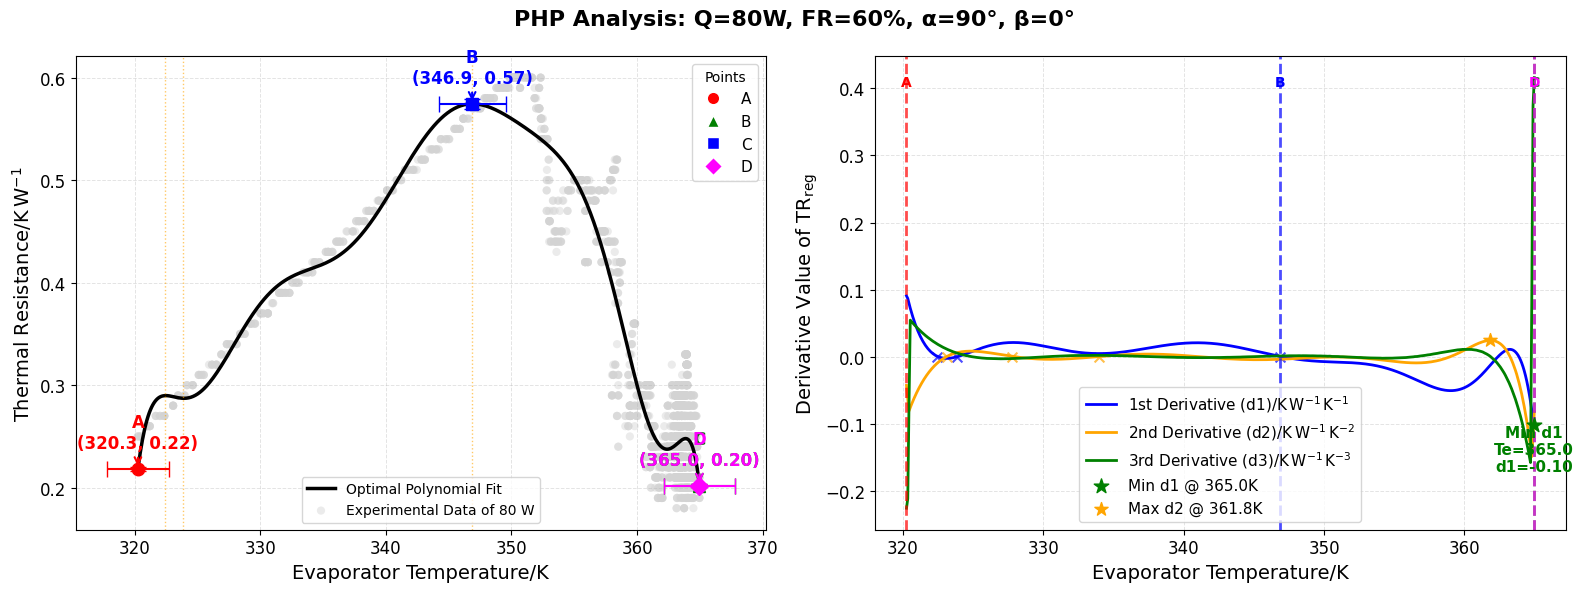

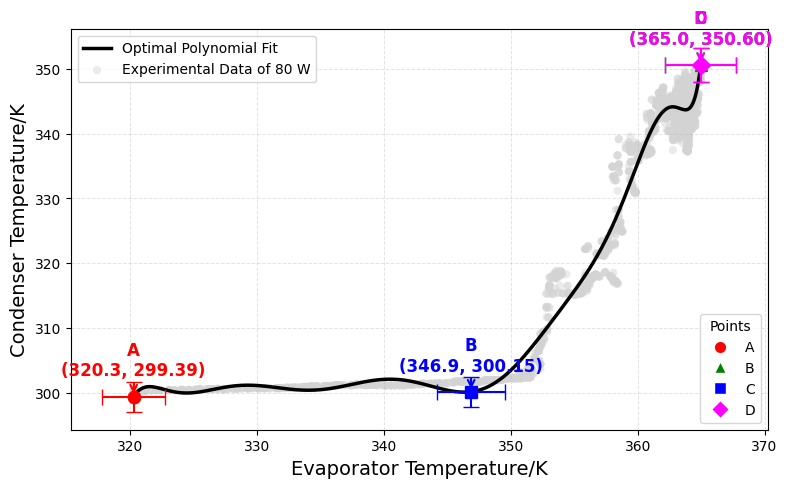

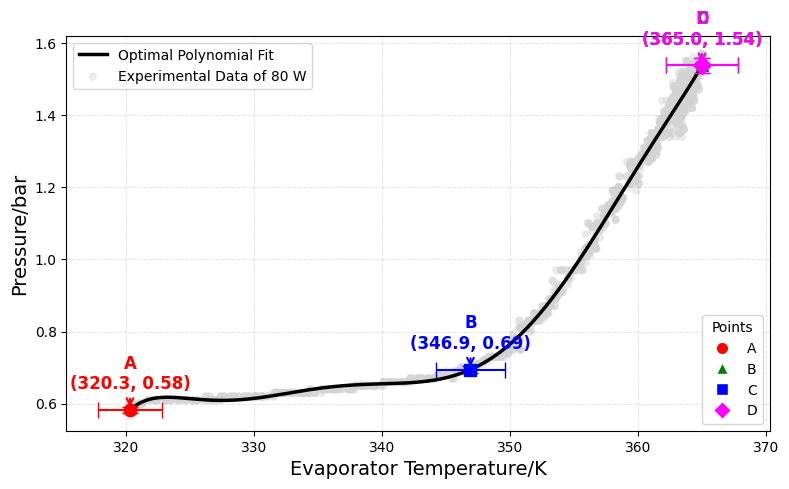

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import warnings
from matplotlib.lines import Line2D
warnings.filterwarnings('ignore')

# User-provided uncertainties (fractional)
UNC_Te = 0.0077   # ±0.77% Temperature
UNC_P  = 0.0136   # ±1.36% Pressure
UNC_TR = 0.008    # ±0.80% Thermal Resistance

# Marker mapping: A circle, B triangle, C square, D delta (diamond)
MARKERS_MAP = {'A': 'o', 'B': '^', 'C': 's', 'D': 'D'}

def optimize_polynomial_degree(Te, Te_unc, Y, max_degree=50, min_degree=3, cv_folds=5):
    degrees = range(min_degree, min(max_degree + 1, len(Te) // 3))
    rmse_scores, aic_scores, bic_scores, r2_scores = [], [], [], []
    Te_reshaped = Te.reshape(-1, 1)
    for degree in degrees:
        try:
            poly_pipeline = Pipeline([
                ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
                ('linear', LinearRegression())
            ])
            cv_scores = cross_val_score(poly_pipeline, Te_reshaped, Y, cv=min(cv_folds, len(Te)//2), scoring='neg_root_mean_squared_error')
            rmse_cv = -cv_scores.mean()
            rmse_scores.append(rmse_cv)
            poly_pipeline.fit(Te_reshaped, Y)
            Y_pred = poly_pipeline.predict(Te_reshaped)

            # Signal to Noice Ratio (SNR) calculation
            # TR_d1 = np.gradient(Y_pred, Te)
            # Te_uncnt = Te_unc * Te_reshaped
            # SNR = np.sum(TR_d1*Te_uncnt)
            # print(f"SNR: {SNR}")  

            mse = mean_squared_error(Y, Y_pred)
            n = len(Y)
            k = degree + 1
            ss_res = np.sum((Y - Y_pred) ** 2)
            ss_tot = np.sum((Y - np.mean(Y)) ** 2)
            r2 = 1 - (ss_res / ss_tot)
            r2_scores.append(r2)
            aic = n * np.log(mse) + 2 * k
            bic = n * np.log(mse) + k * np.log(n)
            aic_scores.append(aic)
            bic_scores.append(bic)
        except Exception:
            rmse_scores.append(float('inf'))
            aic_scores.append(float('inf'))
            bic_scores.append(float('inf'))
            r2_scores.append(-float('inf'))
    degrees = np.array(degrees)
    rmse_scores = np.array(rmse_scores)
    aic_scores = np.array(aic_scores)
    bic_scores = np.array(bic_scores)
    r2_scores = np.array(r2_scores)
    valid_idx = np.isfinite(rmse_scores)
    if not np.any(valid_idx):
        return {'optimal_degree': 5, 'method': 'default', 'rmse': float('inf')}
    best_rmse_idx = np.argmin(rmse_scores[valid_idx])
    best_aic_idx = np.argmin(aic_scores[valid_idx])
    best_bic_idx = np.argmin(bic_scores[valid_idx])
    best_rmse_degree = degrees[valid_idx][best_rmse_idx]
    best_aic_degree = degrees[valid_idx][best_aic_idx]
    best_bic_degree = degrees[valid_idx][best_bic_idx]
    rmse_norm = (rmse_scores - np.min(rmse_scores[valid_idx])) / (np.max(rmse_scores[valid_idx]) - np.min(rmse_scores[valid_idx]) + 1e-10)
    aic_norm = (aic_scores - np.min(aic_scores[valid_idx])) / (np.max(aic_scores[valid_idx]) - np.min(aic_scores[valid_idx]) + 1e-10)
    composite_scores = 0.6 * rmse_norm + 0.4 * aic_norm
    best_composite_idx = np.argmin(composite_scores[valid_idx])
    best_composite_degree = degrees[valid_idx][best_composite_idx]
    optimal_degree = best_composite_degree
    optimal_rmse = rmse_scores[valid_idx][best_composite_idx]
    optimal_r2 = r2_scores[valid_idx][best_composite_idx]
    return {
        'optimal_degree': int(optimal_degree),
        'method': 'composite_score',
        'rmse': optimal_rmse,
        'r2': optimal_r2,
        'degrees_tested': degrees[valid_idx].tolist(),
        'rmse_scores': rmse_scores[valid_idx].tolist(),
        'aic_scores': aic_scores[valid_idx].tolist(),
        'bic_scores': bic_scores[valid_idx].tolist(),
        'best_rmse_degree': int(best_rmse_degree),
        'best_aic_degree': int(best_aic_degree),
        'best_bic_degree': int(best_bic_degree)
    }

def _find_zero_crossings(arr):
    zero_crossings = []
    for i in range(len(arr) - 1):
        if arr[i] * arr[i + 1] < 0:
            zero_crossings.append(i)
    return np.array(zero_crossings)


def _identify_critical_points(Te_fine, Y_fit, d1, d2, d3):

    n = len(Te_fine)
    if n == 0:
        return {'A': None, 'C': None, 'B': None, 'D': None}

    # --------------------------------------------------
    # Point A: Always first (minimum Te)
    # --------------------------------------------------
    point_A_idx = 0

    # --------------------------------------------------
    # Point C: d1 = 0 and maximum Y_fit
    # --------------------------------------------------
    zero_crossings_d1 = _find_zero_crossings(d1)
    if len(zero_crossings_d1) > 0:
        point_C_idx = zero_crossings_d1[np.argmax(Y_fit[zero_crossings_d1])]
    else:
        point_C_idx = np.argmax(Y_fit)

    # Ensure C is after A
    point_C_idx = max(point_C_idx, point_A_idx + 1)

    # --------------------------------------------------
    # Point B: Minimum d1 with d2 ≈ 0 (after C)
    # --------------------------------------------------
    search_start_B = point_C_idx + 1

    if search_start_B < n:
        d1_min_idx = np.argmin(d1[search_start_B:]) + search_start_B
        d2_near_zero = np.argmin(np.abs(d2[search_start_B:])) + search_start_B

        if abs(d2[d1_min_idx]) < 0.1:
            point_B_idx = d1_min_idx
        else:
            point_B_idx = d2_near_zero
    else:
        point_B_idx = point_C_idx + 1 if point_C_idx + 1 < n else n - 1

    # --------------------------------------------------
    # Point D: Maximum d2 with d3 ≈ 0 (after B)
    # Additional condition: Te(D) > Te(B)
    # --------------------------------------------------
    search_start_D = point_B_idx + 1

    if search_start_D < n:
        d2_max_idx = np.argmax(d2[search_start_D:]) + search_start_D
        d3_near_zero = np.argmin(np.abs(d3[search_start_D:])) + search_start_D

        if abs(d3[d2_max_idx]) < 0.1:
            candidate_D = d2_max_idx
        else:
            candidate_D = d3_near_zero
    else:
        candidate_D = n - 1

    # --------------------------------------------------
    # Final ordering enforcement:
    # A < C < B < D  (Te-based ordering)
    # --------------------------------------------------
    if candidate_D <= point_B_idx:
        point_D_idx = n - 1   # force D to the last temperature
    else:
        point_D_idx = candidate_D

    return {
        'A': point_A_idx,
        'C': point_C_idx,
        'B': point_B_idx,
        'D': point_D_idx
    }



# 1. Function to analyis and plot, TR vs Te

def analyze_TR_vs_Te(csv_path, Q, FR, alpha, beta, te_min, te_max, poly_deg='auto', outlier_threshold=2.5, max_poly_deg=15, min_poly_deg=2):
    df = pd.read_csv(csv_path)
    df_sel = df[(df['Q[W]'] == Q) & (df['FR[%]'] == FR) & (df['alpha'] == alpha) & (df['beta'] == beta)]
    df_filtered = df_sel[(df_sel['Te_mean[K]'] >= te_min) & (df_sel['Te_mean[K]'] <= te_max)].copy()
    if df_filtered.empty or 'TR[K/W]' not in df_filtered.columns:
        print("No data found for given condition/range or missing TR[K/W] column.")
        return None
    df_tr_clean = df_filtered[np.abs(zscore(df_filtered['TR[K/W]'])) < outlier_threshold]
    Te = df_tr_clean.sort_values('Te_mean[K]')['Te_mean[K]'].values
    TR = df_tr_clean.sort_values('Te_mean[K]')['TR[K/W]'].values
    if len(Te) <= min_poly_deg:
        print("Insufficient TR data points for analysis.")
        return None
    if poly_deg == 'auto':
        opt_result = optimize_polynomial_degree(Te, TR, max_poly_deg, min_poly_deg)
        poly_deg = opt_result['optimal_degree']
    coeffs = np.polyfit(Te, TR, deg=poly_deg)
    poly = np.poly1d(coeffs)
    Te_fine = np.linspace(Te.min(), Te.max(), 500)
    TR_fit = poly(Te_fine)
    d1 = np.gradient(TR_fit, Te_fine)
    d2 = np.gradient(d1, Te_fine)
    d3 = np.gradient(d2, Te_fine)

    # Signal to Noice Ratio (SNR) calculation for TR fit
    SNR = np.abs(np.mean(d1 * (0.0077 * Te_fine)))
    SNR_db = 20 * np.log10(TR_fit.mean() / SNR)
    print(f"SNR of TR fit: {SNR}")
    print(f"SNR (dB): {SNR_db} dB")

    points = _identify_critical_points(Te_fine, TR_fit, d1, d2, d3)
    return {
        'Te_original': Te,
        'Y_original': TR,
        'Te_fine': Te_fine,
        'Y_fit': TR_fit,
        'd1': d1,
        'd2': d2,
        'd3': d3,
        'SNR': SNR,
        'SNR_db': SNR_db,
        'points': points,
        'poly_coeffs': coeffs,
        'poly_degree': poly_deg,
        'y_label': 'TR',
        'y_unit': 'K/W',
        'rmse': np.sqrt(mean_squared_error(TR, poly(Te))),
        'r2': 1 - np.sum((TR - poly(Te)) ** 2) / np.sum((TR - np.mean(TR)) ** 2)
    }


# 2. Function to analyis and plot, Tc vs Te

def analyze_heat_pipe_data_Tc(csv_path, Q, FR, alpha, beta, te_min, te_max, 
                          poly_deg='auto', outlier_threshold=2.5, 
                          max_poly_deg=50, min_poly_deg=3, tr_points=None, tr_Te_fine=None):
    df = pd.read_csv(csv_path)
    df_sel = df[(df['Q[W]'] == Q) & (df['FR[%]'] == FR) & 
                (df['alpha'] == alpha) & (df['beta'] == beta)]
    df_filtered = df_sel[(df_sel['Te_mean[K]'] >= te_min) & 
                        (df_sel['Te_mean[K]'] <= te_max)].copy()
    if df_filtered.empty:
        print("No data found for given condition and range.")
        return None
    df_tc_clean = df_filtered[np.abs(zscore(df_filtered['Tc_mean[K]'])) < outlier_threshold] if 'Tc_mean[K]' in df_filtered.columns else pd.DataFrame()
    df_p_clean = df_filtered[np.abs(zscore(df_filtered['P[bar]'])) < outlier_threshold] if 'P[bar]' in df_filtered.columns else pd.DataFrame()
    results = {}
    
    # Tc vs Te
    if len(df_tc_clean) > min_poly_deg:
        Te_tc = df_tc_clean.sort_values('Te_mean[K]')['Te_mean[K]'].values
        Tc_tc = df_tc_clean.sort_values('Te_mean[K]')['Tc_mean[K]'].values
        if poly_deg == 'auto':
            tc_opt_result = optimize_polynomial_degree(Te_tc, Tc_tc, max_poly_deg, min_poly_deg)
            tc_poly_deg = tc_opt_result['optimal_degree']
        else:
            tc_poly_deg = poly_deg
        results['tc'] = _polyfit_and_plot_with_points(Te_tc, Tc_tc, tc_poly_deg, 'Tc_mean [K]', 'Tc vs Te', Q, tr_points, tr_Te_fine)
    else:
        print("Insufficient Tc data points for analysis")
    
# 3. Function to analyis and plot, P vs Te

def analyze_heat_pipe_data_P(csv_path, Q, FR, alpha, beta, te_min, te_max, 
                          poly_deg='auto', outlier_threshold=2.5, 
                          max_poly_deg=50, min_poly_deg=3, tr_points=None, tr_Te_fine=None):
    df = pd.read_csv(csv_path)
    df_sel = df[(df['Q[W]'] == Q) & (df['FR[%]'] == FR) & 
                (df['alpha'] == alpha) & (df['beta'] == beta)]
    df_filtered = df_sel[(df_sel['Te_mean[K]'] >= te_min) & 
                        (df_sel['Te_mean[K]'] <= te_max)].copy()
    if df_filtered.empty:
        print("No data found for given condition and range.")
        return None
    df_tc_clean = df_filtered[np.abs(zscore(df_filtered['Tc_mean[K]'])) < outlier_threshold] if 'Tc_mean[K]' in df_filtered.columns else pd.DataFrame()
    df_p_clean = df_filtered[np.abs(zscore(df_filtered['P[bar]'])) < outlier_threshold] if 'P[bar]' in df_filtered.columns else pd.DataFrame()
    results = {}
    
      
    # P vs Te
    if len(df_p_clean) > min_poly_deg:
        Te_p = df_p_clean.sort_values('Te_mean[K]')['Te_mean[K]'].values
        P_p = df_p_clean.sort_values('Te_mean[K]')['P[bar]'].values
        if poly_deg == 'auto':
            p_opt_result = optimize_polynomial_degree(Te_p, P_p, max_poly_deg, min_poly_deg)
            p_poly_deg = p_opt_result['optimal_degree']
        else:
            p_poly_deg = poly_deg
        results['p'] = _polyfit_and_plot_with_points(Te_p, P_p, p_poly_deg, 'P [bar]', 'P vs Te', Q, tr_points, tr_Te_fine)
    else:
        print("Insufficient P data points for analysis")
    return results

def _polyfit_and_plot_with_points(Te, Y, poly_deg, y_label, title, Q, tr_points, tr_Te_fine):
    coeffs = np.polyfit(Te, Y, deg=poly_deg)
    poly = np.poly1d(coeffs)
    Te_fine = np.linspace(Te.min(), Te.max(), 500)
    Y_fit = poly(Te_fine)
    Y_pred = poly(Te)
    rmse = np.sqrt(mean_squared_error(Y, Y_pred))
    plt.figure(figsize=(8, 5))
    plt.plot(Te_fine, Y_fit, '-', color='black', linewidth=2.5, label=f'Optimal Polynomial Fit')
    plt.scatter(Te, Y, color='lightgray', alpha=0.45, s=35, edgecolor='none', label=f'Experimental Data of {Q} W')
    plt.xlabel('Evaporator Temperature/K', fontsize=14)
    if y_label == 'Tc_mean [K]':
        plt.ylabel('Condenser Temperature/K', fontsize=14)
    elif y_label == 'P [bar]':
        plt.ylabel('Pressure/bar', fontsize=14)
    else:
        plt.ylabel(y_label, fontsize=14)
    #plt.title(title, fontsize=14)
    # Add points A, B, C, D from TR analysis, but swap display names of B and C
    if tr_points is not None and tr_Te_fine is not None:
        colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
        markers = MARKERS_MAP
        # plot points but suppress legend entries for these (use custom marker-only legend)
        for label, idx in tr_points.items():
            # Swap display names for B and C
            if label == 'B':
                plot_label = 'C'
            elif label == 'C':
                plot_label = 'B'
            else:
                plot_label = label
            if idx is not None and 0 <= idx < len(tr_Te_fine):
                xval = tr_Te_fine[idx]
                # only plot if xval lies within this Te_fine range (interpolate)
                if Te_fine[0] <= xval <= Te_fine[-1]:
                    yval = np.interp(xval, Te_fine, Y_fit)
                    # choose y-uncertainty based on plotted variable
                    if y_label == 'P [bar]':
                        yerr = UNC_P * yval
                    elif y_label == 'Tc_mean [K]':
                        yerr = UNC_Te * yval
                    else:
                        yerr = UNC_TR * yval
                    # suppress automatic legend entry for errorbar
                    plt.errorbar(xval, yval,
                                 xerr=UNC_Te * xval,
                                 yerr=yerr,
                                 fmt=markers[label],
                                 color=colors[label],
                                 ecolor=colors[label],
                                 elinewidth=1.5,
                                 capsize=6,
                                 markersize=9,
                                 zorder=5,
                                 label='_nolegend_')
                    plt.annotate(f'{plot_label}\n({xval:.1f}, {yval:.2f})',
                                 (xval, yval),
                                 textcoords="offset points", xytext=(0,15), ha='center',
                                 fontsize=12, color=colors[label], fontweight='bold',
                                 arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
        # keep main legend (fit + data), then add points legend (marker-only, no rectangle)
        main_legend = plt.legend(fontsize=10, loc='best')
        plt.gca().add_artist(main_legend)
        custom_handles = [
            Line2D([0], [0], marker=MARKERS_MAP['A'], color='w', markerfacecolor='red', markersize=9, linestyle=''),
            Line2D([0], [0], marker=MARKERS_MAP['B'], color='w', markerfacecolor='green', markersize=9, linestyle=''),
            Line2D([0], [0], marker=MARKERS_MAP['C'], color='w', markerfacecolor='blue', markersize=9, linestyle=''),
            Line2D([0], [0], marker=MARKERS_MAP['D'], color='w', markerfacecolor='magenta', markersize=9, linestyle='')
        ]
        plt.legend(handles=custom_handles, labels=['A','B','C','D'], fontsize=10, loc='lower right', title='Points')
    else:
        plt.legend(fontsize=10, loc='best')

    # plt.grid(True, alpha=0.7)
    plt.grid(
        True,
        which='both',
        linestyle='--',
        linewidth=0.7,
        alpha=0.35
    )


    plt.tight_layout()
    plt.show()
    return {
        'Te': Te,
        'Y': Y,
        'Te_fine': Te_fine,
        'Y_fit': Y_fit,
        'poly_coeffs': coeffs,
        'poly_degree': poly_deg,
        'rmse': rmse
    }

# --- Example usage ---

csv_path = 'database_alpha.csv'
Q, FR, alpha, beta = 80, 60, 90, 0
te_min, te_max = 320, 365

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg=38,
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = MARKERS_MAP
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label='Optimal Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='lightgray', alpha=0.45, s=35, edgecolor='none', label=f'Experimental Data of {Q} W')
    # plot critical points but suppress their legend entries; we'll add a marker-only legend below
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        if idx is not None and 0 <= idx < len(data['Te_fine']):
            xval = data['Te_fine'][idx]
            yval = data['Y_fit'][idx]
            ax1.errorbar(xval, yval,
                         xerr=UNC_Te * xval,
                         yerr=UNC_TR * yval,
                         fmt=markers[label],
                         color=colors[label],
                         ecolor=colors[label],
                         elinewidth=1.5,
                         capsize=6,
                         markersize=9,
                         zorder=5,
                         label='_nolegend_')
            ax1.annotate(f'{plot_label}\n({xval:.1f}, {yval:.2f})', (xval, yval), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))

    # main legend (fit + data)
    main_handles, main_labels = ax1.get_legend_handles_labels()
    main_legend = ax1.legend(main_handles, main_labels, fontsize=10, loc='best')
    # custom legend for A/B/C/D marker-only (no rectangle)
    custom_handles = [
        Line2D([0], [0], marker=MARKERS_MAP['A'], color='w', label='A', markerfacecolor='red', markersize=9, linestyle=''),
        Line2D([0], [0], marker=MARKERS_MAP['B'], color='w', label='B', markerfacecolor='green', markersize=9, linestyle=''),
        Line2D([0], [0], marker=MARKERS_MAP['C'], color='w', label='C', markerfacecolor='blue', markersize=9, linestyle=''),
        Line2D([0], [0], marker=MARKERS_MAP['D'], color='w', label='D', markerfacecolor='magenta', markersize=9, linestyle='')
    ]
    
    ax1.add_artist(main_legend)
    ax1.legend(handles=custom_handles, labels=['A','B','C','D'], fontsize=11, loc='upper right', title='Points')

    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)

    ax1.set_xlabel('Evaporator Temperature/K', fontsize=14)
    ax1.set_ylabel('Thermal Resistance/$\\mathrm{K\\,W^{-1}}$', fontsize=14)
    ax1.tick_params(axis='both', labelsize=12)
    #ax1.legend(fontsize=11)
    # ax1.legend(shadow=True, frameon=True, fontsize=11)
    
    # ax1.grid(True, ls=':', lw=0.8, alpha=0.7)
    ax1.grid(
        True,
        which='both',
        linestyle='--',
        linewidth=0.7,
        alpha=0.35
    )

    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (d1)/$\\mathrm{K\\,W^{-1}\\,K^{-1}}$', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (d2)/$\\mathrm{K\\,W^{-1}\\,K^{-2}}$', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (d3)/$\\mathrm{K\\,W^{-1}\\,K^{-3}}$', linewidth=2, color='green')
    # mark vertical lines for points and annotate with swapped labels
    for label, idx in data['points'].items():
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        if idx is not None:
            ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
            ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')

    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature/K', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR$_{\mathrm{reg}}$', fontsize=14)
    ax2.tick_params(axis='both', labelsize=12)
    ax2.legend(fontsize=11)

    #ax2.grid(True, ls=':', lw=0.8, alpha=0.7)
    ax2.grid(
        True,
        which='both',
        linestyle='--',
        linewidth=0.7,
        alpha=0.35
    )

    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te , marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data_Tc(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg=55,
    outlier_threshold=2.5,
    max_poly_deg=50,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

# 3. Analyze and plot P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data_P(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg=8,
    outlier_threshold=2.5,
    max_poly_deg=50,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

## 40 W

### alpha = 0, beta = 0

SNR of TR fit: 0.06573204817517424
SNR (dB): 22.232799829720253 dB


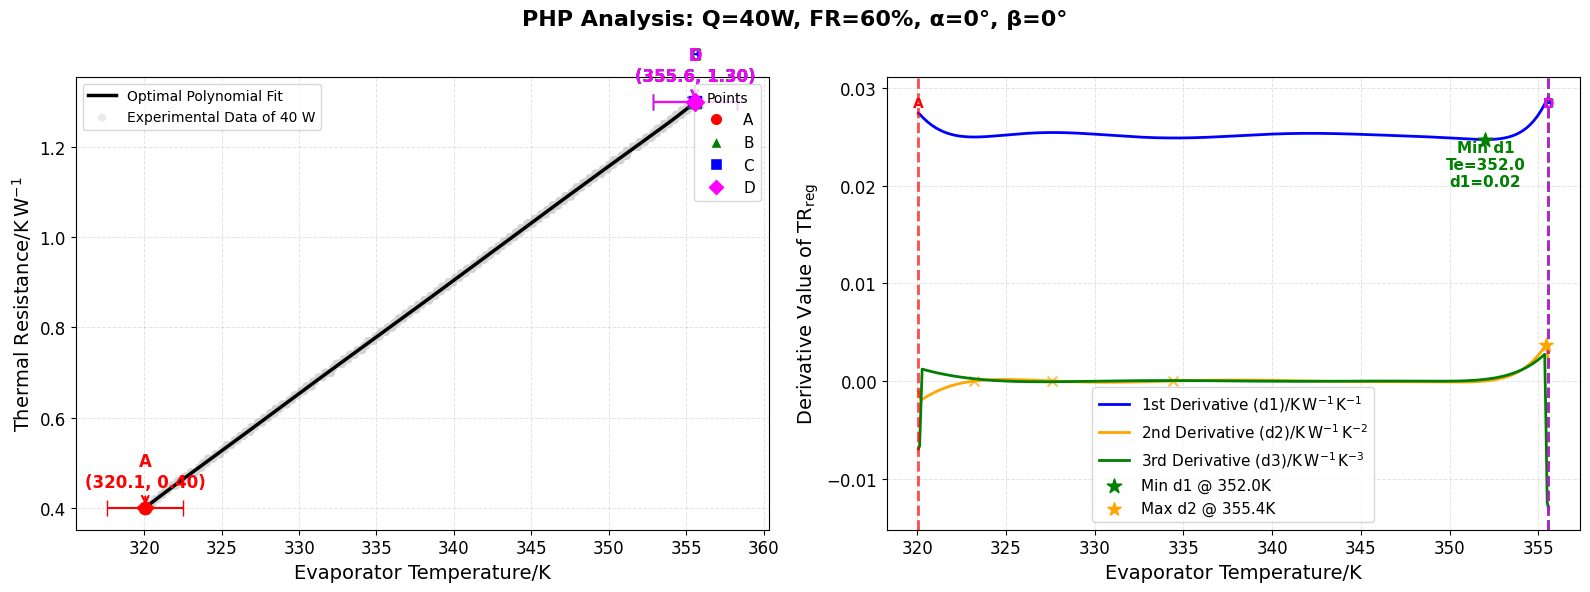

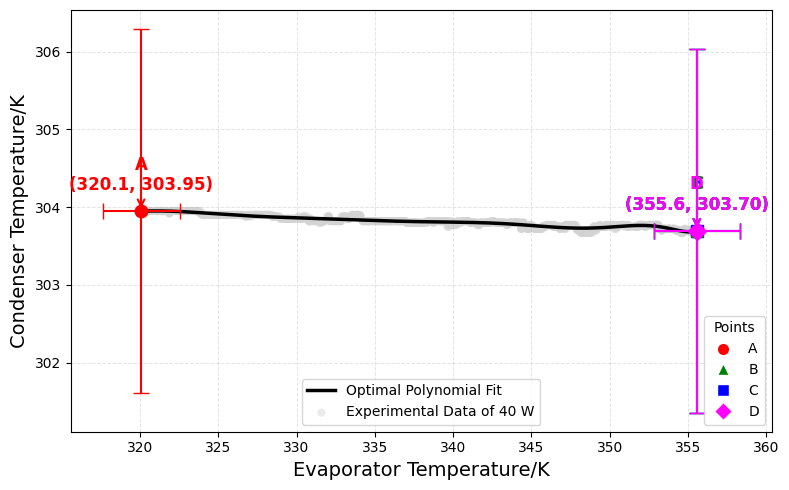

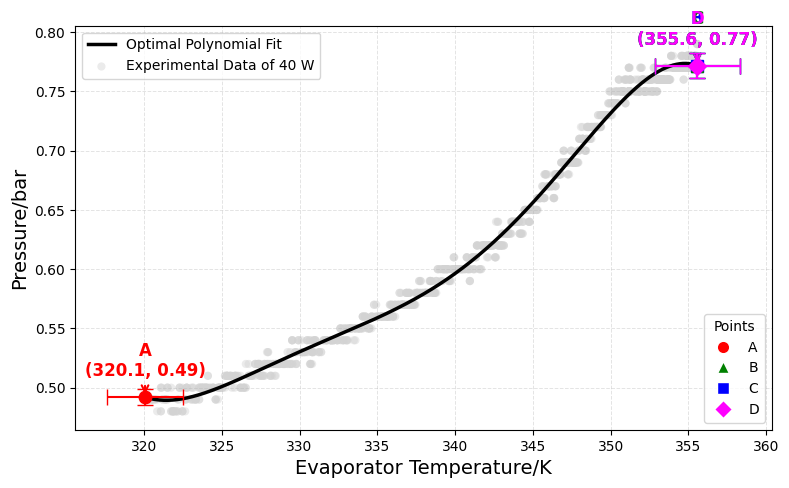

In [67]:
csv_path = 'database_alpha.csv'
Q, FR, alpha, beta = 40, 60, 0, 0
te_min, te_max = 320, 365

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg=38,
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = MARKERS_MAP
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label='Optimal Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='lightgray', alpha=0.45, s=35, edgecolor='none', label=f'Experimental Data of {Q} W')
    # plot critical points but suppress their legend entries; we'll add a marker-only legend below
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        if idx is not None and 0 <= idx < len(data['Te_fine']):
            xval = data['Te_fine'][idx]
            yval = data['Y_fit'][idx]
            ax1.errorbar(xval, yval,
                         xerr=UNC_Te * xval,
                         yerr=UNC_TR * yval,
                         fmt=markers[label],
                         color=colors[label],
                         ecolor=colors[label],
                         elinewidth=1.5,
                         capsize=6,
                         markersize=9,
                         zorder=5,
                         label='_nolegend_')
            ax1.annotate(f'{plot_label}\n({xval:.1f}, {yval:.2f})', (xval, yval), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))

    # main legend (fit + data)
    main_handles, main_labels = ax1.get_legend_handles_labels()
    main_legend = ax1.legend(main_handles, main_labels, fontsize=10, loc='best')
    # custom legend for A/B/C/D marker-only (no rectangle)
    custom_handles = [
        Line2D([0], [0], marker=MARKERS_MAP['A'], color='w', label='A', markerfacecolor='red', markersize=9, linestyle=''),
        Line2D([0], [0], marker=MARKERS_MAP['B'], color='w', label='B', markerfacecolor='green', markersize=9, linestyle=''),
        Line2D([0], [0], marker=MARKERS_MAP['C'], color='w', label='C', markerfacecolor='blue', markersize=9, linestyle=''),
        Line2D([0], [0], marker=MARKERS_MAP['D'], color='w', label='D', markerfacecolor='magenta', markersize=9, linestyle='')
    ]
    
    ax1.add_artist(main_legend)
    ax1.legend(handles=custom_handles, labels=['A','B','C','D'], fontsize=11, loc='upper right', title='Points')

    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)

    ax1.set_xlabel('Evaporator Temperature/K', fontsize=14)
    ax1.set_ylabel('Thermal Resistance/$\\mathrm{K\\,W^{-1}}$', fontsize=14)
    ax1.tick_params(axis='both', labelsize=12)
    #ax1.legend(fontsize=11)
    # ax1.legend(shadow=True, frameon=True, fontsize=11)
    
    # ax1.grid(True, ls=':', lw=0.8, alpha=0.7)
    ax1.grid(
        True,
        which='both',
        linestyle='--',
        linewidth=0.7,
        alpha=0.35
    )

    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (d1)/$\\mathrm{K\\,W^{-1}\\,K^{-1}}$', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (d2)/$\\mathrm{K\\,W^{-1}\\,K^{-2}}$', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (d3)/$\\mathrm{K\\,W^{-1}\\,K^{-3}}$', linewidth=2, color='green')
    # mark vertical lines for points and annotate with swapped labels
    for label, idx in data['points'].items():
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        if idx is not None:
            ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
            ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')

    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature/K', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR$_{\mathrm{reg}}$', fontsize=14)
    ax2.tick_params(axis='both', labelsize=12)
    ax2.legend(fontsize=11)

    #ax2.grid(True, ls=':', lw=0.8, alpha=0.7)
    ax2.grid(
        True,
        which='both',
        linestyle='--',
        linewidth=0.7,
        alpha=0.35
    )

    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te , marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data_Tc(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg=55,
    outlier_threshold=2.5,
    max_poly_deg=50,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

# 3. Analyze and plot P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data_P(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg=8,
    outlier_threshold=2.5,
    max_poly_deg=50,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

SNR of TR fit: 0.06554356280918983
SNR (dB): 22.257646720252637 dB


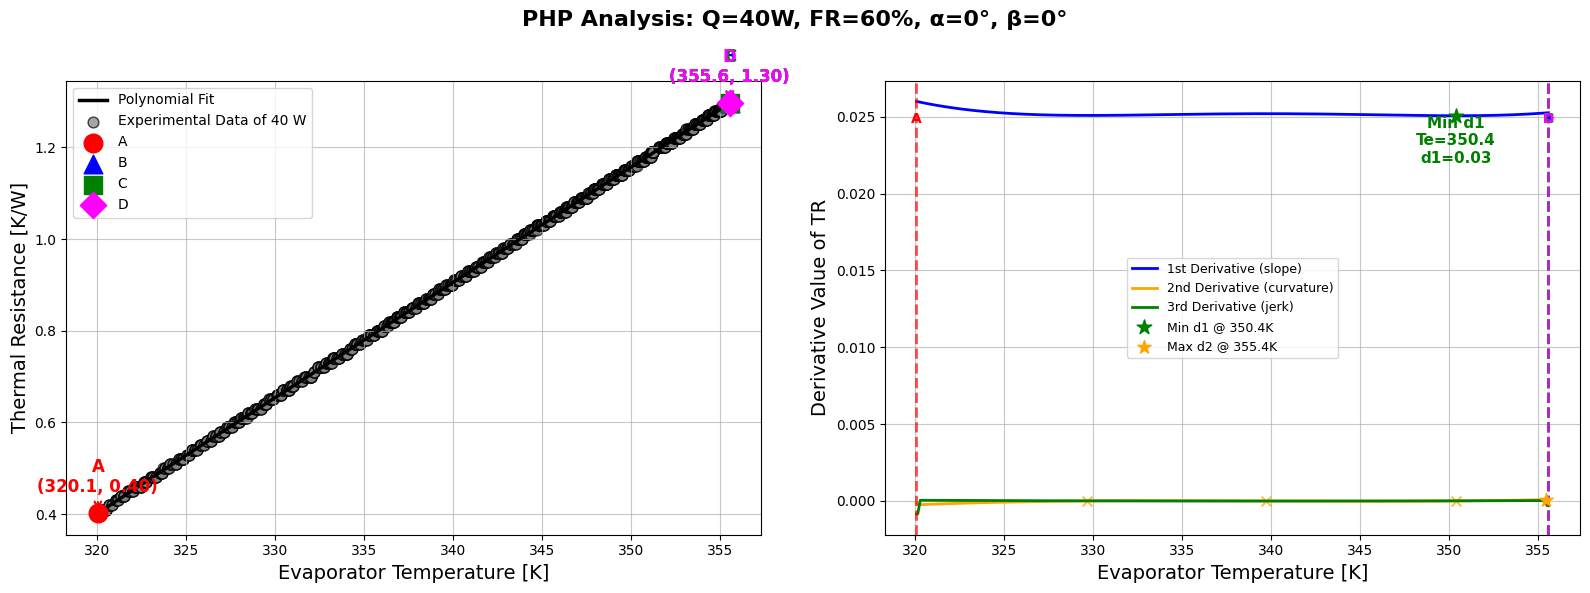

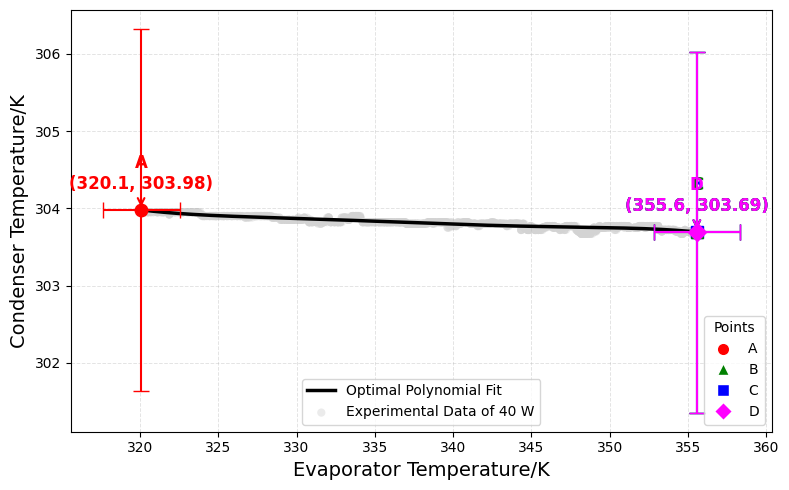

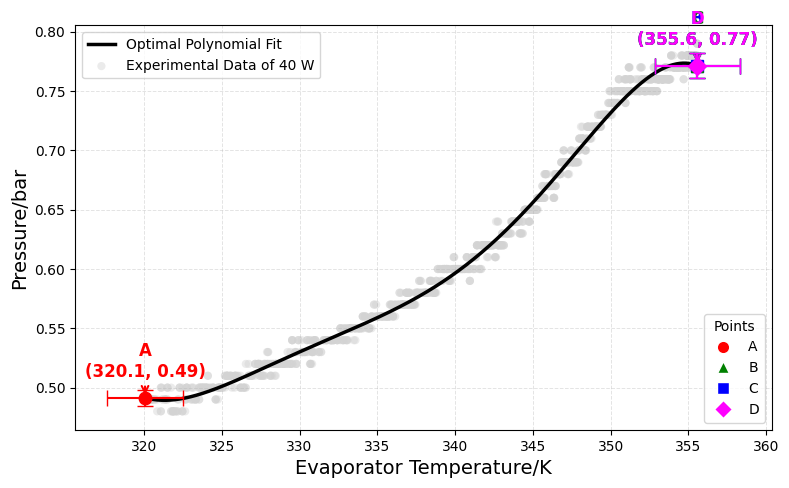

In [68]:
csv_path = 'database_alpha.csv'
Q, FR, alpha, beta = 40, 60, 0, 0
te_min, te_max = 320, 365

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label=f'Experimental Data of {Q} W')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{plot_label}')
        ax1.annotate(f'{plot_label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
    
    ax1.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax1.set_ylabel('Thermal Resistance [K/W]', fontsize=14)
    #ax1.set_title('TR vs Te with Critical Points', fontsize=14)
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.7)
    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
        ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')
    
    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR', fontsize=14)
    #ax2.set_title('Derivatives of TR vs Te', fontsize=14)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te and P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

### alpha = 30, beta = 0

SNR of TR fit: 0.06332209456677844
SNR (dB): 22.692979284047308 dB


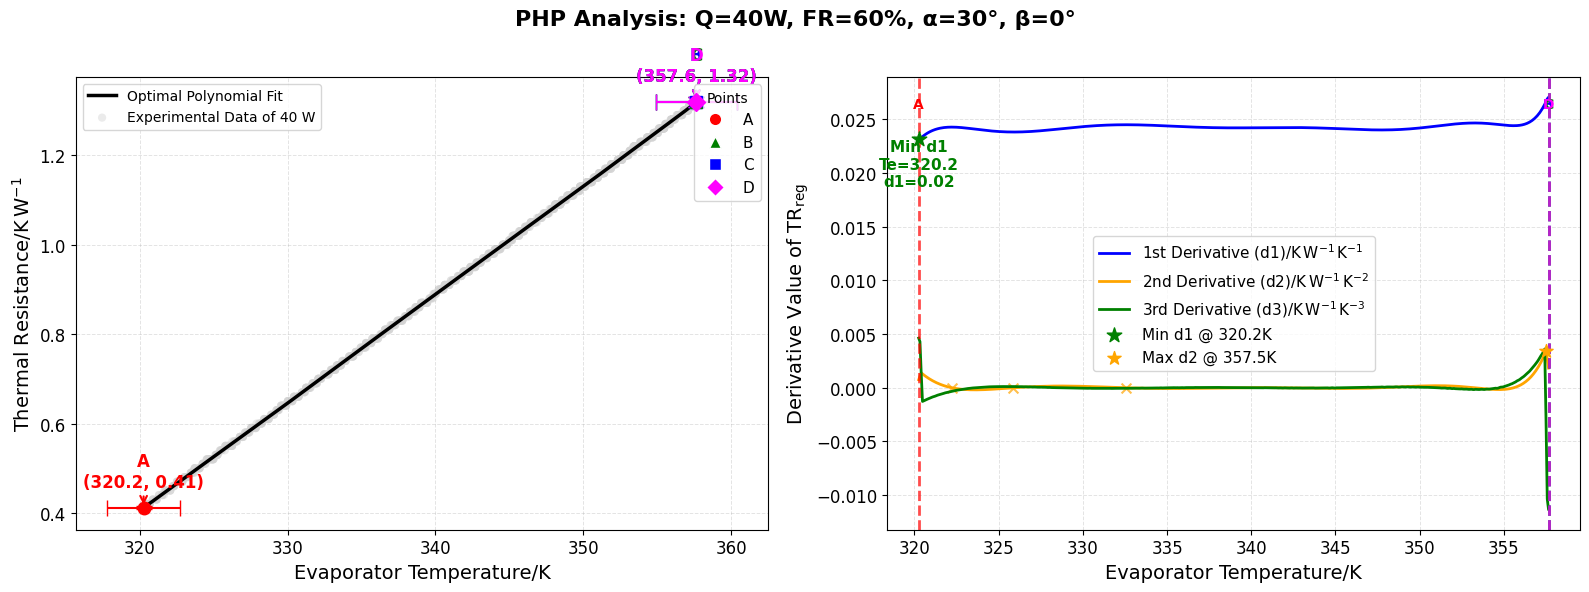

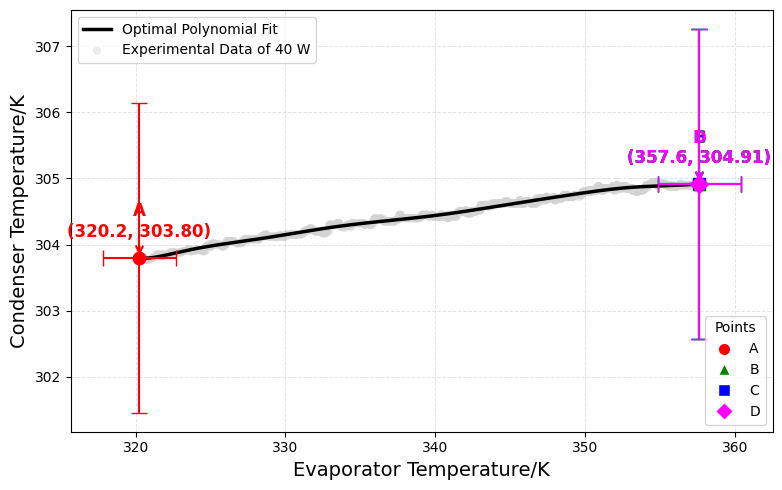

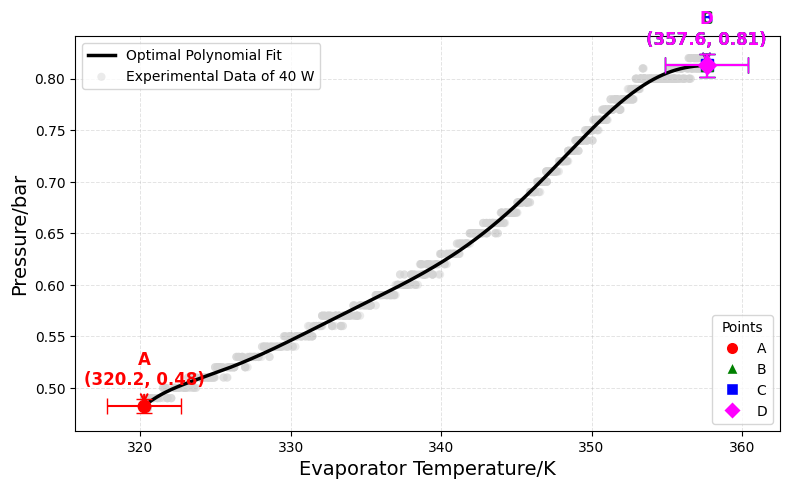

In [69]:
csv_path = 'database_alpha.csv'
Q, FR, alpha, beta = 40, 60, 30, 0
te_min, te_max = 320, 365

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg=38,
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = MARKERS_MAP
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label='Optimal Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='lightgray', alpha=0.45, s=35, edgecolor='none', label=f'Experimental Data of {Q} W')
    # plot critical points but suppress their legend entries; we'll add a marker-only legend below
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        if idx is not None and 0 <= idx < len(data['Te_fine']):
            xval = data['Te_fine'][idx]
            yval = data['Y_fit'][idx]
            ax1.errorbar(xval, yval,
                         xerr=UNC_Te * xval,
                         yerr=UNC_TR * yval,
                         fmt=markers[label],
                         color=colors[label],
                         ecolor=colors[label],
                         elinewidth=1.5,
                         capsize=6,
                         markersize=9,
                         zorder=5,
                         label='_nolegend_')
            ax1.annotate(f'{plot_label}\n({xval:.1f}, {yval:.2f})', (xval, yval), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))

    # main legend (fit + data)
    main_handles, main_labels = ax1.get_legend_handles_labels()
    main_legend = ax1.legend(main_handles, main_labels, fontsize=10, loc='best')
    # custom legend for A/B/C/D marker-only (no rectangle)
    custom_handles = [
        Line2D([0], [0], marker=MARKERS_MAP['A'], color='w', label='A', markerfacecolor='red', markersize=9, linestyle=''),
        Line2D([0], [0], marker=MARKERS_MAP['B'], color='w', label='B', markerfacecolor='green', markersize=9, linestyle=''),
        Line2D([0], [0], marker=MARKERS_MAP['C'], color='w', label='C', markerfacecolor='blue', markersize=9, linestyle=''),
        Line2D([0], [0], marker=MARKERS_MAP['D'], color='w', label='D', markerfacecolor='magenta', markersize=9, linestyle='')
    ]
    
    ax1.add_artist(main_legend)
    ax1.legend(handles=custom_handles, labels=['A','B','C','D'], fontsize=11, loc='upper right', title='Points')

    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)

    ax1.set_xlabel('Evaporator Temperature/K', fontsize=14)
    ax1.set_ylabel('Thermal Resistance/$\\mathrm{K\\,W^{-1}}$', fontsize=14)
    ax1.tick_params(axis='both', labelsize=12)
    #ax1.legend(fontsize=11)
    # ax1.legend(shadow=True, frameon=True, fontsize=11)
    
    # ax1.grid(True, ls=':', lw=0.8, alpha=0.7)
    ax1.grid(
        True,
        which='both',
        linestyle='--',
        linewidth=0.7,
        alpha=0.35
    )

    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (d1)/$\\mathrm{K\\,W^{-1}\\,K^{-1}}$', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (d2)/$\\mathrm{K\\,W^{-1}\\,K^{-2}}$', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (d3)/$\\mathrm{K\\,W^{-1}\\,K^{-3}}$', linewidth=2, color='green')
    # mark vertical lines for points and annotate with swapped labels
    for label, idx in data['points'].items():
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        if idx is not None:
            ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
            ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')

    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature/K', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR$_{\mathrm{reg}}$', fontsize=14)
    ax2.tick_params(axis='both', labelsize=12)
    ax2.legend(fontsize=11)

    #ax2.grid(True, ls=':', lw=0.8, alpha=0.7)
    ax2.grid(
        True,
        which='both',
        linestyle='--',
        linewidth=0.7,
        alpha=0.35
    )

    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te , marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data_Tc(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg=55,
    outlier_threshold=2.5,
    max_poly_deg=50,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

# 3. Analyze and plot P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data_P(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg=8,
    outlier_threshold=2.5,
    max_poly_deg=50,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

### alpha = 60, beta = 0

SNR of TR fit: 0.06469362676661367
SNR (dB): 22.320171151717165 dB


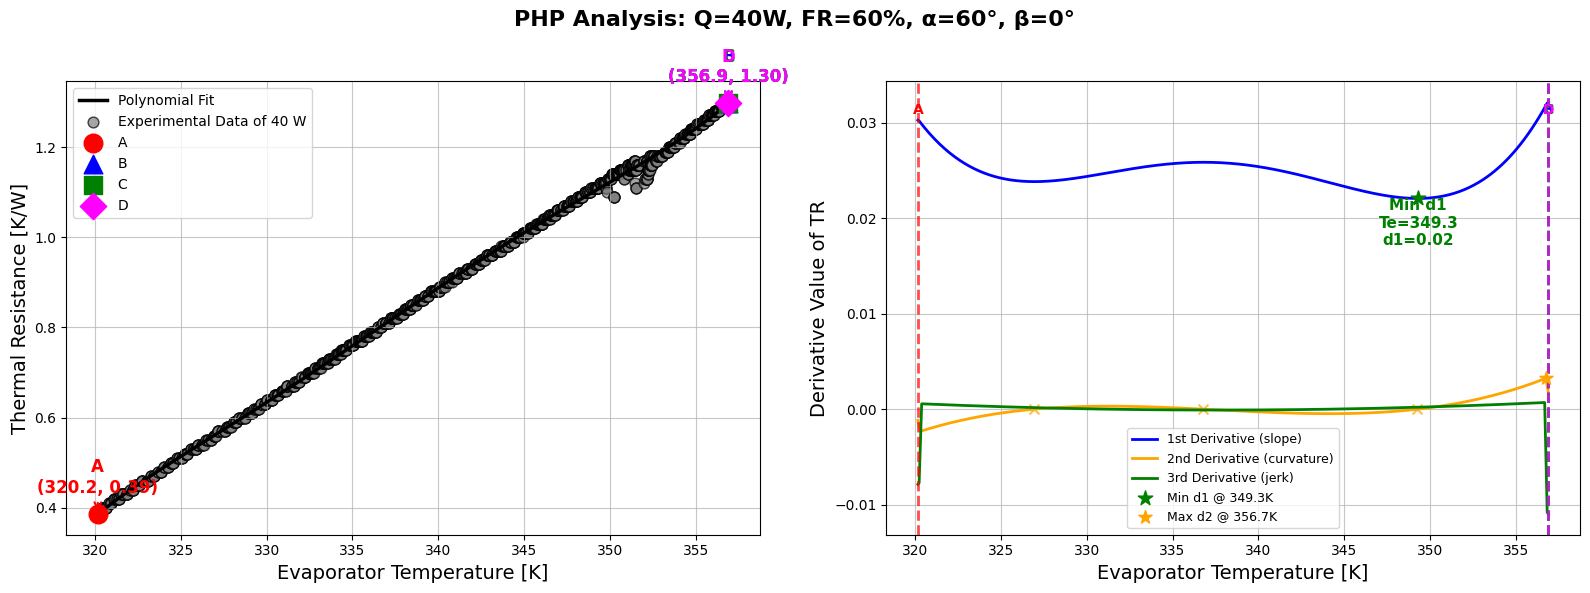

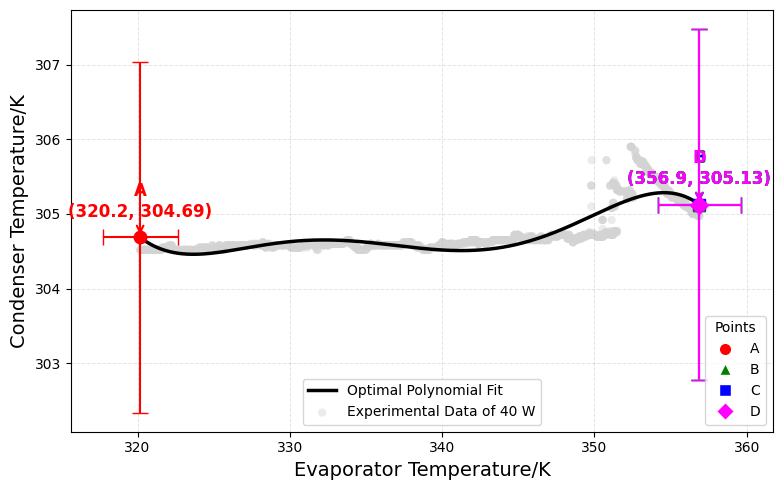

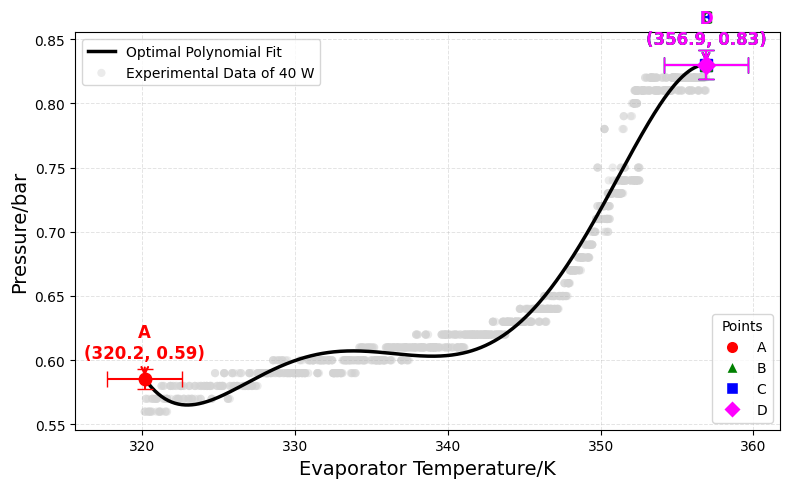

In [70]:
csv_path = 'database_alpha.csv'
Q, FR, alpha, beta = 40, 60, 60, 0
te_min, te_max = 320, 365

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label=f'Experimental Data of {Q} W')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{plot_label}')
        ax1.annotate(f'{plot_label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
    
    ax1.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax1.set_ylabel('Thermal Resistance [K/W]', fontsize=14)
    #ax1.set_title('TR vs Te with Critical Points', fontsize=14)
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.7)
    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
        ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')
    
    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR', fontsize=14)
    #ax2.set_title('Derivatives of TR vs Te', fontsize=14)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te and P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

SNR of TR fit: 0.0640553811445738
SNR (dB): 22.40504227631732 dB


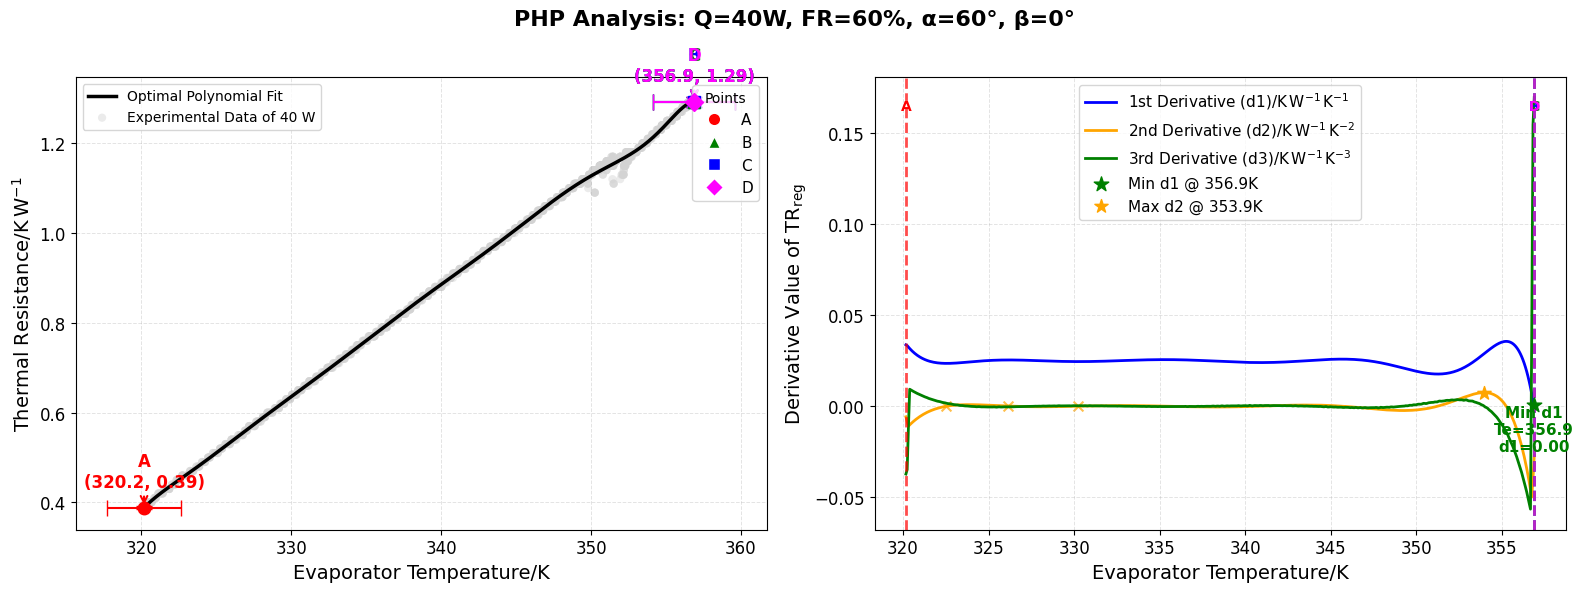

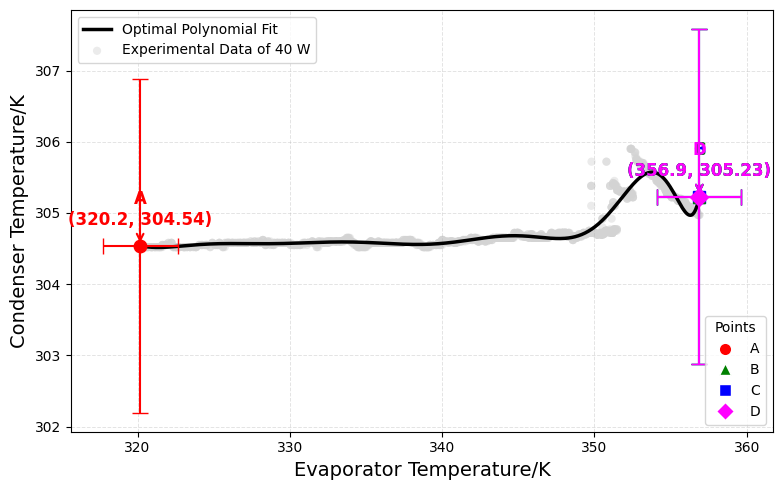

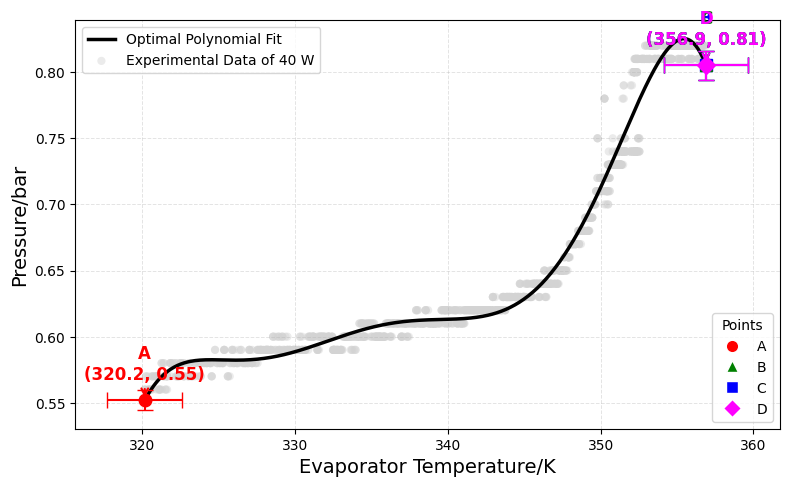

In [71]:
csv_path = 'database_alpha.csv'
Q, FR, alpha, beta = 40, 60, 60, 0
te_min, te_max = 320, 365

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg=38,
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = MARKERS_MAP
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label='Optimal Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='lightgray', alpha=0.45, s=35, edgecolor='none', label=f'Experimental Data of {Q} W')
    # plot critical points but suppress their legend entries; we'll add a marker-only legend below
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        if idx is not None and 0 <= idx < len(data['Te_fine']):
            xval = data['Te_fine'][idx]
            yval = data['Y_fit'][idx]
            ax1.errorbar(xval, yval,
                         xerr=UNC_Te * xval,
                         yerr=UNC_TR * yval,
                         fmt=markers[label],
                         color=colors[label],
                         ecolor=colors[label],
                         elinewidth=1.5,
                         capsize=6,
                         markersize=9,
                         zorder=5,
                         label='_nolegend_')
            ax1.annotate(f'{plot_label}\n({xval:.1f}, {yval:.2f})', (xval, yval), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))

    # main legend (fit + data)
    main_handles, main_labels = ax1.get_legend_handles_labels()
    main_legend = ax1.legend(main_handles, main_labels, fontsize=10, loc='best')
    # custom legend for A/B/C/D marker-only (no rectangle)
    custom_handles = [
        Line2D([0], [0], marker=MARKERS_MAP['A'], color='w', label='A', markerfacecolor='red', markersize=9, linestyle=''),
        Line2D([0], [0], marker=MARKERS_MAP['B'], color='w', label='B', markerfacecolor='green', markersize=9, linestyle=''),
        Line2D([0], [0], marker=MARKERS_MAP['C'], color='w', label='C', markerfacecolor='blue', markersize=9, linestyle=''),
        Line2D([0], [0], marker=MARKERS_MAP['D'], color='w', label='D', markerfacecolor='magenta', markersize=9, linestyle='')
    ]
    
    ax1.add_artist(main_legend)
    ax1.legend(handles=custom_handles, labels=['A','B','C','D'], fontsize=11, loc='upper right', title='Points')

    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)

    ax1.set_xlabel('Evaporator Temperature/K', fontsize=14)
    ax1.set_ylabel('Thermal Resistance/$\\mathrm{K\\,W^{-1}}$', fontsize=14)
    ax1.tick_params(axis='both', labelsize=12)
    #ax1.legend(fontsize=11)
    # ax1.legend(shadow=True, frameon=True, fontsize=11)
    
    # ax1.grid(True, ls=':', lw=0.8, alpha=0.7)
    ax1.grid(
        True,
        which='both',
        linestyle='--',
        linewidth=0.7,
        alpha=0.35
    )

    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (d1)/$\\mathrm{K\\,W^{-1}\\,K^{-1}}$', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (d2)/$\\mathrm{K\\,W^{-1}\\,K^{-2}}$', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (d3)/$\\mathrm{K\\,W^{-1}\\,K^{-3}}$', linewidth=2, color='green')
    # mark vertical lines for points and annotate with swapped labels
    for label, idx in data['points'].items():
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        if idx is not None:
            ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
            ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')

    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature/K', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR$_{\mathrm{reg}}$', fontsize=14)
    ax2.tick_params(axis='both', labelsize=12)
    ax2.legend(fontsize=11)

    #ax2.grid(True, ls=':', lw=0.8, alpha=0.7)
    ax2.grid(
        True,
        which='both',
        linestyle='--',
        linewidth=0.7,
        alpha=0.35
    )

    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te , marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data_Tc(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg=55,
    outlier_threshold=2.5,
    max_poly_deg=50,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

# 3. Analyze and plot P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data_P(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg=8,
    outlier_threshold=2.5,
    max_poly_deg=50,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

### alpha = 90, beta = 0

SNR of TR fit: 0.04899975172532583
SNR (dB): 23.826519957626523 dB


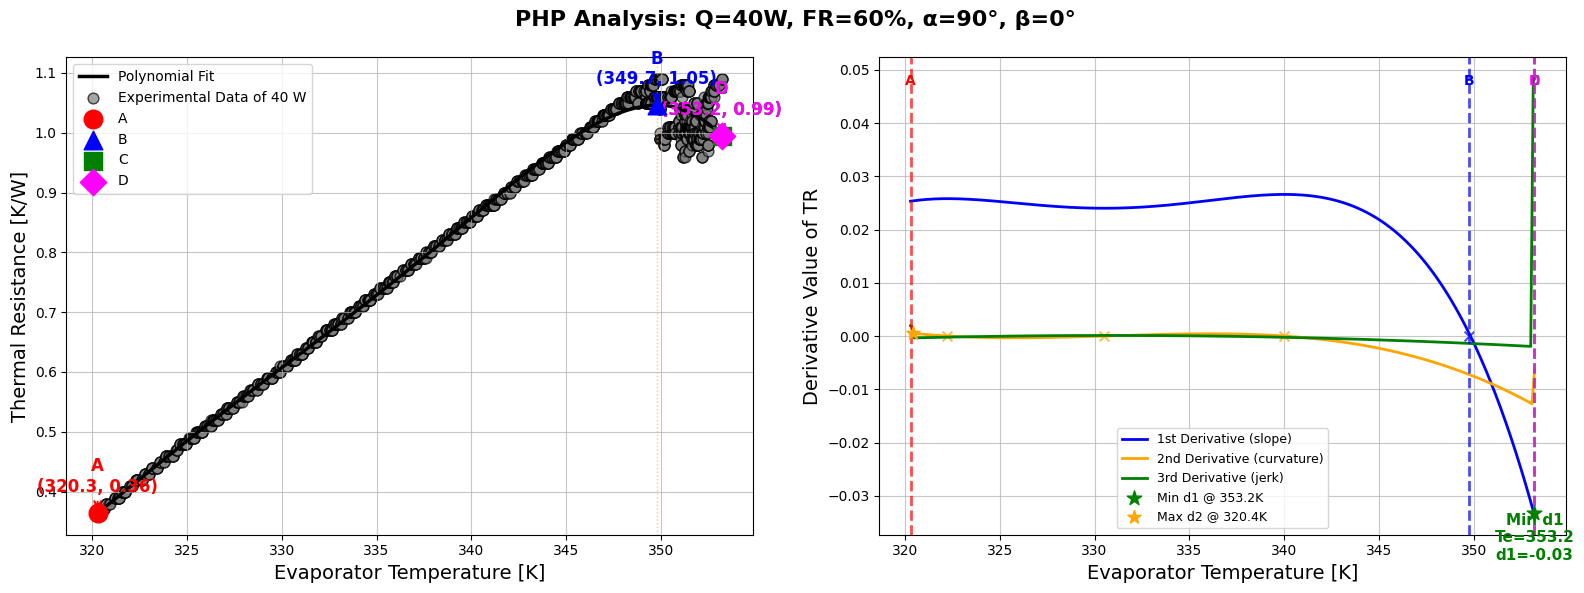

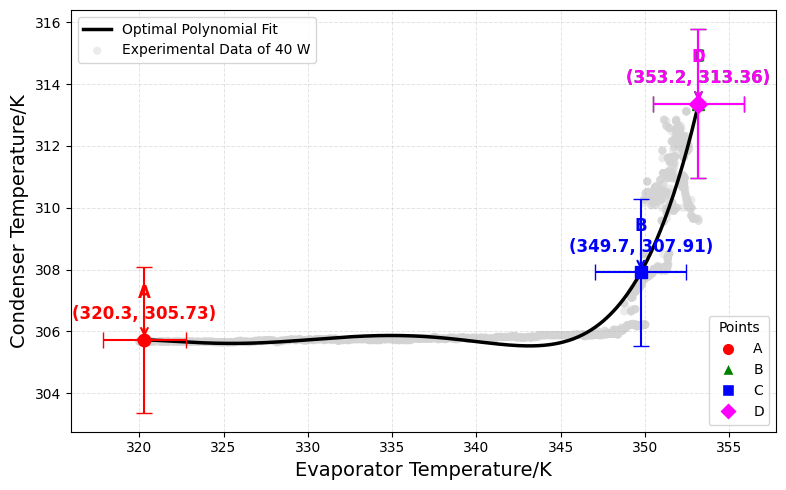

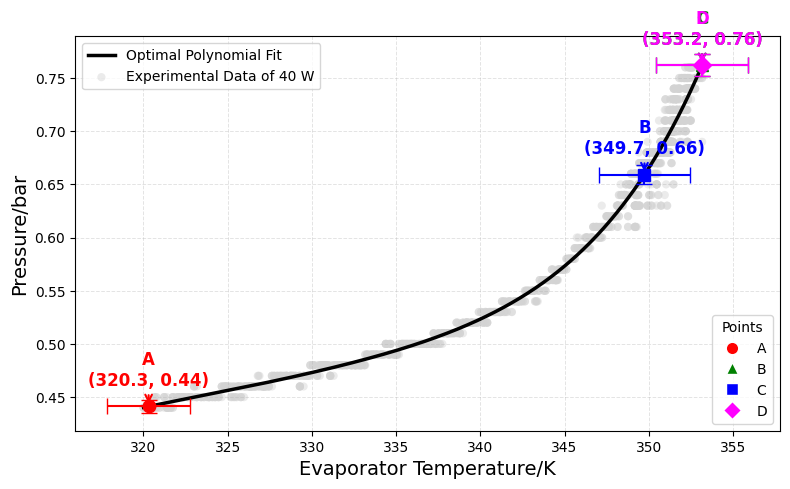

In [72]:
csv_path = 'database_alpha.csv'
Q, FR, alpha, beta = 40, 60, 90, 0
te_min, te_max = 320, 365

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label=f'Experimental Data of {Q} W')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{plot_label}')
        ax1.annotate(f'{plot_label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
    
    ax1.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax1.set_ylabel('Thermal Resistance [K/W]', fontsize=14)
    #ax1.set_title('TR vs Te with Critical Points', fontsize=14)
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.7)
    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
        ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')
    
    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR', fontsize=14)
    #ax2.set_title('Derivatives of TR vs Te', fontsize=14)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te and P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

SNR of TR fit: 0.0588848487829762
SNR (dB): 22.246245298481302 dB


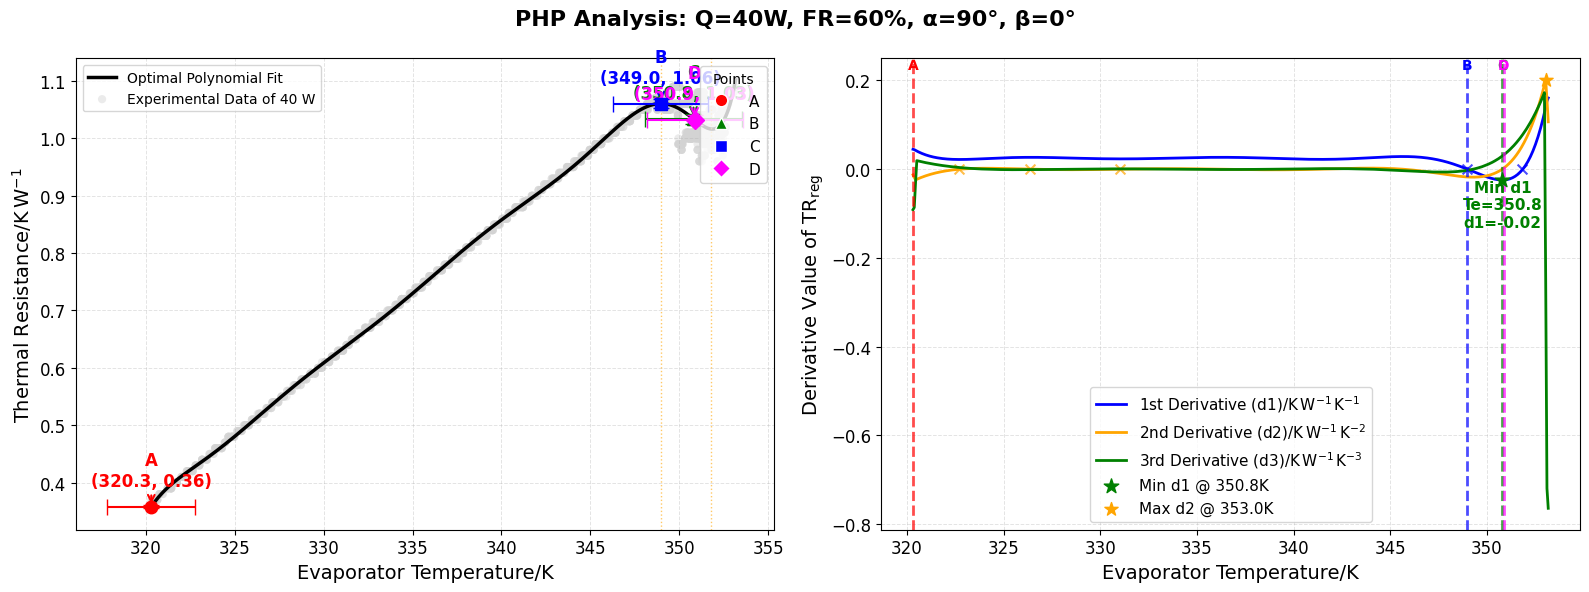

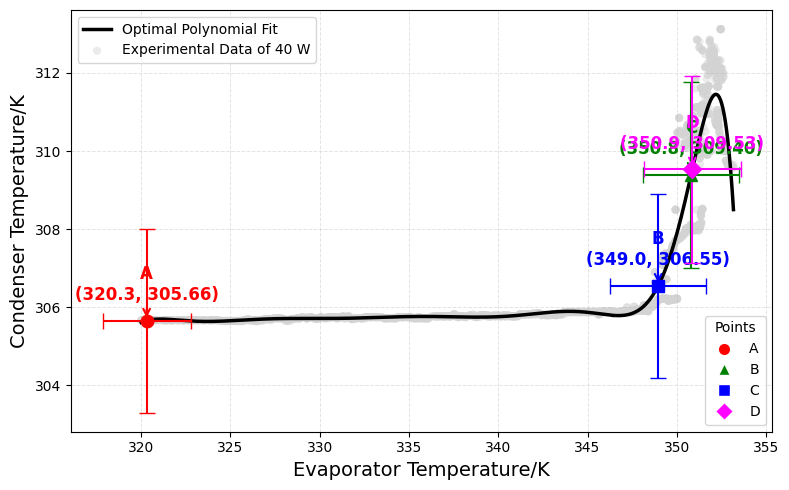

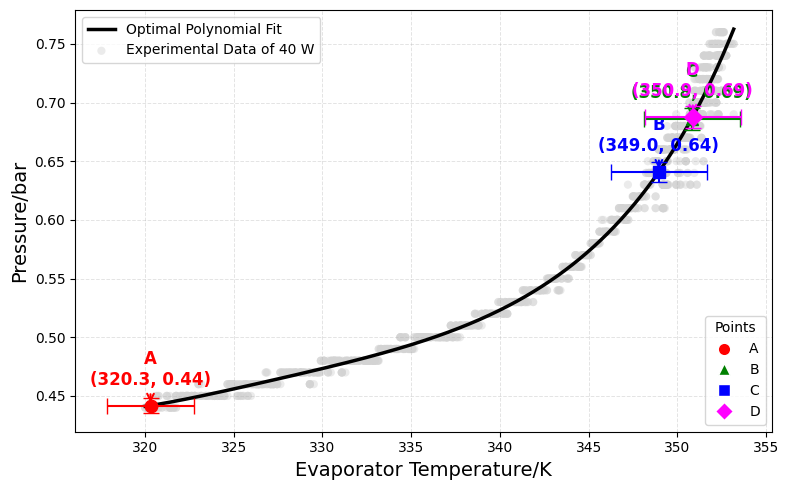

In [73]:
csv_path = 'database_alpha.csv'
Q, FR, alpha, beta = 40, 60, 90, 0
te_min, te_max = 320, 365

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg=38,
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = MARKERS_MAP
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label='Optimal Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='lightgray', alpha=0.45, s=35, edgecolor='none', label=f'Experimental Data of {Q} W')
    # plot critical points but suppress their legend entries; we'll add a marker-only legend below
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        if idx is not None and 0 <= idx < len(data['Te_fine']):
            xval = data['Te_fine'][idx]
            yval = data['Y_fit'][idx]
            ax1.errorbar(xval, yval,
                         xerr=UNC_Te * xval,
                         yerr=UNC_TR * yval,
                         fmt=markers[label],
                         color=colors[label],
                         ecolor=colors[label],
                         elinewidth=1.5,
                         capsize=6,
                         markersize=9,
                         zorder=5,
                         label='_nolegend_')
            ax1.annotate(f'{plot_label}\n({xval:.1f}, {yval:.2f})', (xval, yval), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))

    # main legend (fit + data)
    main_handles, main_labels = ax1.get_legend_handles_labels()
    main_legend = ax1.legend(main_handles, main_labels, fontsize=10, loc='best')
    # custom legend for A/B/C/D marker-only (no rectangle)
    custom_handles = [
        Line2D([0], [0], marker=MARKERS_MAP['A'], color='w', label='A', markerfacecolor='red', markersize=9, linestyle=''),
        Line2D([0], [0], marker=MARKERS_MAP['B'], color='w', label='B', markerfacecolor='green', markersize=9, linestyle=''),
        Line2D([0], [0], marker=MARKERS_MAP['C'], color='w', label='C', markerfacecolor='blue', markersize=9, linestyle=''),
        Line2D([0], [0], marker=MARKERS_MAP['D'], color='w', label='D', markerfacecolor='magenta', markersize=9, linestyle='')
    ]
    
    ax1.add_artist(main_legend)
    ax1.legend(handles=custom_handles, labels=['A','B','C','D'], fontsize=11, loc='upper right', title='Points')

    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)

    ax1.set_xlabel('Evaporator Temperature/K', fontsize=14)
    ax1.set_ylabel('Thermal Resistance/$\\mathrm{K\\,W^{-1}}$', fontsize=14)
    ax1.tick_params(axis='both', labelsize=12)
    #ax1.legend(fontsize=11)
    # ax1.legend(shadow=True, frameon=True, fontsize=11)
    
    # ax1.grid(True, ls=':', lw=0.8, alpha=0.7)
    ax1.grid(
        True,
        which='both',
        linestyle='--',
        linewidth=0.7,
        alpha=0.35
    )

    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (d1)/$\\mathrm{K\\,W^{-1}\\,K^{-1}}$', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (d2)/$\\mathrm{K\\,W^{-1}\\,K^{-2}}$', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (d3)/$\\mathrm{K\\,W^{-1}\\,K^{-3}}$', linewidth=2, color='green')
    # mark vertical lines for points and annotate with swapped labels
    for label, idx in data['points'].items():
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        if idx is not None:
            ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
            ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')

    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature/K', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR$_{\mathrm{reg}}$', fontsize=14)
    ax2.tick_params(axis='both', labelsize=12)
    ax2.legend(fontsize=11)

    #ax2.grid(True, ls=':', lw=0.8, alpha=0.7)
    ax2.grid(
        True,
        which='both',
        linestyle='--',
        linewidth=0.7,
        alpha=0.35
    )

    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te , marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data_Tc(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg=55,
    outlier_threshold=2.5,
    max_poly_deg=50,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

# 3. Analyze and plot P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data_P(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg=8,
    outlier_threshold=2.5,
    max_poly_deg=50,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

## 60 W

### alpha = 0, beta = 0

SNR of TR fit: 0.04332709635609913
SNR (dB): 22.818890805980608 dB


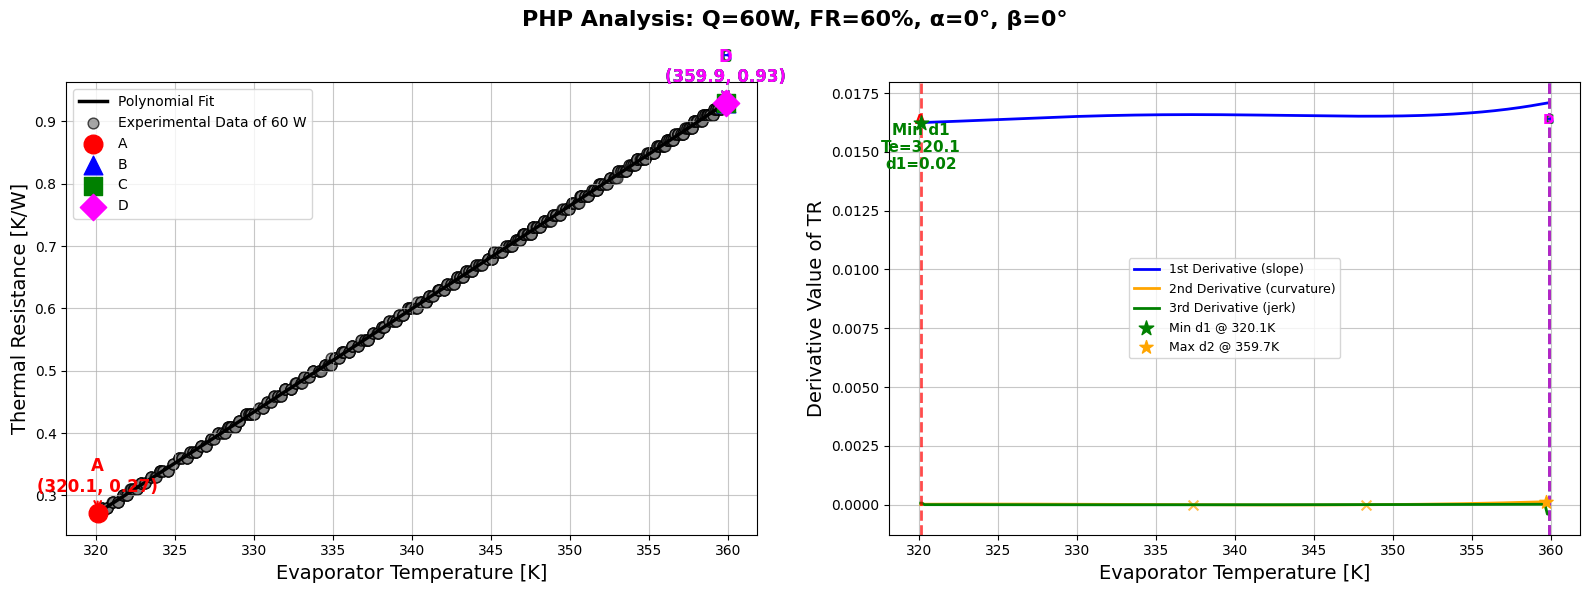

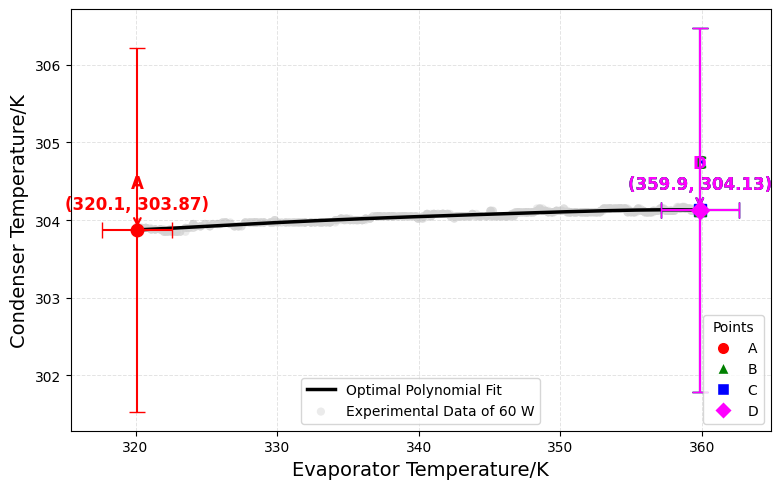

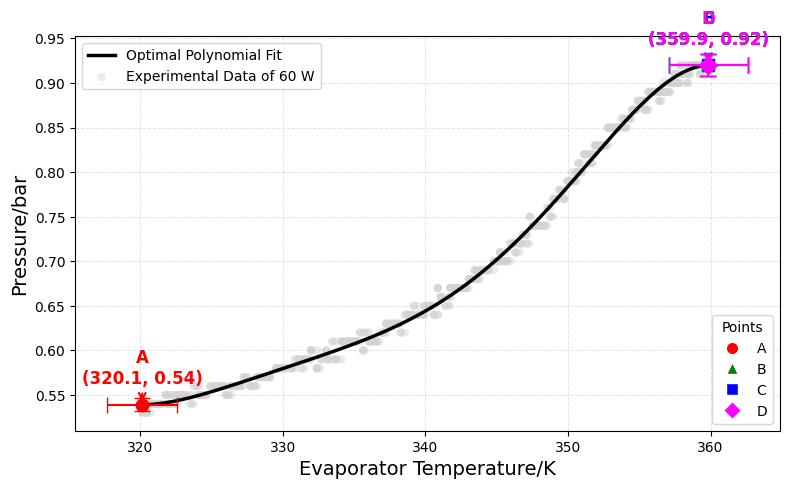

In [74]:
csv_path = 'database_alpha.csv'
Q, FR, alpha, beta = 60, 60, 0, 0
te_min, te_max = 320, 360

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label=f'Experimental Data of {Q} W')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{plot_label}')
        ax1.annotate(f'{plot_label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
    
    ax1.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax1.set_ylabel('Thermal Resistance [K/W]', fontsize=14)
    #ax1.set_title('TR vs Te with Critical Points', fontsize=14)
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.7)
    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
        ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')
    
    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR', fontsize=14)
    #ax2.set_title('Derivatives of TR vs Te', fontsize=14)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te and P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

### alpha = 30, beta = 0

SNR of TR fit: 0.03911024203830885
SNR (dB): 24.104882118145813 dB


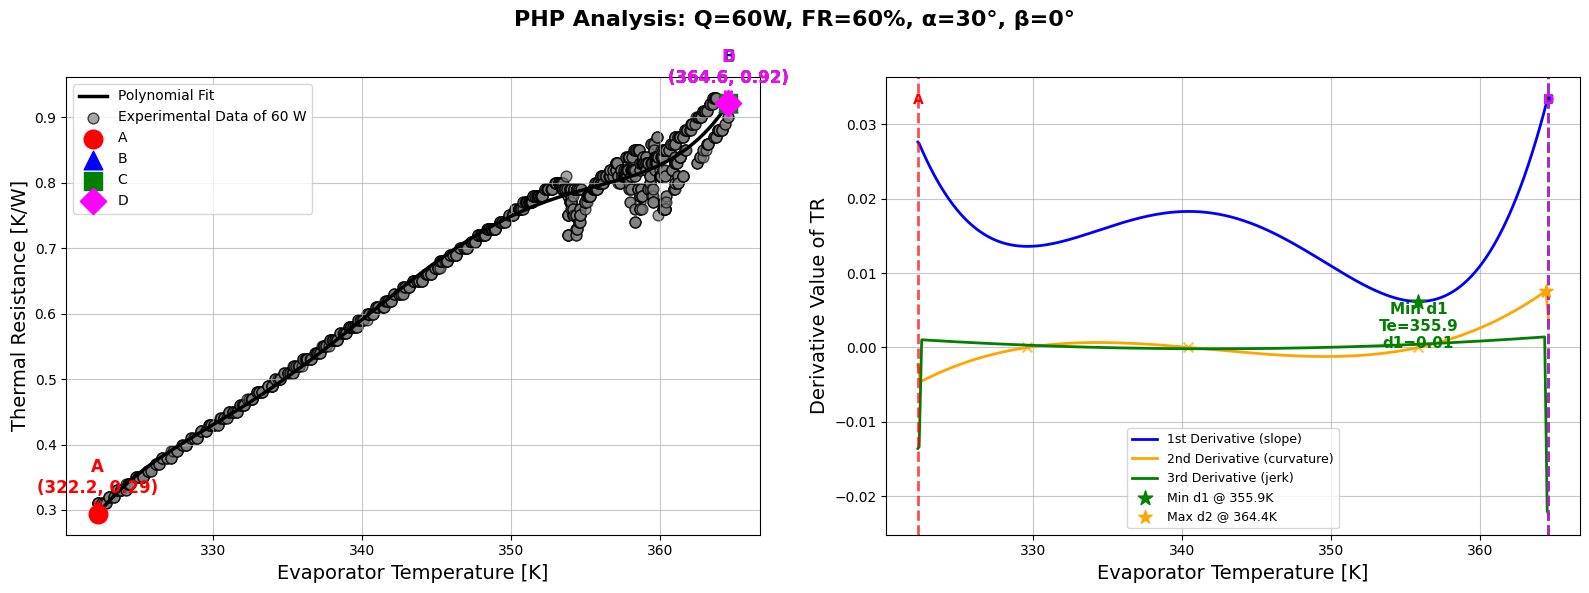

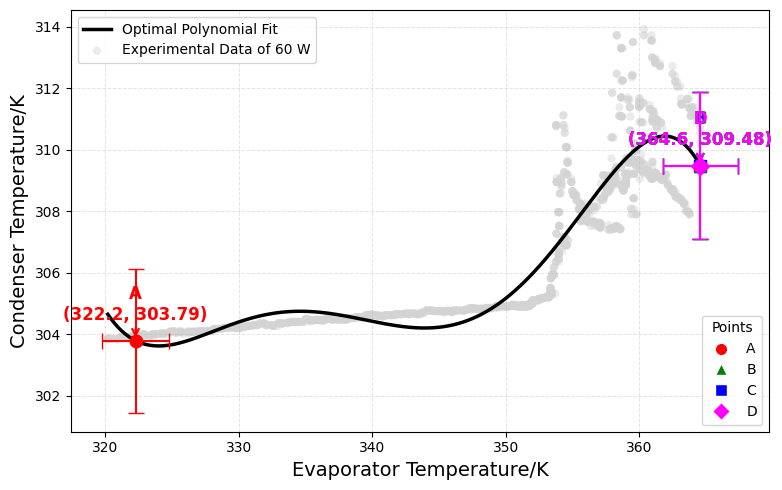

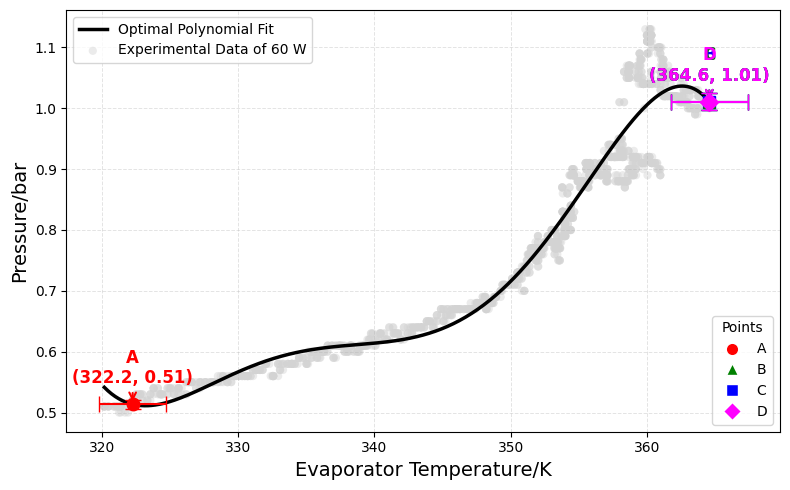

In [75]:
csv_path = 'database_alpha.csv'
Q, FR, alpha, beta = 60, 60, 30, 0
te_min, te_max = 320, 365

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label=f'Experimental Data of {Q} W')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{plot_label}')
        ax1.annotate(f'{plot_label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
    
    ax1.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax1.set_ylabel('Thermal Resistance [K/W]', fontsize=14)
    #ax1.set_title('TR vs Te with Critical Points', fontsize=14)
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.7)
    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
        ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')
    
    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR', fontsize=14)
    #ax2.set_title('Derivatives of TR vs Te', fontsize=14)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te and P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

### alpha = 60, beta = 0

SNR of TR fit: 0.040310876121949626
SNR (dB): 23.235523840842376 dB


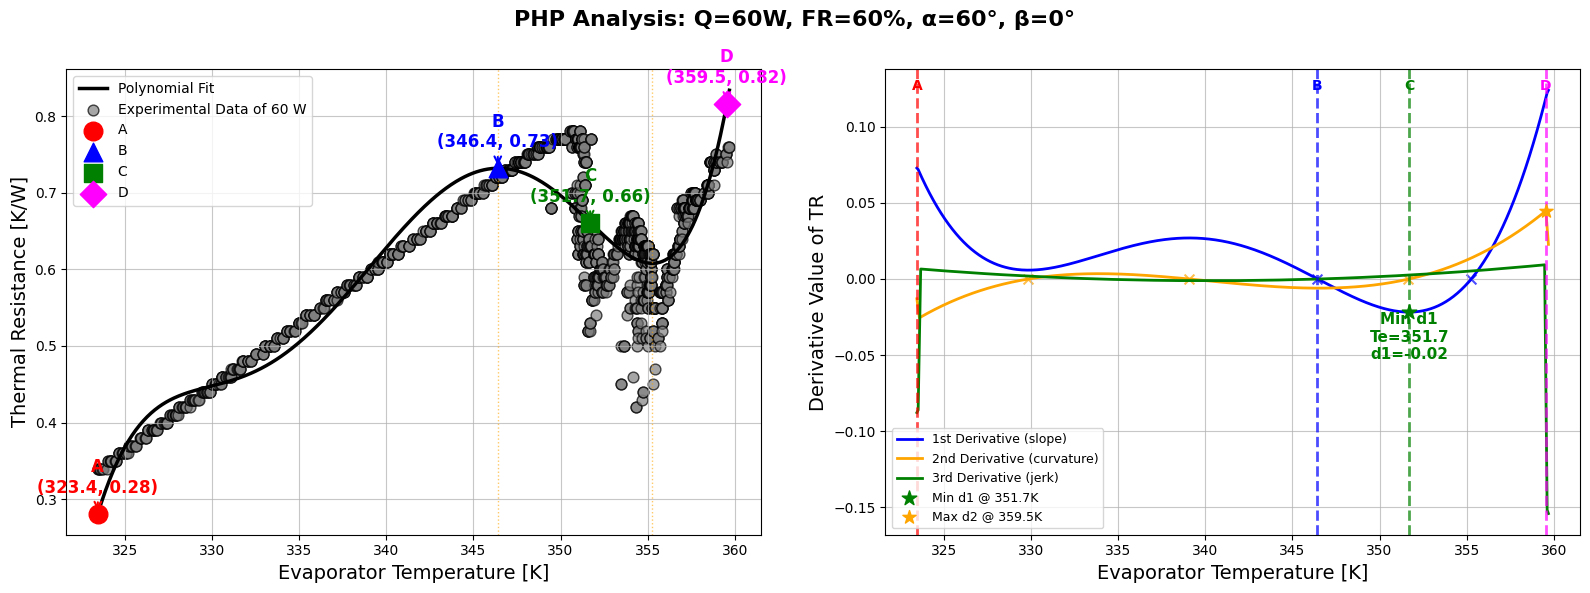

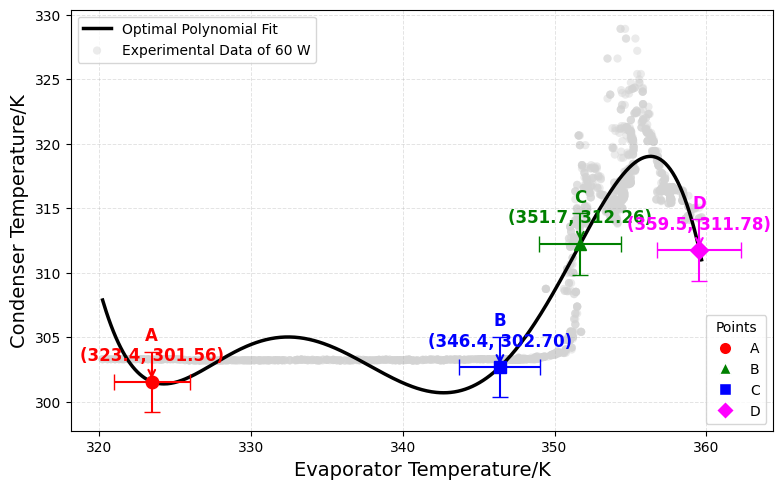

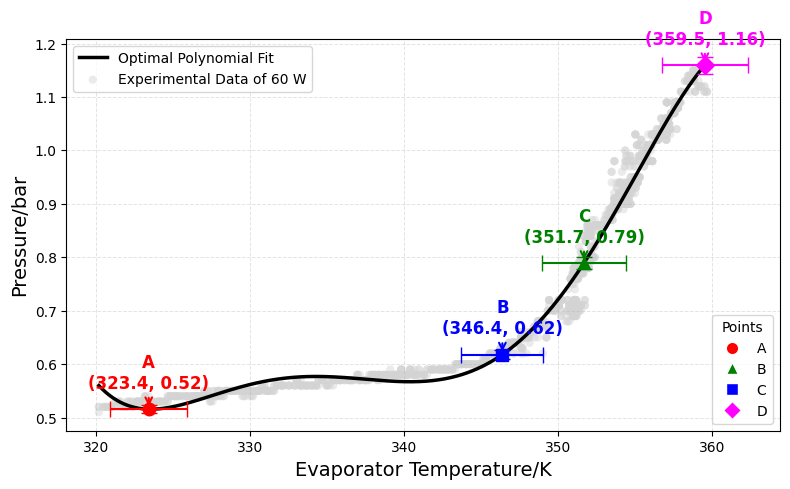

In [76]:
csv_path = 'database_alpha.csv'
Q, FR, alpha, beta = 60, 60, 60, 0
te_min, te_max = 320, 365

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label=f'Experimental Data of {Q} W')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{plot_label}')
        ax1.annotate(f'{plot_label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
    
    ax1.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax1.set_ylabel('Thermal Resistance [K/W]', fontsize=14)
    #ax1.set_title('TR vs Te with Critical Points', fontsize=14)
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.7)
    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
        ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')
    
    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR', fontsize=14)
    #ax2.set_title('Derivatives of TR vs Te', fontsize=14)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te and P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

### alpha = 90, beta = 0

SNR of TR fit: 0.02824999135898696
SNR (dB): 26.66561531586693 dB


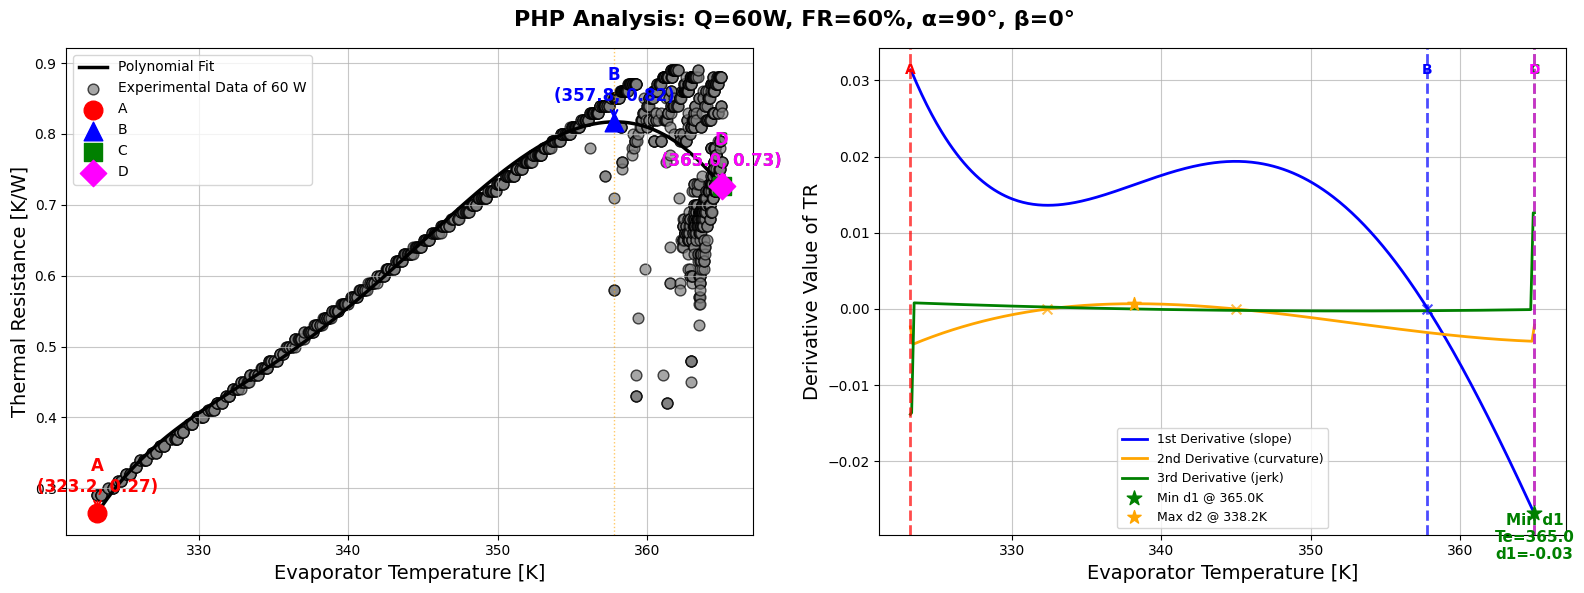

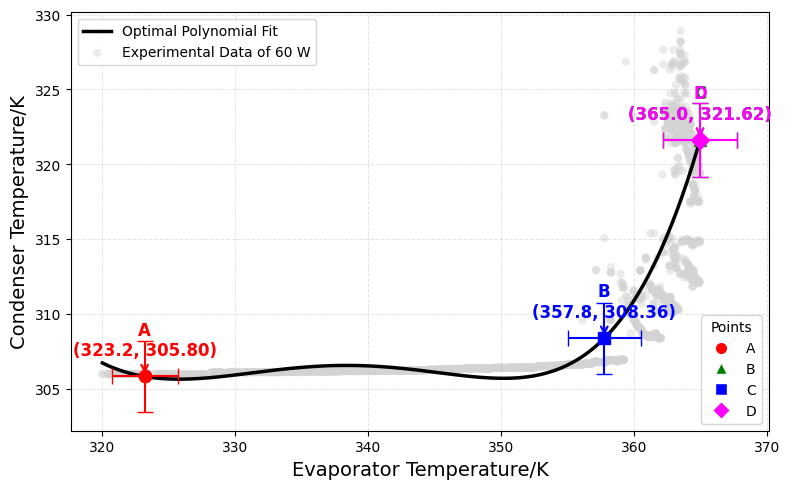

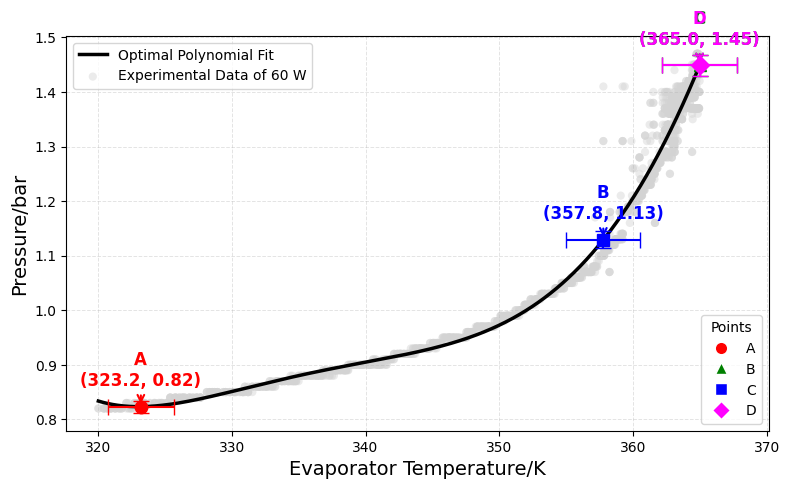

In [77]:
csv_path = 'database_alpha.csv'
Q, FR, alpha, beta = 60, 60, 90, 0
te_min, te_max = 320, 365

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label=f'Experimental Data of {Q} W')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{plot_label}')
        ax1.annotate(f'{plot_label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
    
    ax1.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax1.set_ylabel('Thermal Resistance [K/W]', fontsize=14)
    #ax1.set_title('TR vs Te with Critical Points', fontsize=14)
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.7)
    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
        ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')
    
    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR', fontsize=14)
    #ax2.set_title('Derivatives of TR vs Te', fontsize=14)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te and P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

## 80 W

### alpha = 0, beta = 0

SNR of TR fit: 0.032450292755916904
SNR (dB): 23.66750467870958 dB


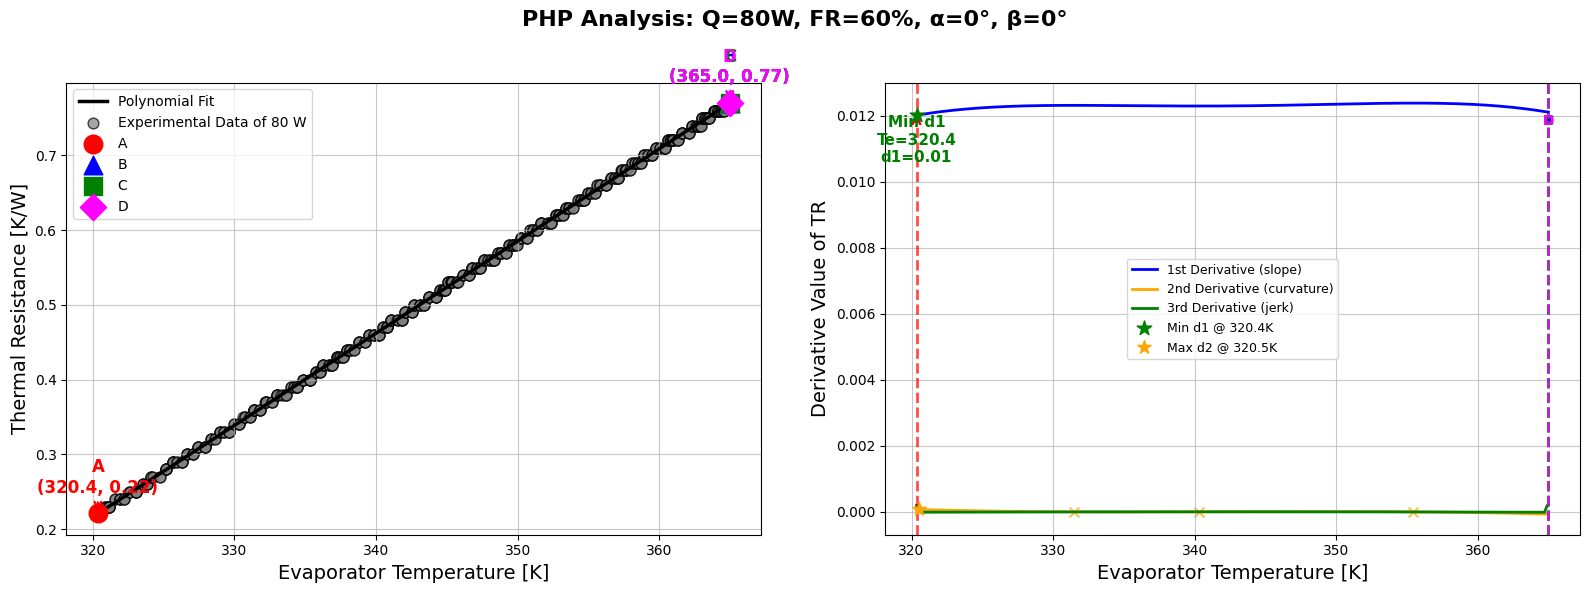

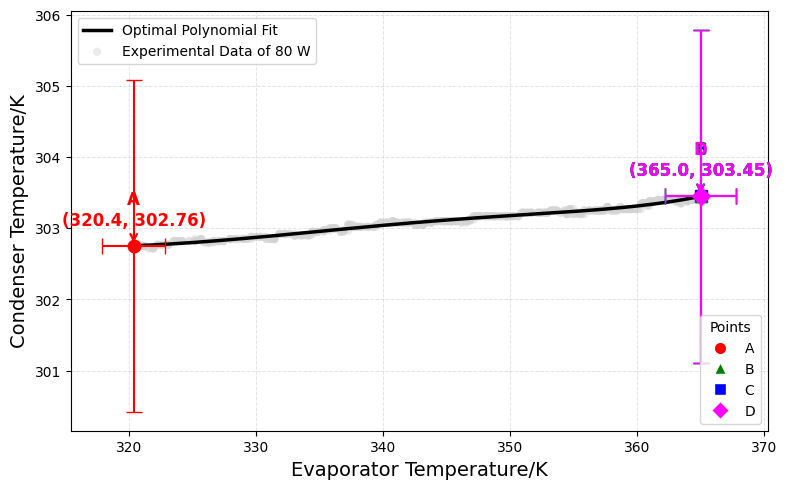

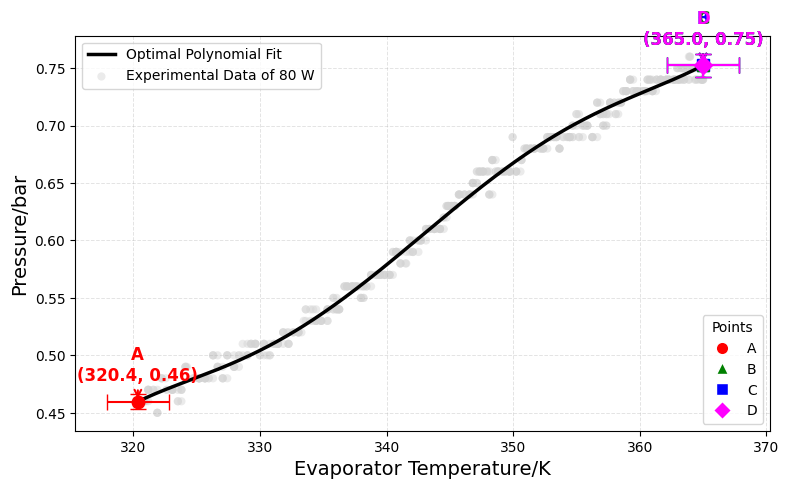

In [78]:
csv_path = 'database_alpha.csv'
Q, FR, alpha, beta = 80, 60, 0, 0
te_min, te_max = 320, 365

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label=f'Experimental Data of {Q} W')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{plot_label}')
        ax1.annotate(f'{plot_label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
    
    ax1.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax1.set_ylabel('Thermal Resistance [K/W]', fontsize=14)
    #ax1.set_title('TR vs Te with Critical Points', fontsize=14)
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.7)
    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
        ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')
    
    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR', fontsize=14)
    #ax2.set_title('Derivatives of TR vs Te', fontsize=14)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te and P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

### alpha = 30, beta = 0

SNR of TR fit: 0.004386938953179973
SNR (dB): 39.58930048546256 dB


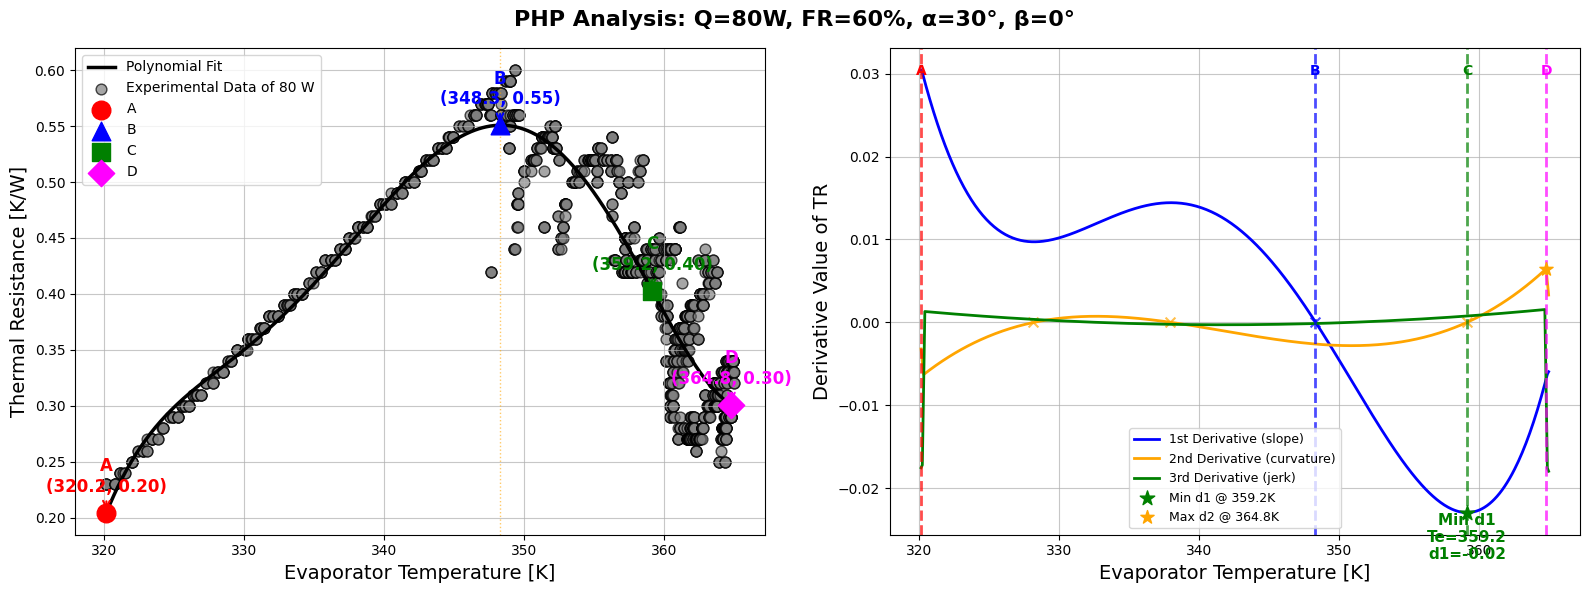

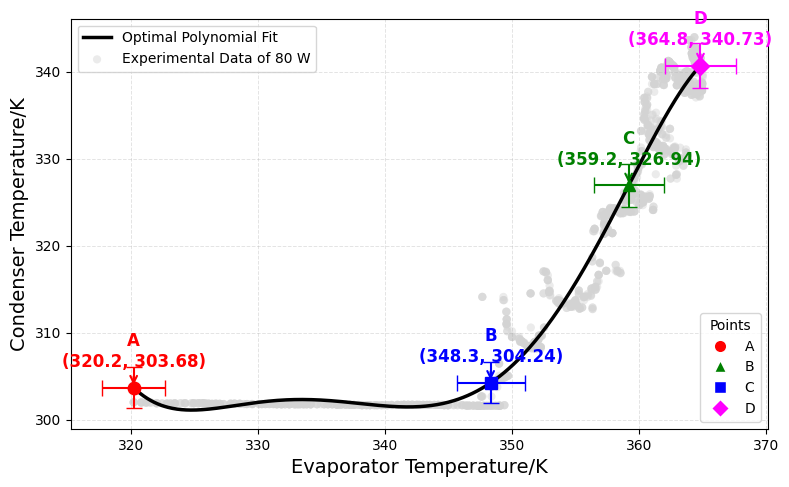

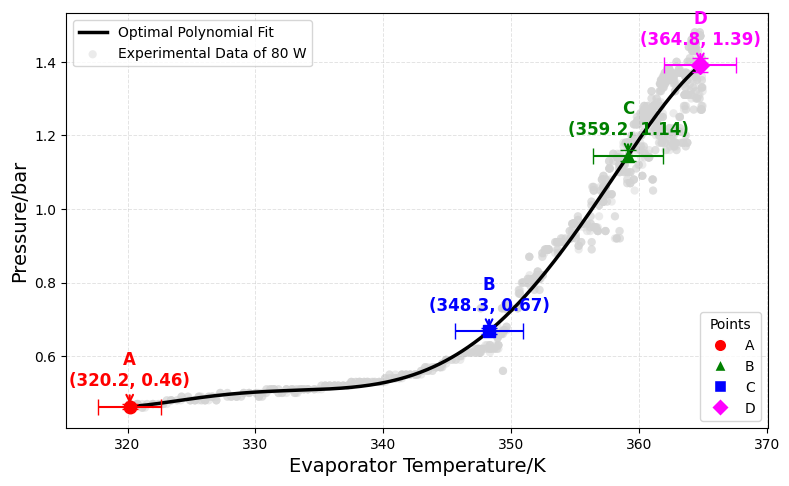

In [79]:
csv_path = 'database_alpha.csv'
Q, FR, alpha, beta = 80, 60, 30, 0
te_min, te_max = 320, 365

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label=f'Experimental Data of {Q} W')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{plot_label}')
        ax1.annotate(f'{plot_label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
    
    ax1.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax1.set_ylabel('Thermal Resistance [K/W]', fontsize=14)
    #ax1.set_title('TR vs Te with Critical Points', fontsize=14)
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.7)
    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
        ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')
    
    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR', fontsize=14)
    #ax2.set_title('Derivatives of TR vs Te', fontsize=14)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te and P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

### alpha = 60, beta = 0

SNR of TR fit: 0.005658777241743104
SNR (dB): 37.09874580848561 dB


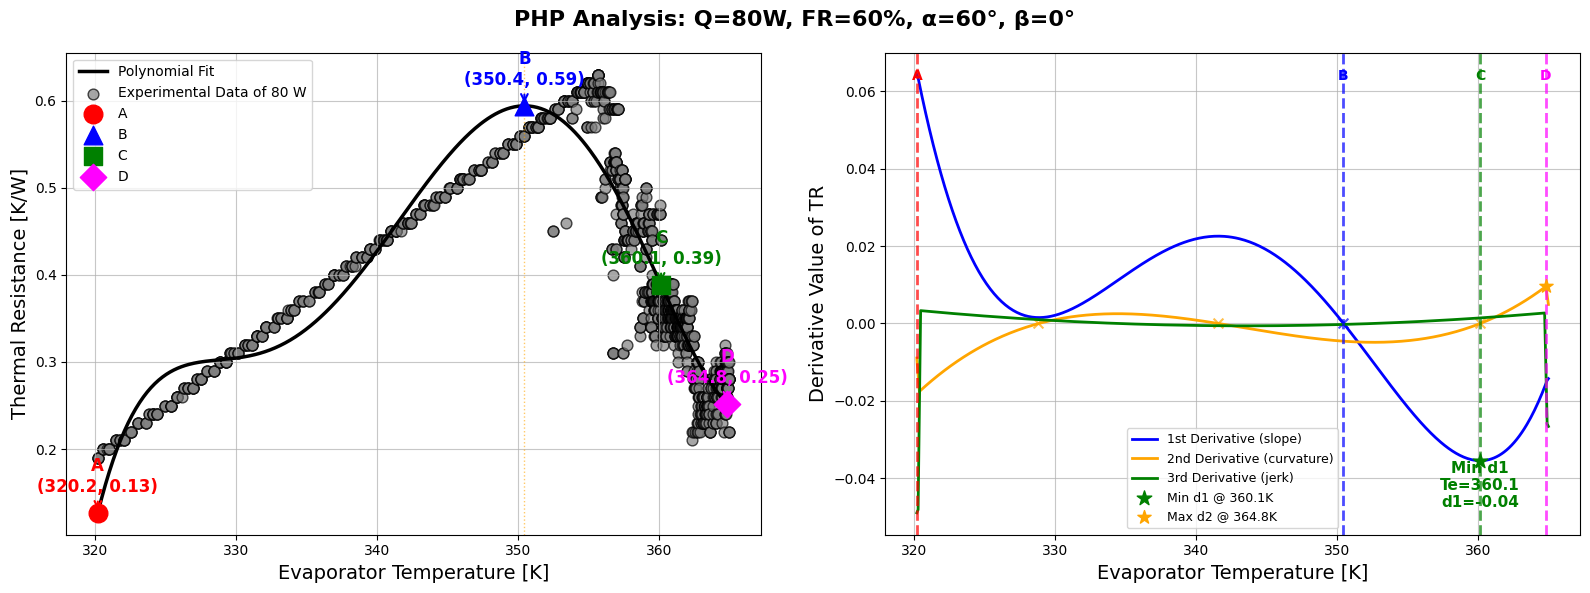

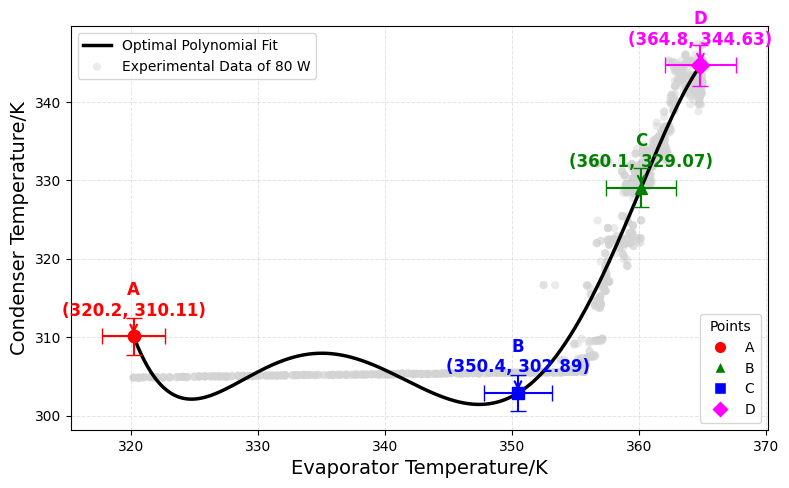

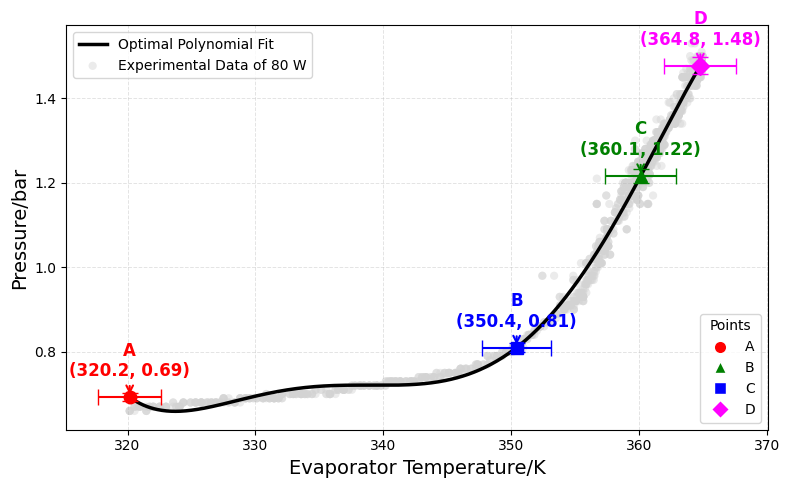

In [80]:
csv_path = 'database_alpha.csv'
Q, FR, alpha, beta = 80, 60, 60, 0
te_min, te_max = 320, 365

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label=f'Experimental Data of {Q} W')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{plot_label}')
        ax1.annotate(f'{plot_label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
    
    ax1.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax1.set_ylabel('Thermal Resistance [K/W]', fontsize=14)
    #ax1.set_title('TR vs Te with Critical Points', fontsize=14)
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.7)
    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
        ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')
    
    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR', fontsize=14)
    #ax2.set_title('Derivatives of TR vs Te', fontsize=14)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te and P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

### alpha = 90, beta = 0

SNR of TR fit: 0.0010226074458331632
SNR (dB): 52.26063690020521 dB


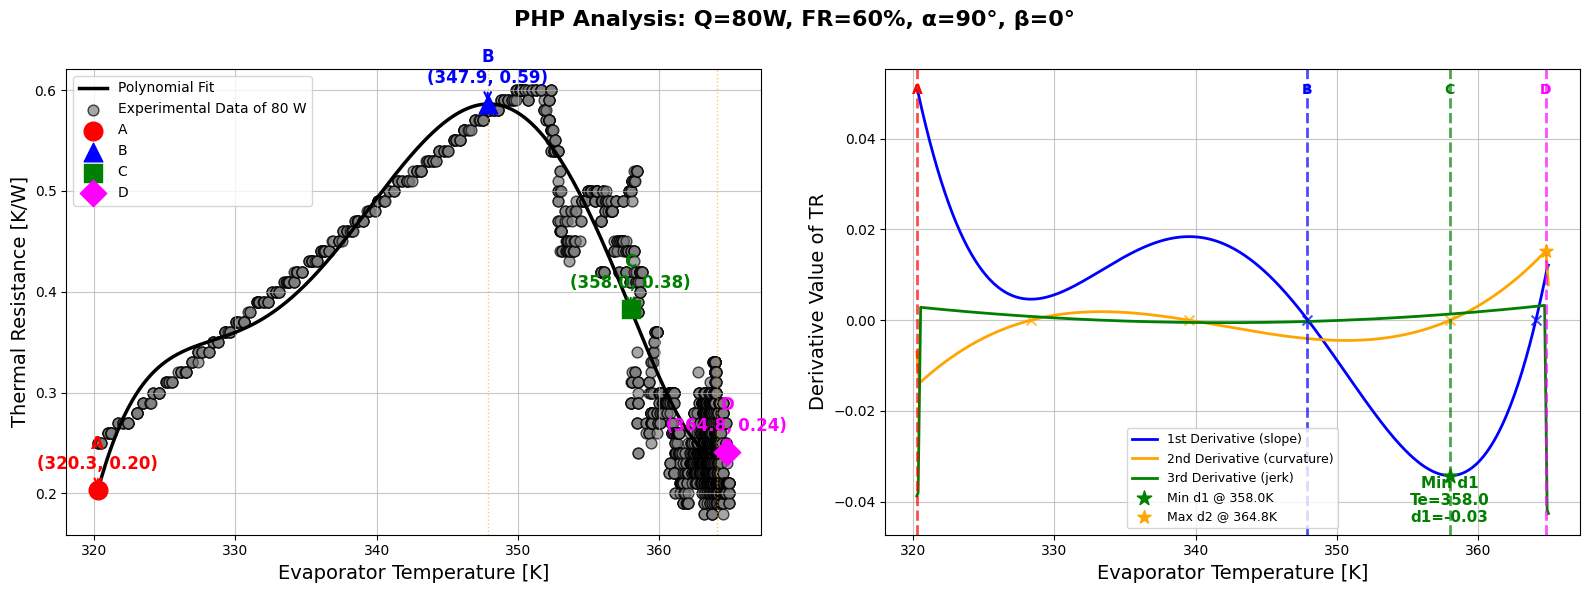

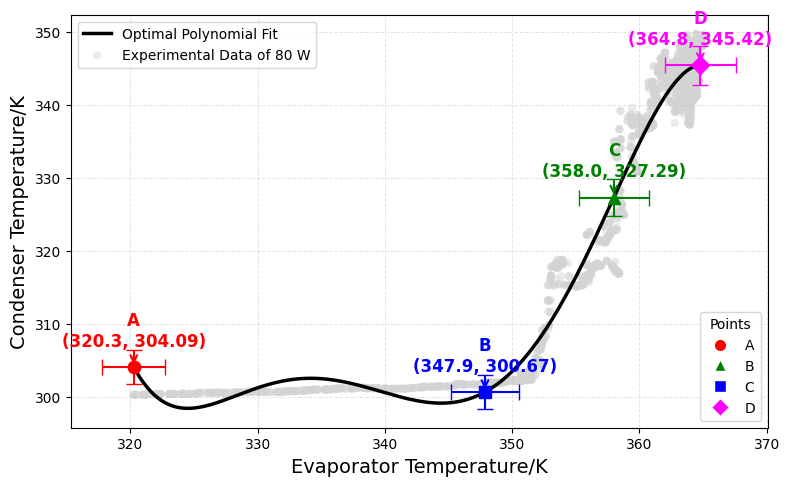

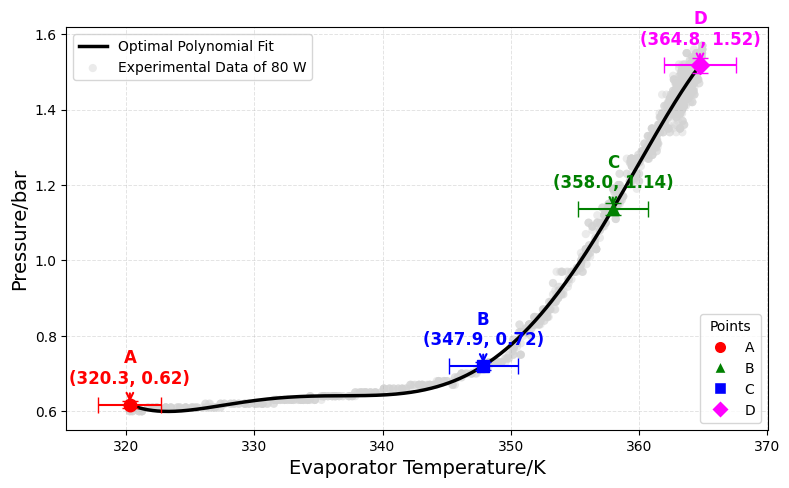

In [81]:
csv_path = 'database_alpha.csv'
Q, FR, alpha, beta = 80, 60, 90, 0
te_min, te_max = 320, 365

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label=f'Experimental Data of {Q} W')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{plot_label}')
        ax1.annotate(f'{plot_label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
    
    ax1.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax1.set_ylabel('Thermal Resistance [K/W]', fontsize=14)
    #ax1.set_title('TR vs Te with Critical Points', fontsize=14)
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.7)
    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
        ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')
    
    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR', fontsize=14)
    #ax2.set_title('Derivatives of TR vs Te', fontsize=14)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te and P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

## 100 W

### alpha = 0, beta = 0

SNR of TR fit: 0.02553859532252307
SNR (dB): 24.032693973379967 dB


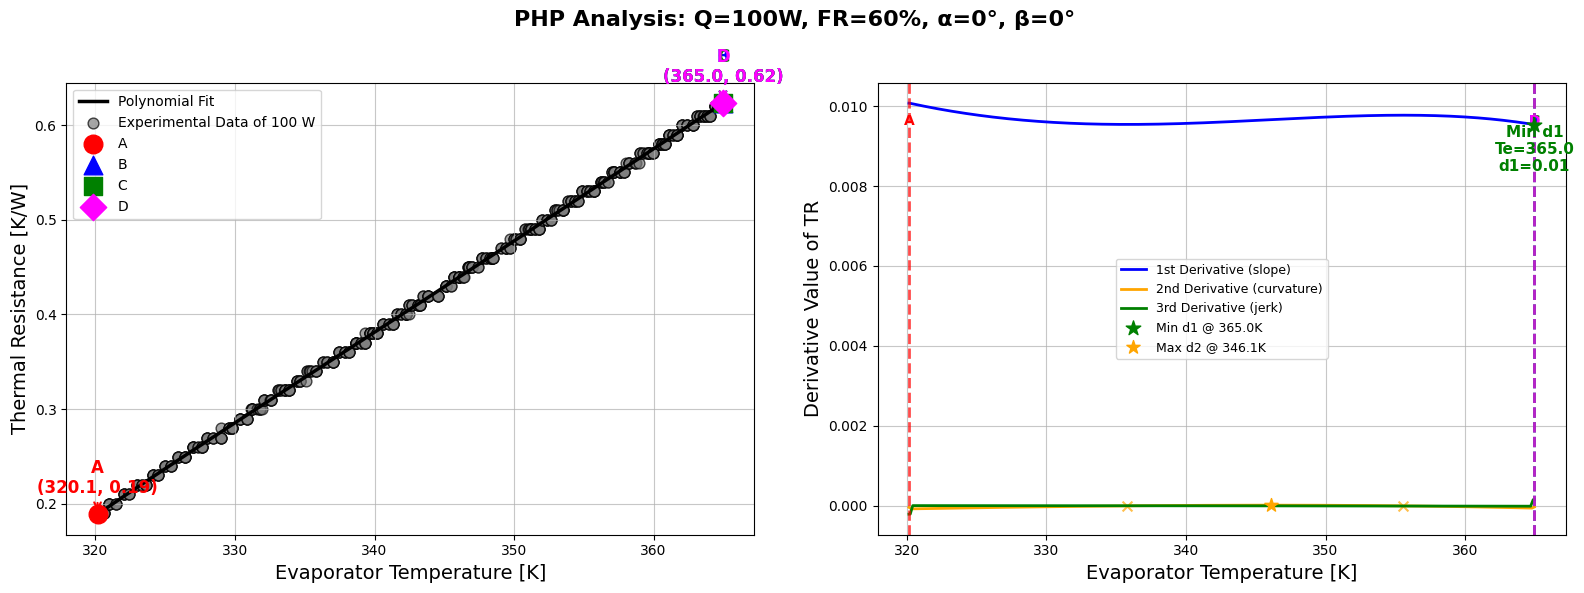

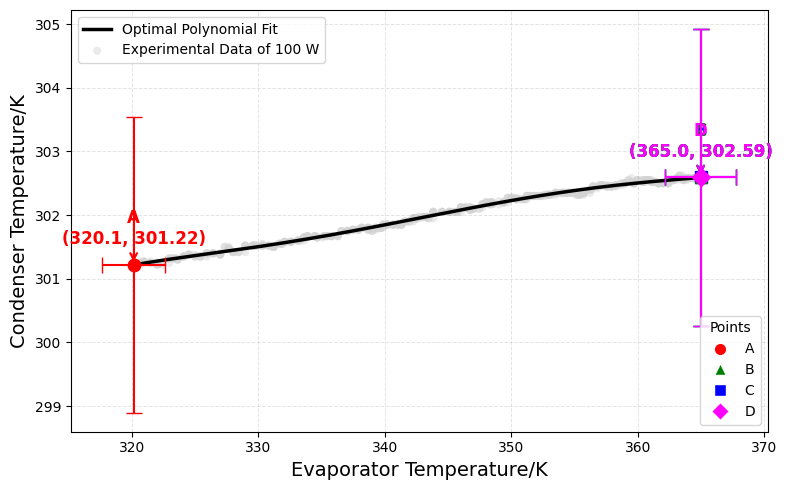

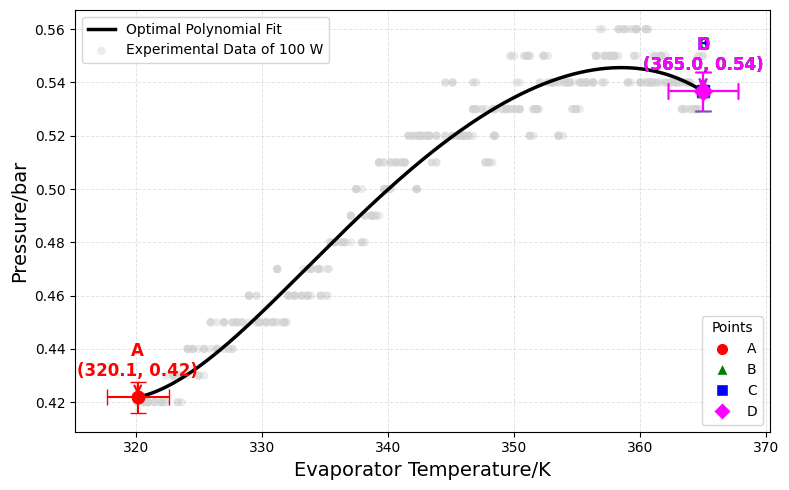

In [82]:
csv_path = 'database_alpha.csv'
Q, FR, alpha, beta = 100, 60, 0, 0
te_min, te_max = 320, 365

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label=f'Experimental Data of {Q} W')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{plot_label}')
        ax1.annotate(f'{plot_label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
    
    ax1.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax1.set_ylabel('Thermal Resistance [K/W]', fontsize=14)
    #ax1.set_title('TR vs Te with Critical Points', fontsize=14)
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.7)
    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
        ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')
    
    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR', fontsize=14)
    #ax2.set_title('Derivatives of TR vs Te', fontsize=14)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te and P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

### alpha = 30, beta = 0

SNR of TR fit: 0.008409748353760163
SNR (dB): 30.73793862404239 dB


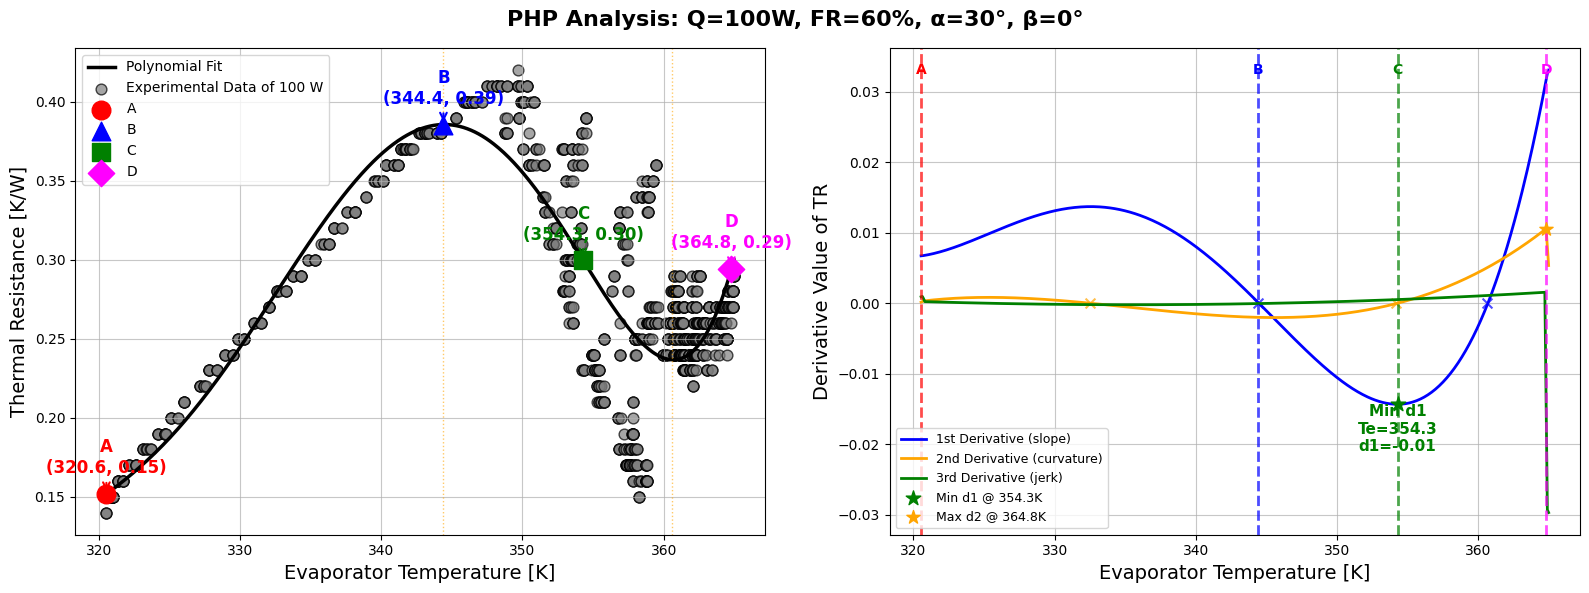

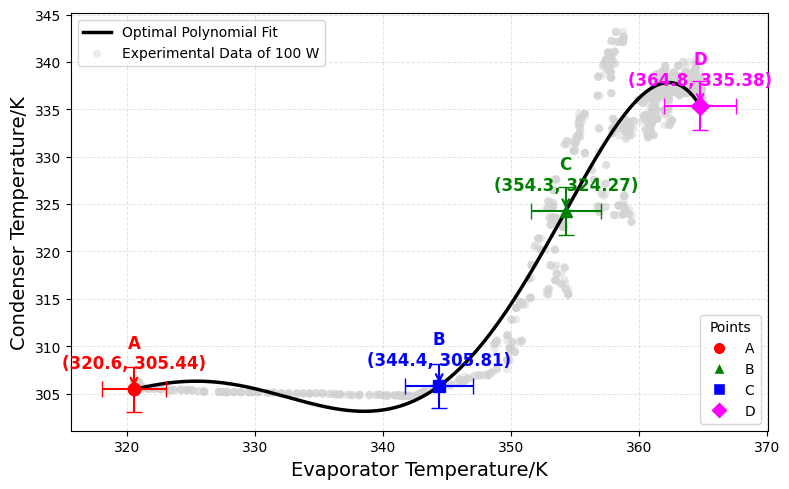

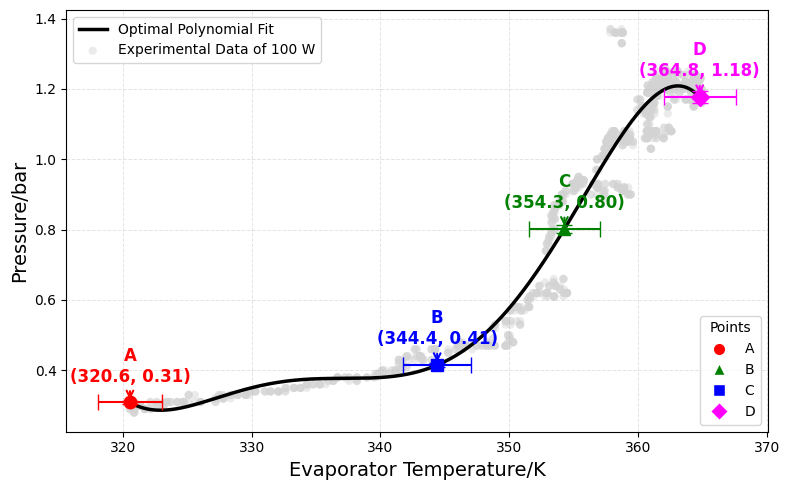

In [83]:
csv_path = 'database_alpha.csv'
Q, FR, alpha, beta = 100, 60, 30, 0
te_min, te_max = 320, 365

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label=f'Experimental Data of {Q} W')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{plot_label}')
        ax1.annotate(f'{plot_label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
    
    ax1.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax1.set_ylabel('Thermal Resistance [K/W]', fontsize=14)
    #ax1.set_title('TR vs Te with Critical Points', fontsize=14)
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.7)
    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
        ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')
    
    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR', fontsize=14)
    #ax2.set_title('Derivatives of TR vs Te', fontsize=14)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te and P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

### alpha = 60, beta = 0

SNR of TR fit: 0.0005560686235596037
SNR (dB): 55.170879062706234 dB


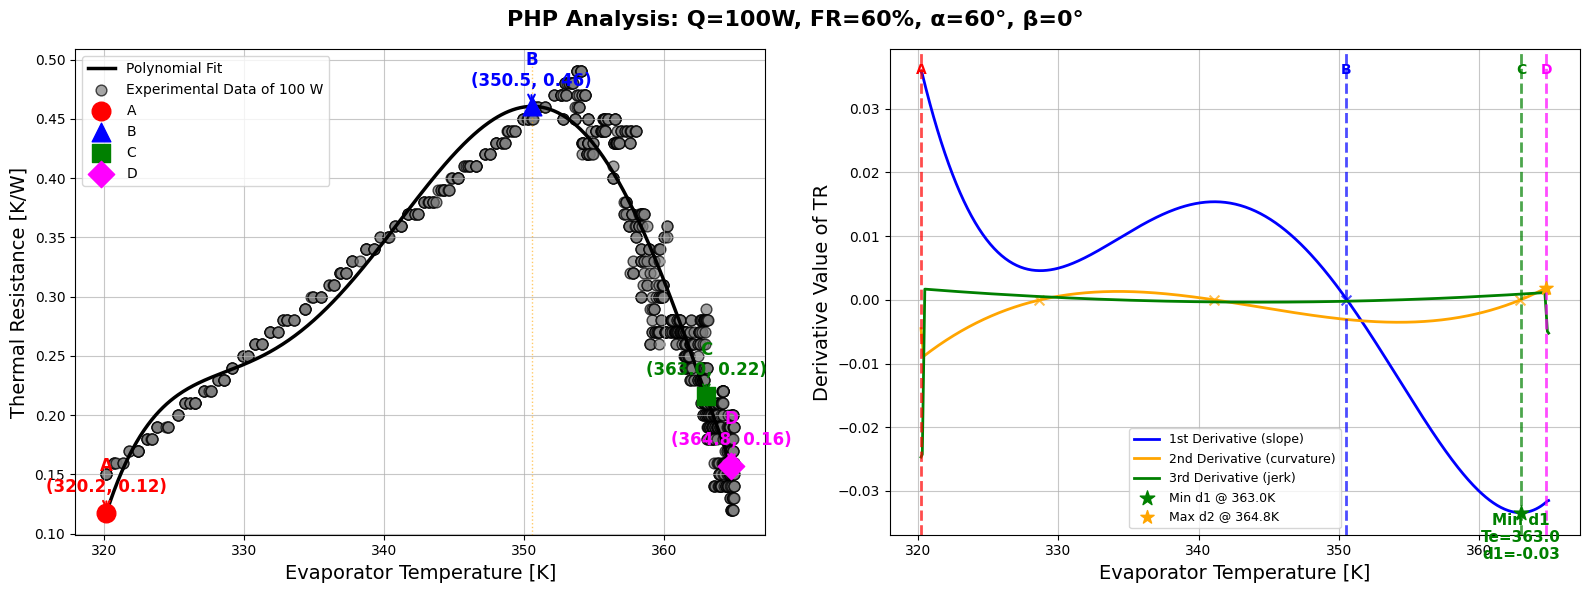

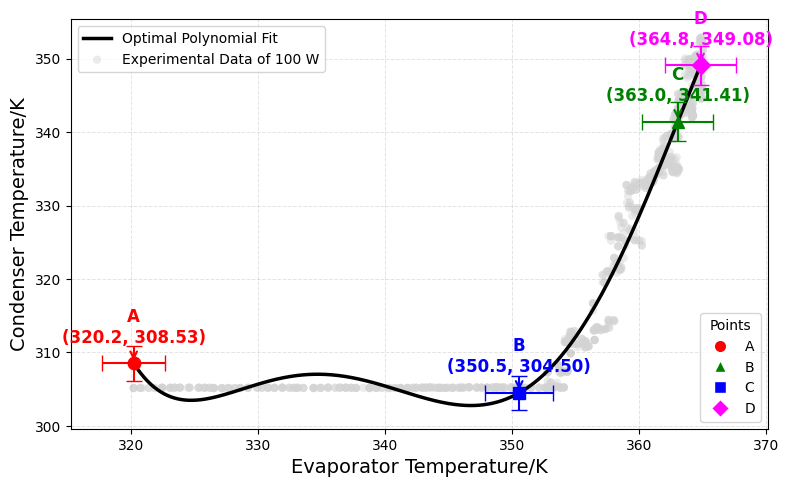

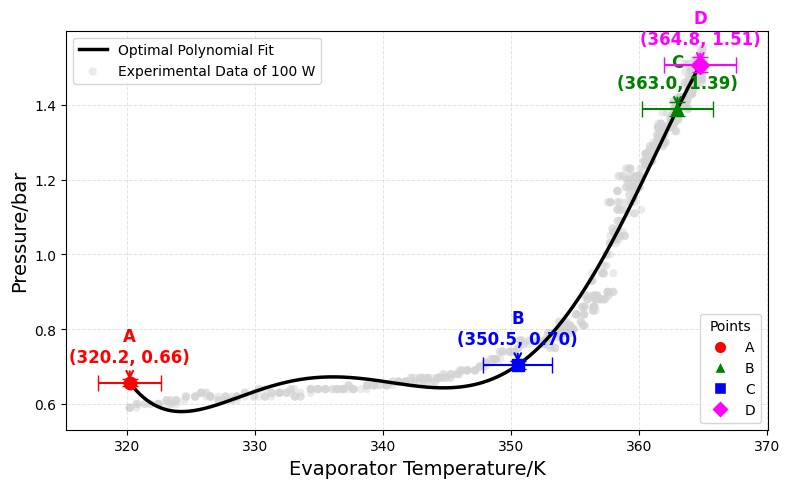

In [84]:
csv_path = 'database_alpha.csv'
Q, FR, alpha, beta = 100, 60, 60, 0
te_min, te_max = 320, 365

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label=f'Experimental Data of {Q} W')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{plot_label}')
        ax1.annotate(f'{plot_label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
    
    ax1.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax1.set_ylabel('Thermal Resistance [K/W]', fontsize=14)
    #ax1.set_title('TR vs Te with Critical Points', fontsize=14)
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.7)
    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
        ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')
    
    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR', fontsize=14)
    #ax2.set_title('Derivatives of TR vs Te', fontsize=14)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te and P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

### alpha = 90, beta = 0

SNR of TR fit: 0.0011265657406785152
SNR (dB): 48.62598157385222 dB


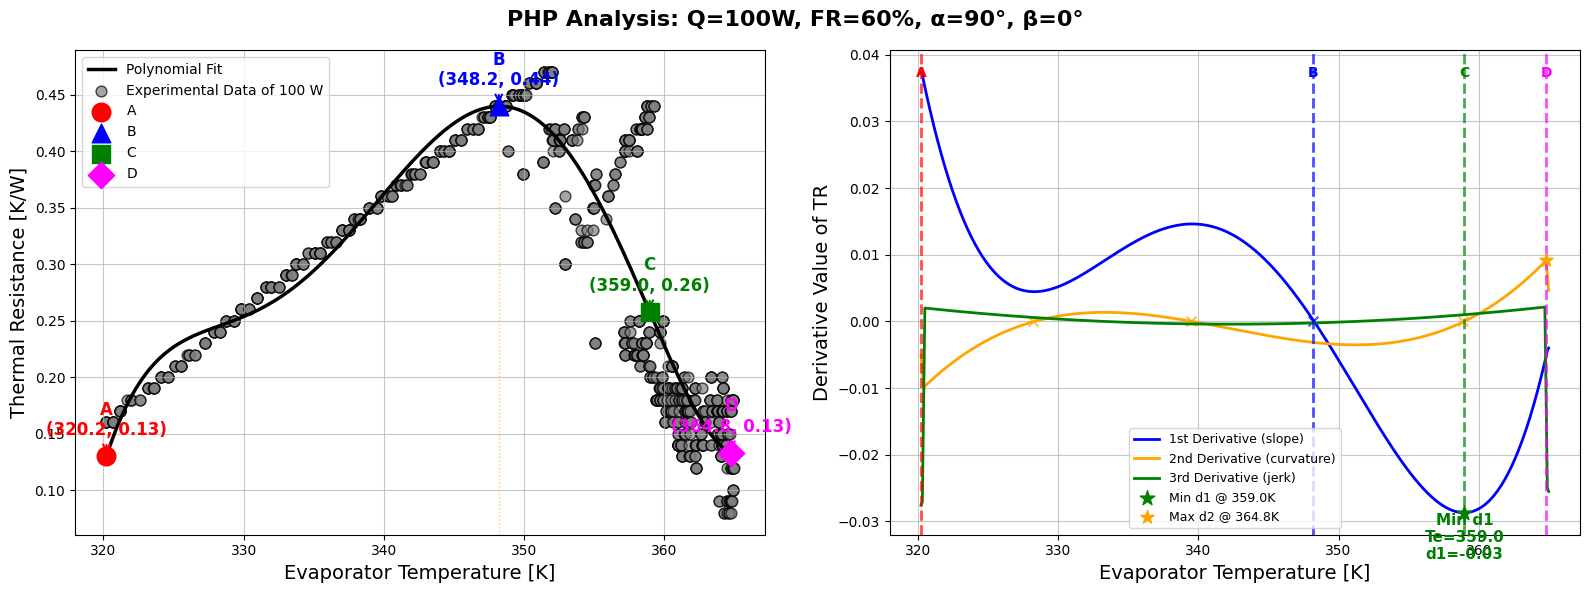

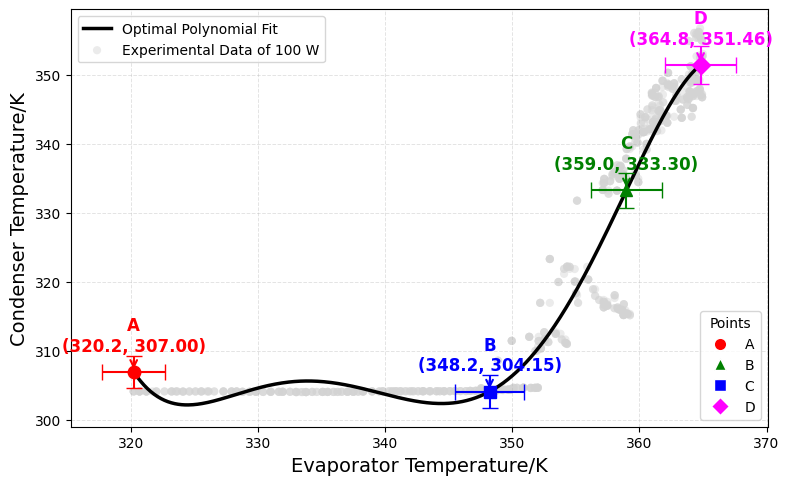

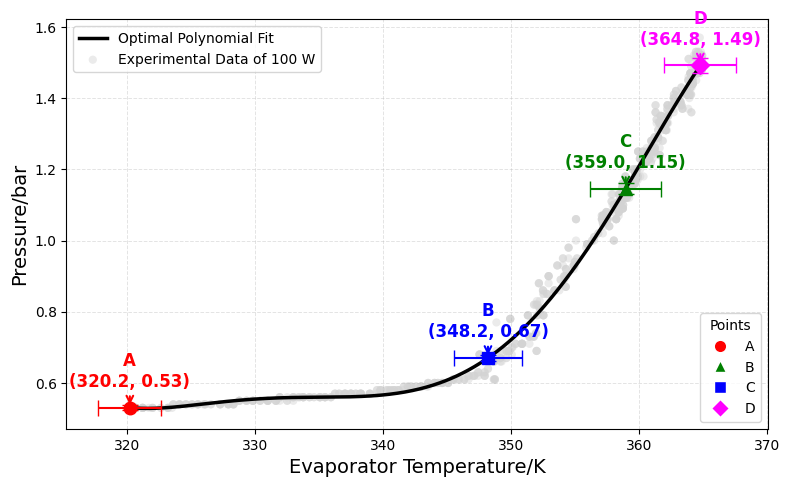

In [85]:
csv_path = 'database_alpha.csv'
Q, FR, alpha, beta = 100, 60, 90, 0
te_min, te_max = 320, 365

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label=f'Experimental Data of {Q} W')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{plot_label}')
        ax1.annotate(f'{plot_label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
    
    ax1.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax1.set_ylabel('Thermal Resistance [K/W]', fontsize=14)
    #ax1.set_title('TR vs Te with Critical Points', fontsize=14)
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.7)
    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
        ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')
    
    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR', fontsize=14)
    #ax2.set_title('Derivatives of TR vs Te', fontsize=14)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te and P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

## 120 W

### alpha = 0, beta = 0

SNR of TR fit: 0.021453194749792893
SNR (dB): 24.093453162356262 dB


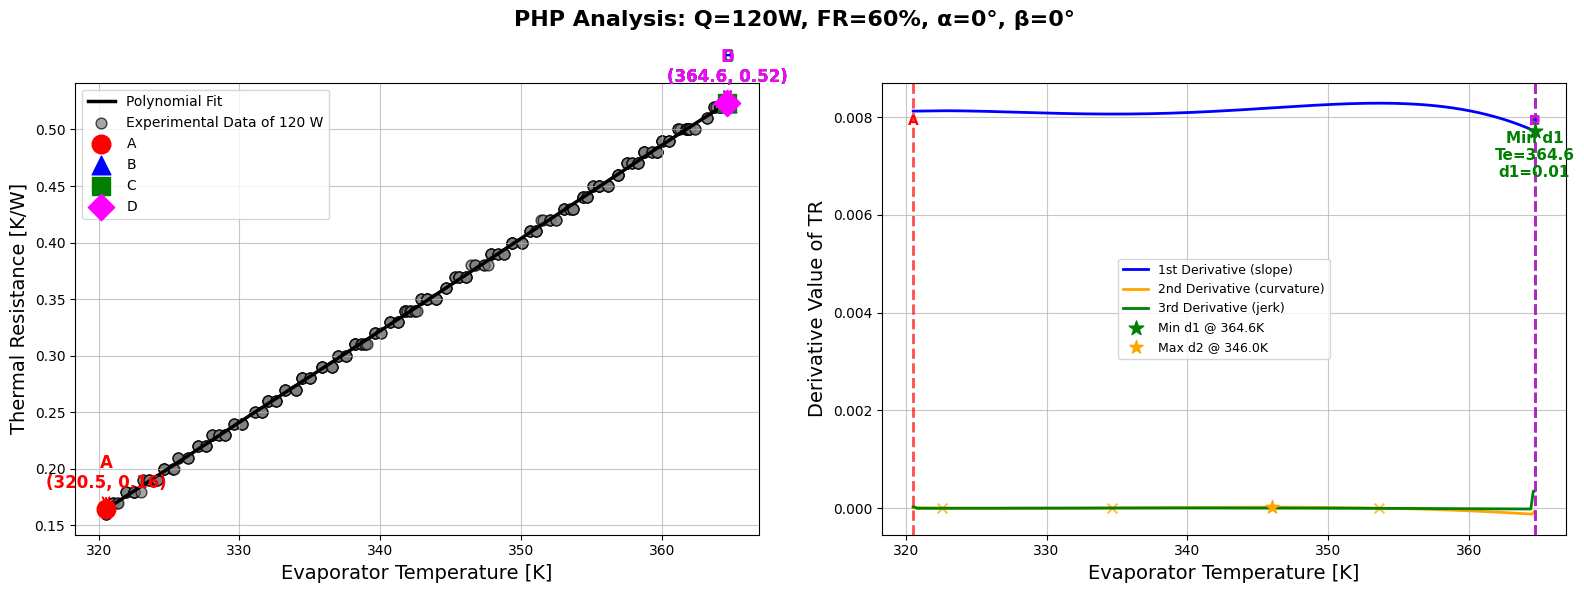

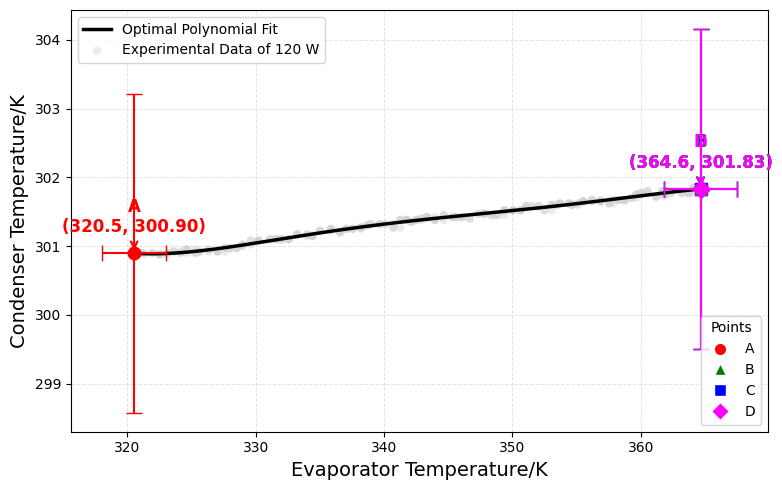

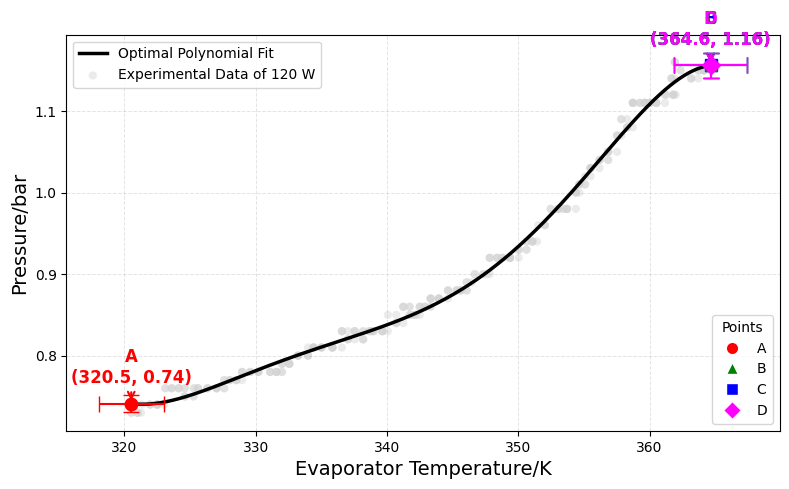

In [86]:
csv_path = 'database_alpha.csv'
Q, FR, alpha, beta = 120, 60, 0, 0
te_min, te_max = 320, 365

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label=f'Experimental Data of {Q} W')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{plot_label}')
        ax1.annotate(f'{plot_label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
    
    ax1.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax1.set_ylabel('Thermal Resistance [K/W]', fontsize=14)
    #ax1.set_title('TR vs Te with Critical Points', fontsize=14)
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.7)
    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
        ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')
    
    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR', fontsize=14)
    #ax2.set_title('Derivatives of TR vs Te', fontsize=14)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te and P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

### alpha = 30, beta = 0

SNR of TR fit: 0.0019555275746250115
SNR (dB): 43.38173923277794 dB


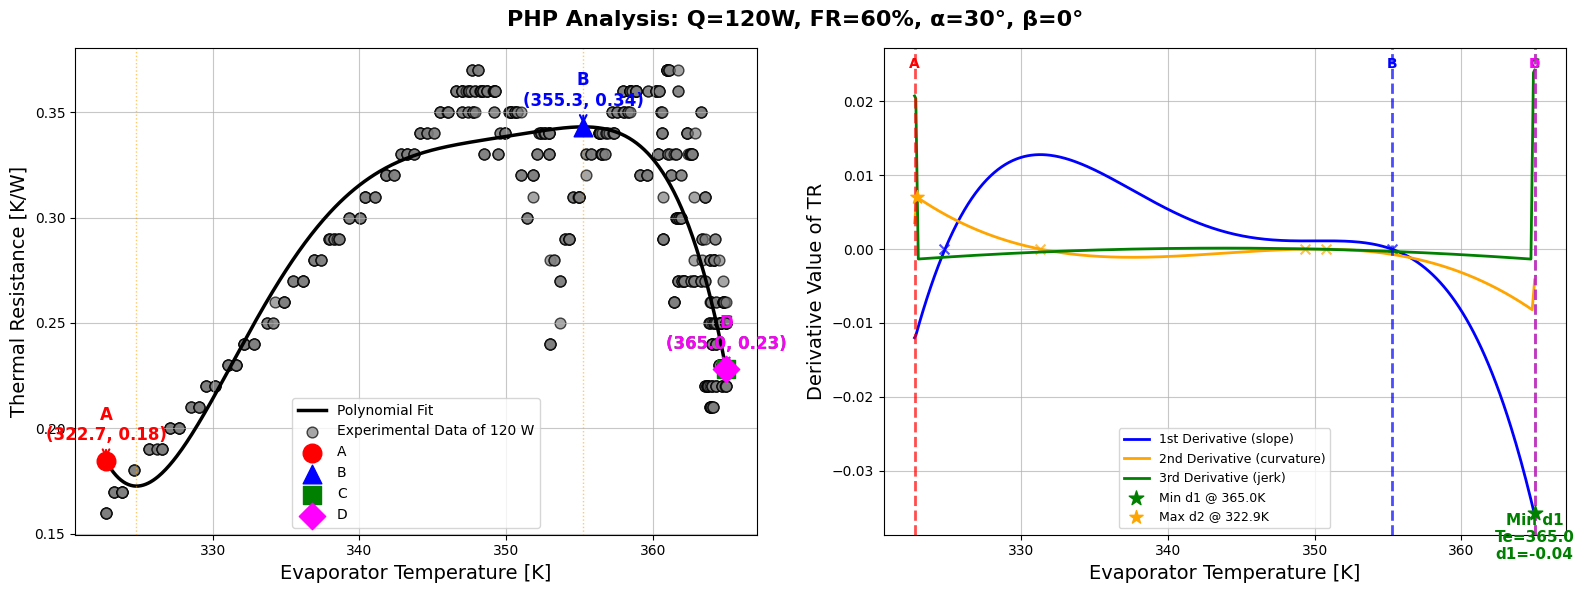

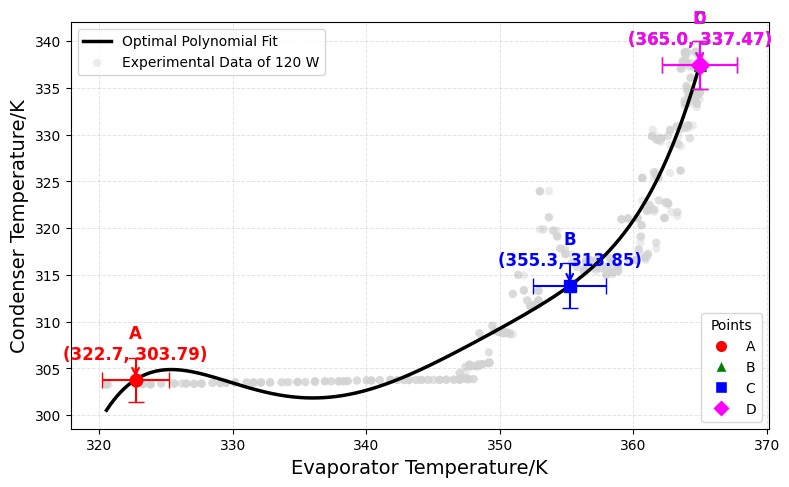

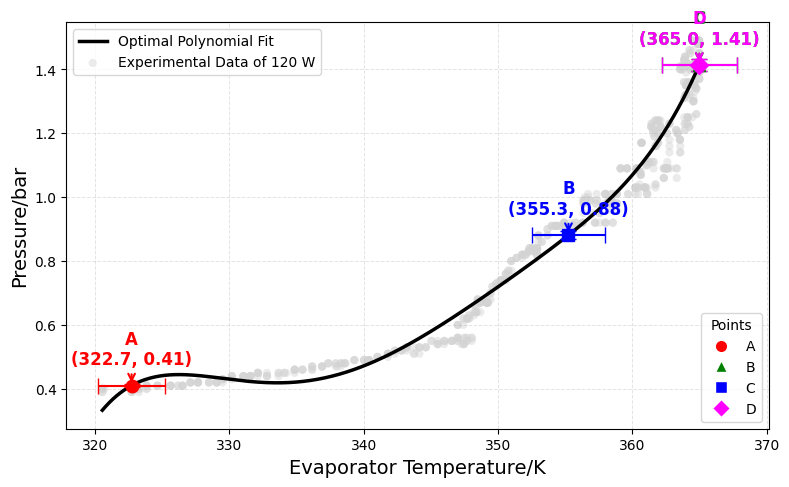

In [87]:
csv_path = 'database_alpha.csv'
Q, FR, alpha, beta = 120, 60, 30, 0
te_min, te_max = 320, 365

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label=f'Experimental Data of {Q} W')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{plot_label}')
        ax1.annotate(f'{plot_label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
    
    ax1.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax1.set_ylabel('Thermal Resistance [K/W]', fontsize=14)
    #ax1.set_title('TR vs Te with Critical Points', fontsize=14)
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.7)
    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
        ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')
    
    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR', fontsize=14)
    #ax2.set_title('Derivatives of TR vs Te', fontsize=14)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te and P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

### alpha = 60, beta = 0

SNR of TR fit: 0.005083561689074754
SNR (dB): 34.681087425928716 dB


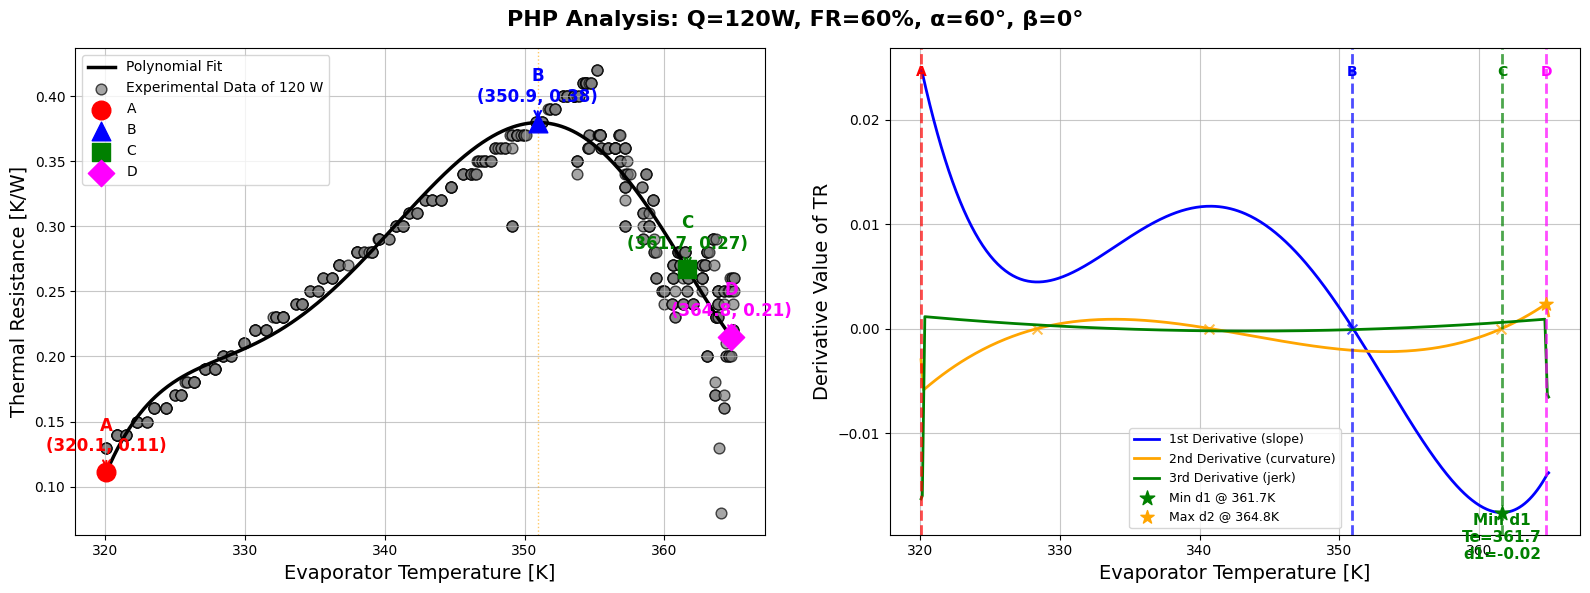

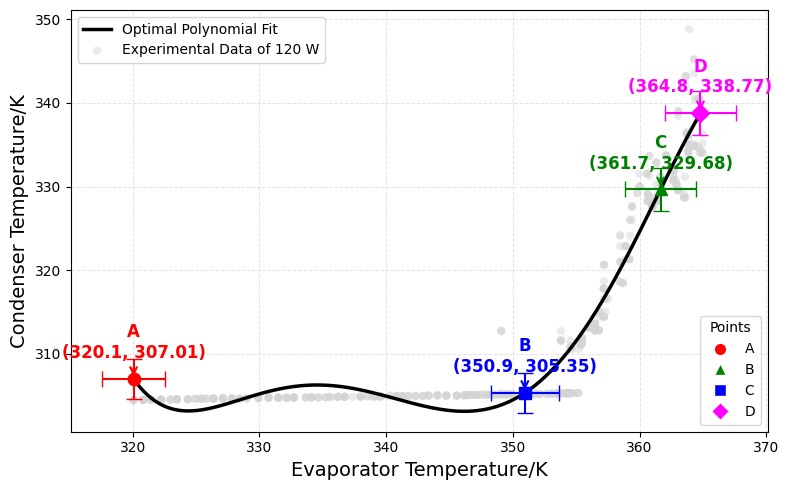

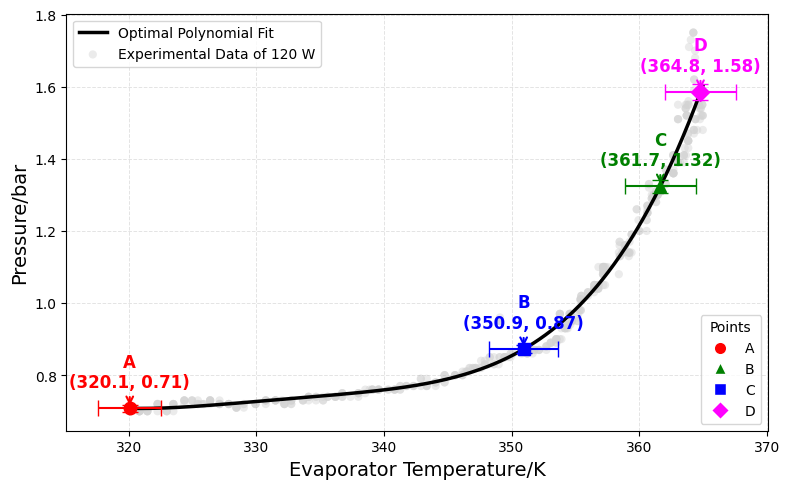

In [88]:
csv_path = 'database_alpha.csv'
Q, FR, alpha, beta = 120, 60, 60, 0
te_min, te_max = 320, 365

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label=f'Experimental Data of {Q} W')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{plot_label}')
        ax1.annotate(f'{plot_label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
    
    ax1.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax1.set_ylabel('Thermal Resistance [K/W]', fontsize=14)
    #ax1.set_title('TR vs Te with Critical Points', fontsize=14)
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.7)
    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
        ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')
    
    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR', fontsize=14)
    #ax2.set_title('Derivatives of TR vs Te', fontsize=14)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te and P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

### alpha = 90, beta = 0

SNR of TR fit: 0.005835121232772375
SNR (dB): 32.81026687737855 dB


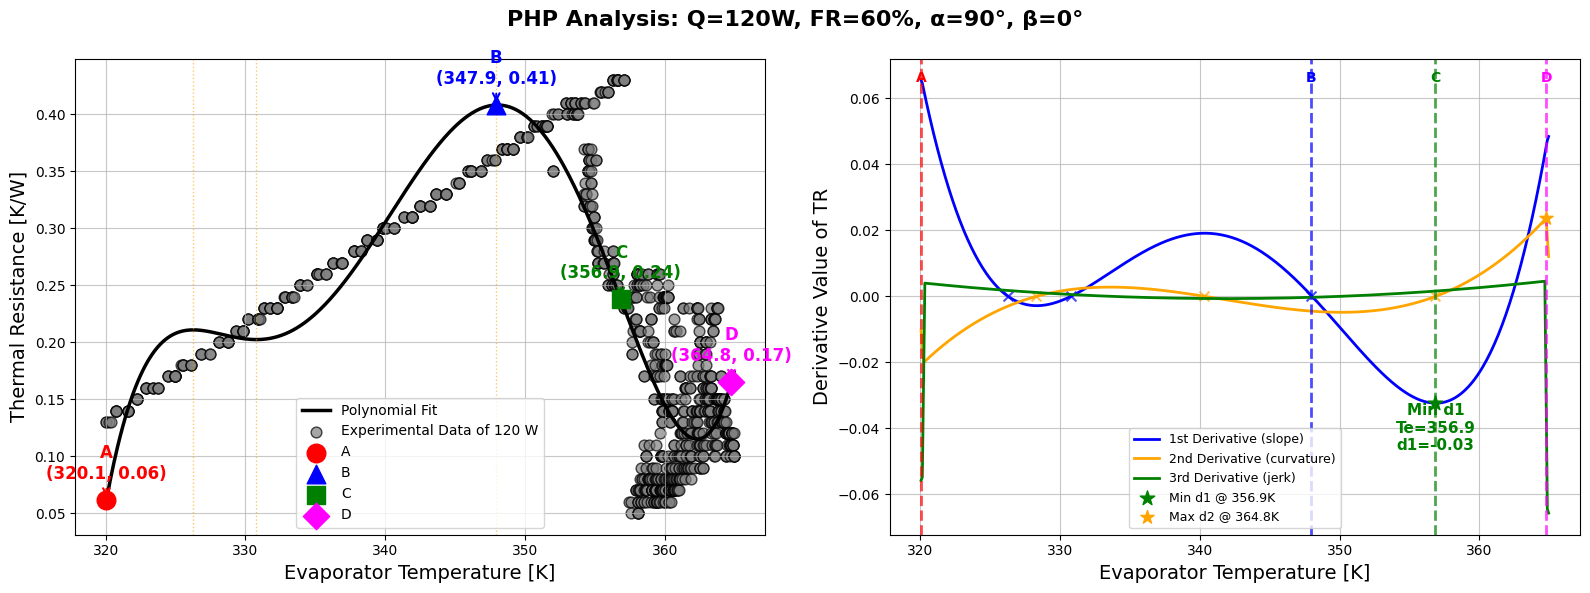

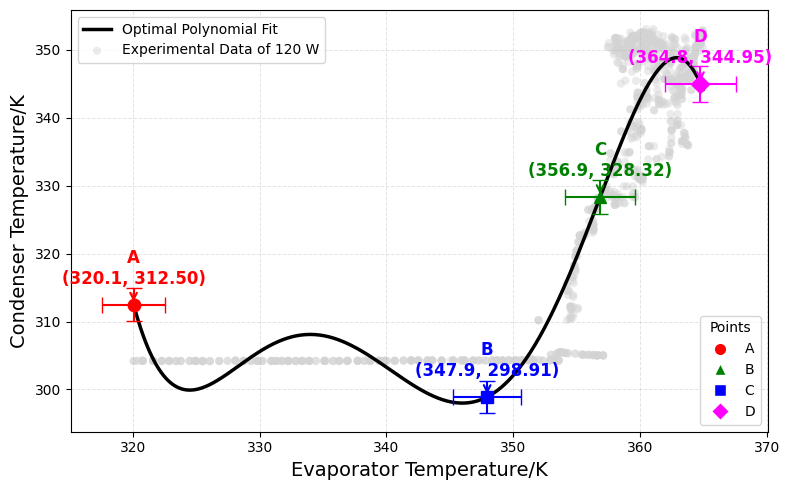

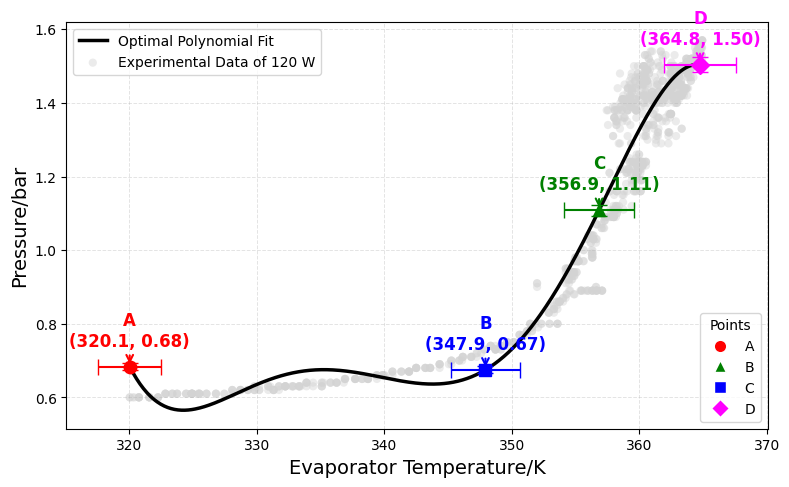

In [89]:
csv_path = 'database_alpha.csv'
Q, FR, alpha, beta = 120, 60, 90, 0
te_min, te_max = 320, 365

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label=f'Experimental Data of {Q} W')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{plot_label}')
        ax1.annotate(f'{plot_label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
    
    ax1.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax1.set_ylabel('Thermal Resistance [K/W]', fontsize=14)
    #ax1.set_title('TR vs Te with Critical Points', fontsize=14)
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.7)
    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
        ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')
    
    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR', fontsize=14)
    #ax2.set_title('Derivatives of TR vs Te', fontsize=14)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te and P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

# summary of points A to D

In [91]:
import pandas as pd
import numpy as np

csv_path = 'database_alpha.csv'
FR = 60
beta = 0
te_min, te_max = 320, 365

Q_list = [40, 60, 80, 100, 120]
alpha_list = [0, 30, 60, 90]

results_list = []

for Q in Q_list:
    for alpha in alpha_list:
        import sys
        import contextlib
        with contextlib.redirect_stdout(None):
            results_TR = analyze_TR_vs_Te(
                csv_path=csv_path,
                Q=Q, FR=FR, alpha=alpha, beta=beta,
                te_min=te_min, te_max=te_max,
                poly_deg='auto',
                outlier_threshold=2.5,
                max_poly_deg=15,
                min_poly_deg=5
            )
        if results_TR is not None:
            points = results_TR['points']
            Te_fine = results_TR['Te_fine']
            Te_points = {
                'Q': Q,
                'alpha': alpha,
                'A': round(Te_fine[points['A']], 2),
                'B': round(Te_fine[points['C']], 2),  # swapped
                'C': round(Te_fine[points['B']], 2),  # swapped
                'D': round(Te_fine[points['D']], 2)
            }
            results_list.append(Te_points)
        else:
            results_list.append({'Q': Q, 'alpha': alpha, 'A': np.nan, 'B': np.nan, 'C': np.nan, 'D': np.nan})

Te_points_df = pd.DataFrame(results_list)
Te_points_df

,Q,alpha,A,B,C,D
0,40,0,320.07,355.57,355.57,355.57
1,40,30,320.25,357.65,357.65,357.65
2,40,60,320.17,356.89,356.89,356.89
3,40,90,320.31,349.75,353.17,353.17
4,60,0,320.13,364.97,364.97,364.97
5,60,30,322.25,364.59,364.59,364.59
6,60,60,323.45,346.40,351.70,359.54
7,60,90,323.19,357.79,364.99,364.99
8,80,0,320.35,364.99,364.99,364.99
9,80,30,320.17,348.28,359.15,364.81


# Research paper - alpha (Te: 345 K to 365 K)

## code for csv file

In [1]:
# ============================================================
# STEP 0 : Import Libraries
# ============================================================

import pandas as pd
import numpy as np

# Pandas → Data analysis
# Numpy → Mathematical calculations


# ============================================================
# STEP 1 : Load CSV File
# ============================================================

# Replace with your actual file name
file_path = "database_alpha.csv"

df = pd.read_csv(file_path)

print("\nColumns in Dataset:\n")
print(df.columns)


# ============================================================
# STEP 2 : Define Important Columns
# ============================================================

Q_col     = "Q[W]"
alpha_col = "alpha"
beta_col  = "beta"
Te_col    = "Te_mean[K]"
TR_col    = "TR[K/W]"


# ============================================================
# STEP 3 : Filter Using Te_mean[K]
# Example Range = 345–365 K
# ============================================================

Te_min = 345
Te_max = 365

filtered_df = df[
    (df[Te_col] >= Te_min) &
    (df[Te_col] <= Te_max)
]

print("\nRows After Temperature Filtering:")
print(len(filtered_df))


# ============================================================
# STEP 4 : Select Required Columns
# ============================================================

selected_df = filtered_df[
    [Q_col, alpha_col, beta_col, Te_col, TR_col]
]

print("\nPreview of Selected Data:\n")
print(selected_df.head())


# ============================================================
# STEP 5 : Group Data by
# Q[W], alpha, beta
# ============================================================

grouped = selected_df.groupby(
    [Q_col, alpha_col, beta_col]
)[TR_col]


# ============================================================
# STEP 6 : Calculate Statistics
# ============================================================

result_df = grouped.agg(

    TR_mean = 'mean',      # Mean TR
    TR_std  = 'std',       # Standard deviation
    n       = 'count'      # Number of samples

).reset_index()


# ============================================================
# STEP 7 : Calculate Uncertainty Parameters
# ============================================================

# Standard uncertainty

result_df["uc"] = result_df["TR_std"] / np.sqrt(result_df["n"])


# Expanded uncertainty (95%)
# k-value for n>30 = 2

k_value = 2

result_df["U95"] = k_value * result_df["uc"]


# Coefficient of Variation

result_df["CV_%"] = (
    result_df["TR_std"]
    / result_df["TR_mean"]
) * 100


# ============================================================
# STEP 8 : Sort Results
# ============================================================

result_df = result_df.sort_values(
    by=[Q_col, alpha_col, beta_col]
)


# ============================================================
# STEP 9 : Display Full Table
# ============================================================

print("\nFinal TR Statistical Table:\n")

print(
result_df.round(4).to_string(index=False)
)


# ============================================================
# STEP 10 : Save Full Results
# ============================================================

result_df.round(5).to_csv(

"d4_TR_Statistical_Results.csv",

index=False

)

print("\nSaved File:")
print("d4_TR_Statistical_Results.csv")


# ============================================================
# STEP 11 : Prepare Error-Bar File for Gnuplot
# (Mean ± U95)
# ============================================================

errorbar_df = result_df[

[Q_col,"TR_mean","U95"]

]

errorbar_df.to_csv(

"d4_TR_ErrorBars.csv",

index=False

)

print("\nSaved Error-bar File:")
print("d4_TR_ErrorBars.csv")


# ============================================================
# STEP 12 : Print Journal Format
# ============================================================

print("\nJournal Style Results:\n")

for _, row in result_df.iterrows():

    print(

        "Q =",int(row[Q_col]),"W",

        " alpha =",int(row[alpha_col]),

        " beta =",int(row[beta_col]),

        " TR =",round(row["TR_mean"],3),

        "±",

        round(row["U95"],3),"K/W"

    )


Columns in Dataset:

Index(['TIME', 'DATE', 'TC_1', 'TC_2', 'TC_3', 'TC_4', 'TC_5', 'TC_6', 'TC_7',
       'TC_8', 'TC_9', 'PRESSURE', 'HEATER', 'HEATER SET POINT', 'date',
       'voltage', 'current', 'power', 'WF', 'FR[%]', 'Q[W]', 'alpha', 'beta',
       'pulse', 'Te_mean[C]', 'Tc_mean[C]', 'Te_std[C]', 'Tc_std[C]', 'P[bar]',
       'Te_mean[K]', 'Tc_mean[K]', 'Te_std[K]', 'Tc_std[K]', 'T_pulse[K]',
       'TR[K/W]', 'GFE_Te[KJ/mol]', 'GFE_Tc[KJ/mol]', 'dG[KJ/mol]'],
      dtype='object')

Rows After Temperature Filtering:
16249

Preview of Selected Data:

      Q[W]  alpha  beta  Te_mean[K]  TR[K/W]
1024    40      0     0      345.01     1.03
1025    40      0     0      345.01     1.03
1026    40      0     0      345.01     1.03
1027    40      0     0      345.01     1.03
1028    40      0     0      345.01     1.03

Final TR Statistical Table:

 Q[W]  alpha  beta  TR_mean  TR_std    n     uc    U95    CV_%
   40      0     0   1.1742  0.0777  558 0.0033 0.0066  6.6197
   40  

### Revised U95 Code - 30.4.2026

In [29]:
a = 0
b = 0
q = 40
t = 310
Te_condition = (df["Te_mean[K]"] >= t) & (df["Te_mean[K]"] < t+50)
cols = ["Q[W]", "alpha", "beta", "Te_mean[K]", "TR[K/W]"]

In [30]:
selected_df_1 = df[(Te_condition)&(df["Q[W]"] == q)&(df["alpha"] == a)&(df["beta"] == b)][cols]

In [31]:
TR_mean_345 = selected_df_1["TR[K/W]"].mean()
TR_std_345 = selected_df_1["TR[K/W]"].std()
records = len(selected_df_1)
print(TR_mean_345, TR_std_345, records)

0.8431171409662476 0.326432267617272 1511


In [33]:
# Converting Te_mean to integer for grouping
selected_df_1["Te_mean_int"] = selected_df_1["Te_mean[K]"].round().astype(int)
selected_df_1["mean_TR"] = selected_df_1.groupby("Te_mean_int")["TR[K/W]"].transform("mean")
selected_df_1["std_TR"] = selected_df_1.groupby("Te_mean_int")["TR[K/W]"].transform("std")
selected_df_1["count"] = selected_df_1.groupby("Te_mean_int")["TR[K/W]"].transform("count")
selected_df_1["uc"] = selected_df_1["std_TR"] / np.sqrt(selected_df_1["count"])
k_value = 2
selected_df_1["U95"] = k_value * selected_df_1["uc"]
selected_df_1["CV_%"] = (selected_df_1["std_TR"] / selected_df_1["mean_TR"]) * 100
calculated_df = selected_df_1[["Te_mean_int", "mean_TR", "std_TR", "count", "uc", "U95", "CV_%"]].drop_duplicates().sort_values("Te_mean_int")
print(selected_df_1[["Te_mean_int", "mean_TR", "std_TR", "count", "uc", "U95", "CV_%"]].drop_duplicates().sort_values("Te_mean_int")) 

      Te_mean_int   mean_TR    std_TR  count        uc       U95      CV_%
71            310  0.156667  0.005000      9  0.001667  0.003333  3.191489
80            311  0.175882  0.007123     17  0.001728  0.003455  4.049793
97            312  0.200556  0.008024     18  0.001891  0.003782  4.000716
115           313  0.226316  0.005973     19  0.001370  0.002740  2.639077
134           314  0.250000  0.007746     21  0.001690  0.003381  3.098387
155           315  0.275000  0.005118     22  0.001091  0.002182  1.860968
177           316  0.298462  0.008339     26  0.001635  0.003271  2.793986
203           317  0.326316  0.008307     19  0.001906  0.003812  2.545686
222           318  0.352727  0.007025     22  0.001498  0.002995  1.991624
244           319  0.375000  0.005130     20  0.001147  0.002294  1.367971
264           320  0.397222  0.007519     18  0.001772  0.003545  1.892905
282           321  0.424762  0.010779     21  0.002352  0.004704  2.537697
303           322  0.4522

In [34]:
display(selected_df_1)

,Q[W],alpha,beta,Te_mean[K],TR[K/W],Te_mean_int,mean_TR,std_TR,count,uc,U95,CV_%
71,40,0,0,310.01,0.15,310,0.156667,0.005,9,0.001667,0.003333,3.191489
72,40,0,0,310.01,0.15,310,0.156667,0.005,9,0.001667,0.003333,3.191489
73,40,0,0,310.01,0.15,310,0.156667,0.005,9,0.001667,0.003333,3.191489
74,40,0,0,310.29,0.16,310,0.156667,0.005,9,0.001667,0.003333,3.191489
75,40,0,0,310.29,0.16,310,0.156667,0.005,9,0.001667,0.003333,3.191489
...,...,...,...,...,...,...,...,...,...,...,...,...
1577,40,0,0,355.55,1.30,356,1.300000,0.000,6,0.000000,0.000000,0.000000
1578,40,0,0,355.57,1.30,356,1.300000,0.000,6,0.000000,0.000000,0.000000
1579,40,0,0,355.57,1.30,356,1.300000,0.000,6,0.000000,0.000000,0.000000
1580,40,0,0,355.57,1.30,356,1.300000,0.000,6,0.000000,0.000000,0.000000


In [35]:
display(calculated_df)

,Te_mean_int,mean_TR,std_TR,count,uc,U95,CV_%
71,310,0.156667,0.005000,9,0.001667,0.003333,3.191489
80,311,0.175882,0.007123,17,0.001728,0.003455,4.049793
97,312,0.200556,0.008024,18,0.001891,0.003782,4.000716
115,313,0.226316,0.005973,19,0.001370,0.002740,2.639077
134,314,0.250000,0.007746,21,0.001690,0.003381,3.098387
155,315,0.275000,0.005118,22,0.001091,0.002182,1.860968
177,316,0.298462,0.008339,26,0.001635,0.003271,2.793986
203,317,0.326316,0.008307,19,0.001906,0.003812,2.545686
222,318,0.352727,0.007025,22,0.001498,0.002995,1.991624
244,319,0.375000,0.005130,20,0.001147,0.002294,1.367971


In [44]:
q = [40, 60, 80, 100, 120]
alpha = [0, 30, 60, 90]
beta = [0, 30, 60, 90]
t = 310
cols = ["Q[W]", "alpha", "beta", "Te_mean[K]", "TR[K/W]"]

all_results = []

for q in q:
    for a in alpha:
        for b in beta:
            Te_condition = (df["Te_mean[K]"] >= t) & (df["Te_mean[K]"] < t+50)
            selected_df = df[(Te_condition) & (df["Q[W]"] == q) & (df["alpha"] == a) & (df["beta"] == b)][cols].copy()
            if not selected_df.empty:
                selected_df["Te_mean_int"] = selected_df["Te_mean[K]"].round().astype(int)
                selected_df["mean_TR"] = selected_df.groupby("Te_mean_int")["TR[K/W]"].transform("mean")
                selected_df["std_TR"] = selected_df.groupby("Te_mean_int")["TR[K/W]"].transform("std")
                selected_df["count"] = selected_df.groupby("Te_mean_int")["TR[K/W]"].transform("count")
                selected_df["uc"] = selected_df["std_TR"] / np.sqrt(selected_df["count"])
                k_value = 2
                selected_df["U95"] = k_value * selected_df["uc"]
                selected_df["CV_%"] = (selected_df["std_TR"] / selected_df["mean_TR"]) * 100
                calculated_df = selected_df[["Q[W]", "alpha", "beta", "Te_mean_int", "mean_TR", "std_TR", "count", "uc", "U95", "CV_%"]].drop_duplicates().sort_values("Te_mean_int")
                all_results.append(calculated_df)

if all_results:
    final_df = pd.concat(all_results, ignore_index=True)
    print(final_df)
    display(final_df)
else:
    print("No data found for the specified combinations.")

     Q[W]  alpha  beta  Te_mean_int   mean_TR    std_TR  count        uc  \
0      40      0     0          310  0.156667  0.005000      9  0.001667   
1      40      0     0          311  0.175882  0.007123     17  0.001728   
2      40      0     0          312  0.200556  0.008024     18  0.001891   
3      40      0     0          313  0.226316  0.005973     19  0.001370   
4      40      0     0          314  0.250000  0.007746     21  0.001690   
..    ...    ...   ...          ...       ...       ...    ...       ...   
979   120     90     0          356  0.298333  0.069385     36  0.011564   
980   120     90     0          357  0.302333  0.104012     30  0.018990   
981   120     90     0          358  0.160339  0.085782     59  0.011168   
982   120     90     0          359  0.115934  0.065183     91  0.006833   
983   120     90     0          360  0.145082  0.067765     61  0.008676   

          U95       CV_%  
0    0.003333   3.191489  
1    0.003455   4.049793  
2    0

,Q[W],alpha,beta,Te_mean_int,mean_TR,std_TR,count,uc,U95,CV_%
0,40,0,0,310,0.156667,0.005000,9,0.001667,0.003333,3.191489
1,40,0,0,311,0.175882,0.007123,17,0.001728,0.003455,4.049793
2,40,0,0,312,0.200556,0.008024,18,0.001891,0.003782,4.000716
3,40,0,0,313,0.226316,0.005973,19,0.001370,0.002740,2.639077
4,40,0,0,314,0.250000,0.007746,21,0.001690,0.003381,3.098387
...,...,...,...,...,...,...,...,...,...,...
979,120,90,0,356,0.298333,0.069385,36,0.011564,0.023128,23.257560
980,120,90,0,357,0.302333,0.104012,30,0.018990,0.037980,34.403102
981,120,90,0,358,0.160339,0.085782,59,0.011168,0.022336,53.500228
982,120,90,0,359,0.115934,0.065183,91,0.006833,0.013666,56.224309


#### Max U95 value

In [51]:
q_values = [40, 60, 80, 100, 120]
alpha_values = [0, 30, 60, 90]
beta_values = [0, 30, 60, 90]
t = 310
cols = ["Q[W]", "alpha", "beta", "Te_mean[K]", "TR[K/W]"]

all_results = []

for q in q_values:
    for a in alpha_values:
        for b in beta_values:
            Te_condition = (df["Te_mean[K]"] >= t) & (df["Te_mean[K]"] < t+50)
            selected_df = df[(Te_condition) & (df["Q[W]"] == q) & (df["alpha"] == a) & (df["beta"] == b)][cols].copy()
            if not selected_df.empty:
                selected_df["Te_mean_int"] = selected_df["Te_mean[K]"].round().astype(int)
                selected_df["mean_TR"] = selected_df.groupby("Te_mean_int")["TR[K/W]"].transform("mean")
                selected_df["std_TR"] = selected_df.groupby("Te_mean_int")["TR[K/W]"].transform("std")
                selected_df["count"] = selected_df.groupby("Te_mean_int")["TR[K/W]"].transform("count")
                selected_df["uc"] = selected_df["std_TR"] / np.sqrt(selected_df["count"])
                k_value = 2
                selected_df["U95"] = k_value * selected_df["uc"]
                selected_df["CV_%"] = (selected_df["std_TR"] / selected_df["mean_TR"]) * 100
                calculated_df = selected_df[["Q[W]", "alpha", "beta", "Te_mean_int", "mean_TR", "std_TR", "count", "uc", "U95", "CV_%"]].drop_duplicates().sort_values("Te_mean_int")
                # Find the row with the maximum U95 for this condition
                max_u95_row = calculated_df.loc[calculated_df["U95"].idxmax()]
                all_results.append(max_u95_row)

if all_results:
    max_u95_df = pd.DataFrame(all_results)
    print(max_u95_df)
    display(max_u95_df)
    print(f"Total unique conditions: {max_u95_df.shape[0]}")
else:
    print("No data found for the specified combinations.")

        Q[W]  alpha  beta  Te_mean_int   mean_TR    std_TR  count        uc  \
282     40.0    0.0   0.0        321.0  0.424762  0.010779   21.0  0.002352   
7072    40.0   30.0   0.0        321.0  0.428462  0.006887   13.0  0.001910   
15278   40.0   60.0   0.0        311.0  0.162941  0.008489   17.0  0.002059   
26069   40.0   90.0   0.0        353.0  1.061500  0.024025   40.0  0.003799   
1667    60.0    0.0   0.0        311.0  0.120000  0.008528   12.0  0.002462   
9654    60.0   30.0   0.0        360.0  0.831190  0.027604   42.0  0.004259   
17936   60.0   60.0   0.0        353.0  0.601702  0.042901   47.0  0.006258   
27234   60.0   90.0   0.0        359.0  0.816842  0.116973   57.0  0.015493   
3214    80.0    0.0   0.0        314.0  0.145000  0.005345    8.0  0.001890   
10526   80.0   30.0   0.0        348.0  0.554444  0.049329   27.0  0.009493   
19218   80.0   60.0   0.0        352.0  0.565556  0.042040   18.0  0.009909   
28946   80.0   90.0   0.0        358.0  0.422375  0.

,Q[W],alpha,beta,Te_mean_int,mean_TR,std_TR,count,uc,U95,CV_%
282,40.0,0.0,0.0,321.0,0.424762,0.010779,21.0,0.002352,0.004704,2.537697
7072,40.0,30.0,0.0,321.0,0.428462,0.006887,13.0,0.001910,0.003820,1.607466
15278,40.0,60.0,0.0,311.0,0.162941,0.008489,17.0,0.002059,0.004118,5.209700
26069,40.0,90.0,0.0,353.0,1.061500,0.024025,40.0,0.003799,0.007597,2.263265
1667,60.0,0.0,0.0,311.0,0.120000,0.008528,12.0,0.002462,0.004924,7.106691
9654,60.0,30.0,0.0,360.0,0.831190,0.027604,42.0,0.004259,0.008519,3.320981
17936,60.0,60.0,0.0,353.0,0.601702,0.042901,47.0,0.006258,0.012516,7.129983
27234,60.0,90.0,0.0,359.0,0.816842,0.116973,57.0,0.015493,0.030987,14.320161
3214,80.0,0.0,0.0,314.0,0.145000,0.005345,8.0,0.001890,0.003780,3.686362
10526,80.0,30.0,0.0,348.0,0.554444,0.049329,27.0,0.009493,0.018987,8.896983


Total unique conditions: 20


#### Avg. U95 value

In [57]:
q_values = [40, 60, 80, 100, 120]
alpha_values = [0, 30, 60, 90]
beta_values = [0, 30, 60, 90]
t = 310
cols = ["Q[W]", "alpha", "beta", "Te_mean[K]", "TR[K/W]"]

avg_u95_results = []

for q in q_values:
    for a in alpha_values:
        for b in beta_values:
            Te_condition = (df["Te_mean[K]"] >= t) & (df["Te_mean[K]"] < t+50)
            selected_df = df[(Te_condition) & (df["Q[W]"] == q) & (df["alpha"] == a) & (df["beta"] == b)][cols].copy()
            if not selected_df.empty:
                selected_df["Te_mean_int"] = selected_df["Te_mean[K]"].round().astype(int)
                selected_df["mean_TR"] = selected_df.groupby("Te_mean_int")["TR[K/W]"].transform("mean")
                selected_df["std_TR"] = selected_df.groupby("Te_mean_int")["TR[K/W]"].transform("std")
                selected_df["count"] = selected_df.groupby("Te_mean_int")["TR[K/W]"].transform("count")
                selected_df["uc"] = selected_df["std_TR"] / np.sqrt(selected_df["count"])
                k_value = 2
                selected_df["U95"] = k_value * selected_df["uc"]
                selected_df["CV_%"] = (selected_df["std_TR"] / selected_df["mean_TR"]) * 100
                avg_row = {
                    "Q[W]": q,
                    "alpha": a,
                    "beta": b,
                    "Te_mean_int": int(round(selected_df["Te_mean_int"].mean())),
                    "mean_TR": selected_df["mean_TR"].mean(),
                    "std_TR": selected_df["std_TR"].mean(),
                    "count": int(selected_df["Te_mean_int"].nunique()),
                    "uc": selected_df["uc"].mean(),
                    "avg_U95": selected_df["U95"].mean(),
                    "CV_%": selected_df["CV_%"].mean()
                }
                avg_u95_results.append(avg_row)

if avg_u95_results:
    avg_u95_df = pd.DataFrame(avg_u95_results)
    print(avg_u95_df)
    display(avg_u95_df)
else:
    print("No data found for the specified combinations.")

    Q[W]  alpha  beta  Te_mean_int   mean_TR    std_TR  count        uc  \
0     40      0     0          338  0.843117  0.007947     47  0.001351   
1     40     30     0          339  0.867068  0.007442     49  0.001290   
2     40     60     0          339  0.853350  0.008727     48  0.001403   
3     40     90     0          340  0.817266  0.016186     44  0.001723   
4     60      0     0          339  0.577800  0.005259     51  0.001246   
5     60     30     0          344  0.635154  0.010862     51  0.001581   
6     60     60     0          346  0.581452  0.025647     51  0.002574   
7     60     90     0          341  0.568592  0.015845     51  0.002647   
8     80      0     0          337  0.428748  0.003858     51  0.001098   
9     80     30     0          343  0.424774  0.017078     51  0.002847   
10    80     60     0          345  0.413663  0.022958     51  0.003204   
11    80     90     0          344  0.423359  0.021640     51  0.003165   
12   100      0     0    

,Q[W],alpha,beta,Te_mean_int,mean_TR,std_TR,count,uc,avg_U95,CV_%
0,40,0,0,338,0.843117,0.007947,47,0.001351,0.002703,1.189648
1,40,30,0,339,0.867068,0.007442,49,0.001290,0.002581,1.076900
2,40,60,0,339,0.853350,0.008727,48,0.001403,0.002805,1.261880
3,40,90,0,340,0.817266,0.016186,44,0.001723,0.003447,2.034932
4,60,0,0,339,0.577800,0.005259,51,0.001246,0.002492,1.216839
5,60,30,0,344,0.635154,0.010862,51,0.001581,0.003163,1.694796
6,60,60,0,346,0.581452,0.025647,51,0.002574,0.005148,4.239436
7,60,90,0,341,0.568592,0.015845,51,0.002647,0.005294,2.555644
8,80,0,0,337,0.428748,0.003858,51,0.001098,0.002197,1.156594
9,80,30,0,343,0.424774,0.017078,51,0.002847,0.005693,3.797553


## code for plot of TR vs Q - alphas

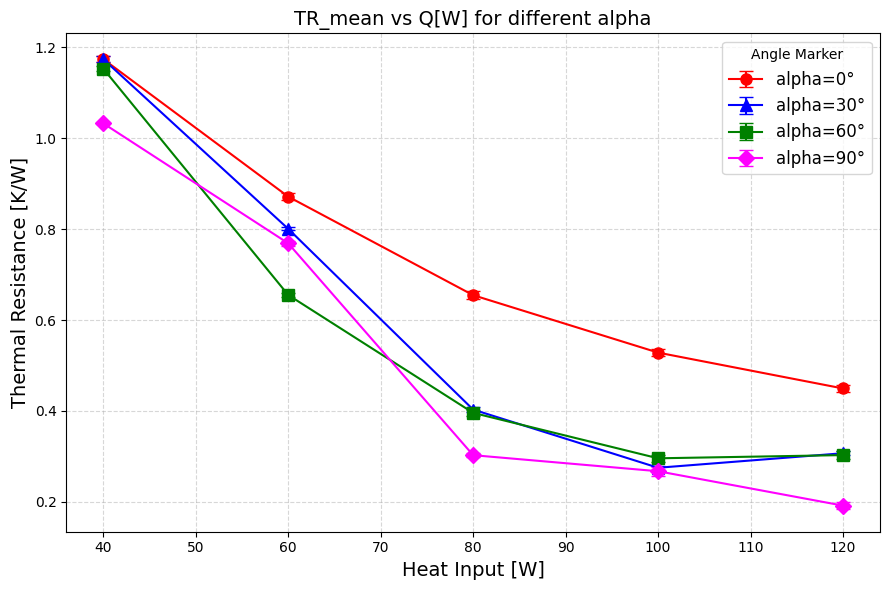

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load processed results (from previous code or CSV)
result_df = pd.read_csv("d4_TR_Statistical_Results.csv")

# Unique alpha values for grouping
alphas = sorted(result_df['alpha'].unique())
# Assign marker for each alpha (circle, triangle, square, diamond)
markers = ['o', '^', 's', 'D']  # 0:circle, 30:triangle, 60:square, 90:diamond
colors = ['red', 'blue', 'green', 'magenta']

plt.figure(figsize=(9, 6))
for i, alpha in enumerate(alphas):
    df_alpha = result_df[result_df['alpha'] == alpha]
    plt.errorbar(
        df_alpha['Q[W]'], df_alpha['TR_mean'],
        yerr=df_alpha['U95'],
        fmt=markers[i % len(markers)] + '-', color=colors[i % len(colors)],
        label=f'alpha={alpha}°', capsize=5, markersize=8
    )

plt.xlabel('Heat Input [W]', fontsize=14)
plt.ylabel('Thermal Resistance [K/W]', fontsize=14)
plt.title('TR_mean vs Q[W] for different alpha', fontsize=14)
plt.legend(fontsize=12, title='Angle Marker')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 3rd degree of polynomial

### main -3rd degree

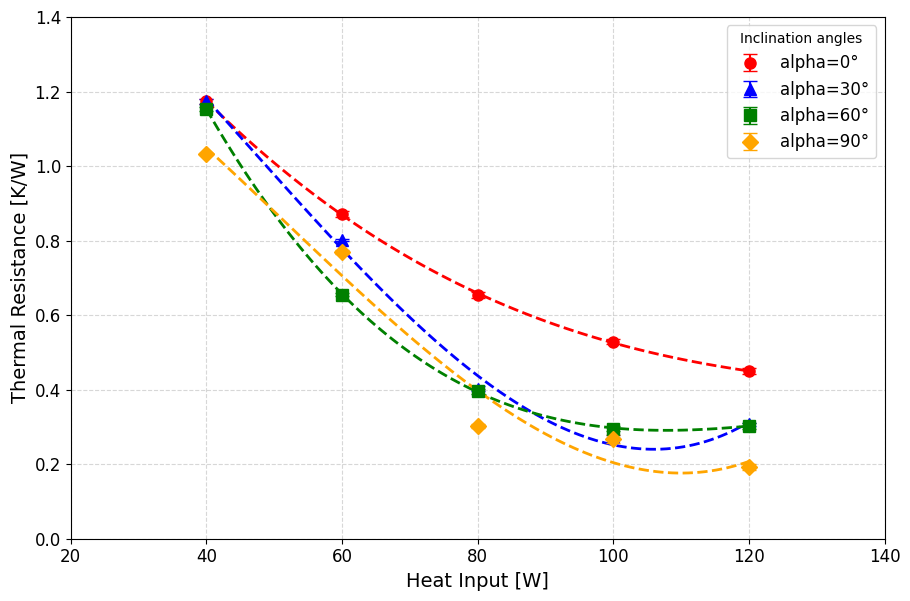

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load processed results (from previous code or CSV)
result_df = pd.read_csv("d4_TR_Statistical_Results.csv")

# Unique alpha values for grouping
alphas = sorted(result_df['alpha'].unique())
# Assign marker for each alpha (circle, triangle, square, diamond)
markers = ['o', '^', 's', 'D']  # 0:circle, 30:triangle, 60:square, 90:diamond
colors = ['red', 'blue', 'green', 'orange']

# Store coefficients for each alpha
coeffs_list = []

plt.figure(figsize=(9, 6))
for i, alpha in enumerate(alphas):
    df_alpha = result_df[result_df['alpha'] == alpha]
    x = df_alpha['Q[W]']
    y = df_alpha['TR_mean']
    yerr = df_alpha['U95']

    # Fit 3rd-degree polynomial
    coeffs = np.polyfit(x, y, 3)
    coeffs_list.append({'alpha': alpha, 'c3': coeffs[0], 'c2': coeffs[1], 'c1': coeffs[2], 'c0': coeffs[3]})

    # Generate smooth curve for plotting
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = np.polyval(coeffs, x_fit)

    # Plot only markers (no straight line) with error bars
    plt.errorbar(
        x, y,
        yerr=yerr,
        fmt=markers[i % len(markers)],  # Only marker, no line
        color=colors[i % len(colors)],
        label=f'alpha={alpha}°', capsize=5, markersize=8
    )
    # Plot 3rd-degree polynomial fit line
    plt.plot(x_fit, y_fit, color=colors[i % len(colors)], linestyle='--', linewidth=2)

plt.xlabel('Heat Input [W]', fontsize=14)
plt.ylabel('Thermal Resistance [K/W]', fontsize=14)
# plt.title('TR_mean vs Q[W] for different alpha (3rd-degree fit)', fontsize=14)
plt.legend(fontsize=12, title='Inclination angles', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.xlim([20, 140])
plt.ylim([0, 1.4])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

# Save coefficients to CSV
coeffs_df = pd.DataFrame(coeffs_list)
coeffs_df.to_csv("d4_TR_poly3_coefficients.csv", index=False)

#### Paper - 16/04/2026

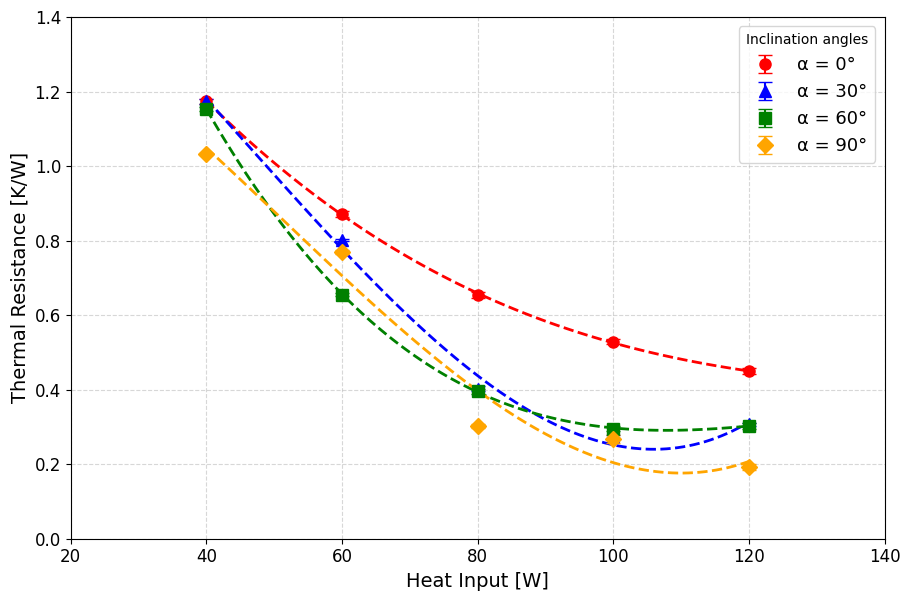

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load processed results (from previous code or CSV)
result_df = pd.read_csv("d4_TR_Statistical_Results.csv")

# Unique alpha values for grouping
alphas = sorted(result_df['alpha'].unique())
# Assign marker for each alpha (circle, triangle, square, diamond)
markers = ['o', '^', 's', 'D']  # 0:circle, 30:triangle, 60:square, 90:diamond
colors = ['red', 'blue', 'green', 'orange']

# Store coefficients for each alpha
coeffs_list = []

plt.figure(figsize=(9, 6))
for i, alpha in enumerate(alphas):
    df_alpha = result_df[result_df['alpha'] == alpha]
    x = df_alpha['Q[W]']
    y = df_alpha['TR_mean']
    yerr = df_alpha['U95']

    # Fit 3rd-degree polynomial
    coeffs = np.polyfit(x, y, 3)
    coeffs_list.append({'alpha': alpha, 'c3': coeffs[0], 'c2': coeffs[1], 'c1': coeffs[2], 'c0': coeffs[3]})

    # Generate smooth curve for plotting
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = np.polyval(coeffs, x_fit)

    # Plot only markers (no straight line) with error bars
    plt.errorbar(
        x, y,
        yerr=yerr,
        fmt=markers[i % len(markers)],  # Only marker, no line
        color=colors[i % len(colors)],
        label=f'α = {alpha}°', capsize=5, markersize=8
    )
    # Plot 3rd-degree polynomial fit line
    plt.plot(x_fit, y_fit, color=colors[i % len(colors)], linestyle='--', linewidth=2)

plt.xlabel('Heat Input [W]', fontsize=14)
plt.ylabel('Thermal Resistance [K/W]', fontsize=14)
# plt.title('TR_mean vs Q[W] for different alpha (3rd-degree fit)', fontsize=14)
plt.legend(fontsize=13, title='Inclination angles', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.xlim([20, 140])
plt.ylim([0, 1.4])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

# Save coefficients to CSV
coeffs_df = pd.DataFrame(coeffs_list)
coeffs_df.to_csv("d4_TR_poly3_coefficients.csv", index=False)

#### avg_U95 - 1.5.2026

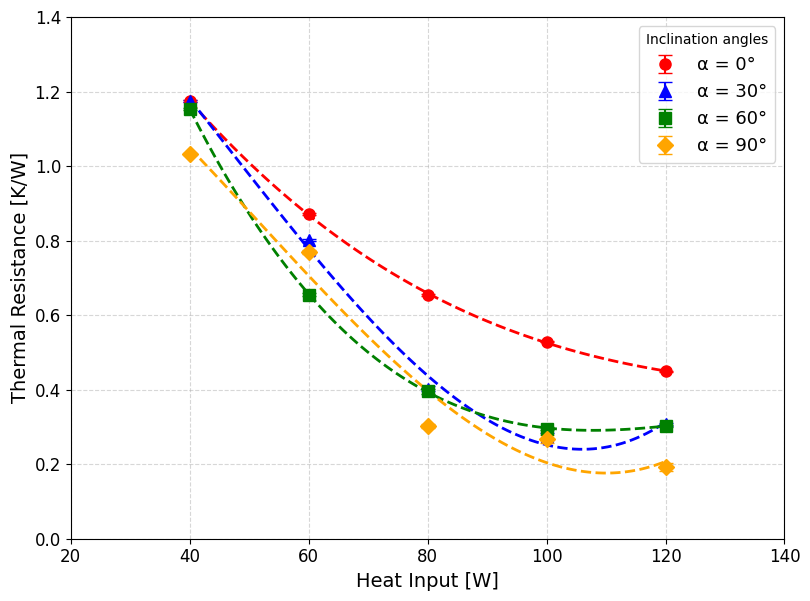

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load processed results (from previous code or CSV)
result_df = pd.read_csv("d4_TR_Statistical_Results_avg_u95.csv")

# Unique alpha values for grouping
alphas = sorted(result_df['alpha'].unique())
# Assign marker for each alpha (circle, triangle, square, diamond)
markers = ['o', '^', 's', 'D']  # 0:circle, 30:triangle, 60:square, 90:diamond
colors = ['red', 'blue', 'green', 'orange']

# Store coefficients for each alpha
coeffs_list = []

plt.figure(figsize=(8, 6))
for i, alpha in enumerate(alphas):
    df_alpha = result_df[result_df['alpha'] == alpha]
    x = df_alpha['Q[W]']
    y = df_alpha['TR_mean']
    yerr = df_alpha['U95']

    # Fit 3rd-degree polynomial
    coeffs = np.polyfit(x, y, 3)
    coeffs_list.append({'alpha': alpha, 'c3': coeffs[0], 'c2': coeffs[1], 'c1': coeffs[2], 'c0': coeffs[3]})

    # Generate smooth curve for plotting
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = np.polyval(coeffs, x_fit)

    # Plot only markers (no straight line) with error bars
    plt.errorbar(
        x, y,
        yerr=yerr,
        fmt=markers[i % len(markers)],  # Only marker, no line
        color=colors[i % len(colors)],
        label=f'α = {alpha}°', capsize=5, markersize=8
    )
    # Plot 3rd-degree polynomial fit line
    plt.plot(x_fit, y_fit, color=colors[i % len(colors)], linestyle='--', linewidth=2)

plt.xlabel('Heat Input [W]', fontsize=14)
plt.ylabel('Thermal Resistance [K/W]', fontsize=14)
# plt.title('TR_mean vs Q[W] for different alpha (3rd-degree fit)', fontsize=14)
plt.legend(fontsize=13, title='Inclination angles', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.xlim([20, 140])
plt.ylim([0, 1.4])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

# Save coefficients to CSV
coeffs_df = pd.DataFrame(coeffs_list)
coeffs_df.to_csv("d4_TR_poly3_coefficients_avg_u95.csv", index=False)

#### max_U95 - 1.5.2026 - paper

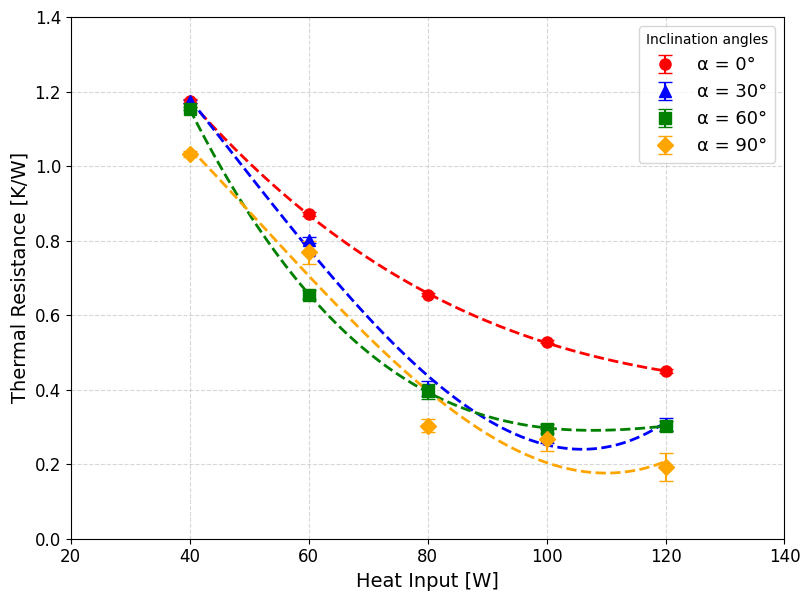

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load processed results (from previous code or CSV)
result_df = pd.read_csv("d4_TR_Statistical_Results_max_U95.csv")

# Unique alpha values for grouping
alphas = sorted(result_df['alpha'].unique())
# Assign marker for each alpha (circle, triangle, square, diamond)
markers = ['o', '^', 's', 'D']  # 0:circle, 30:triangle, 60:square, 90:diamond
colors = ['red', 'blue', 'green', 'orange']

# Store coefficients for each alpha
coeffs_list = []

plt.figure(figsize=(8, 6))
for i, alpha in enumerate(alphas):
    df_alpha = result_df[result_df['alpha'] == alpha]
    x = df_alpha['Q[W]']
    y = df_alpha['TR_mean']
    yerr = df_alpha['U95']

    # Fit 3rd-degree polynomial
    coeffs = np.polyfit(x, y, 3)
    coeffs_list.append({'alpha': alpha, 'c3': coeffs[0], 'c2': coeffs[1], 'c1': coeffs[2], 'c0': coeffs[3]})

    # Generate smooth curve for plotting
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = np.polyval(coeffs, x_fit)

    # Plot only markers (no straight line) with error bars
    plt.errorbar(
        x, y,
        yerr=yerr,
        fmt=markers[i % len(markers)],  # Only marker, no line
        color=colors[i % len(colors)],
        label=f'α = {alpha}°', capsize=5, markersize=8
    )
    # Plot 3rd-degree polynomial fit line
    plt.plot(x_fit, y_fit, color=colors[i % len(colors)], linestyle='--', linewidth=2)

plt.xlabel('Heat Input [W]', fontsize=14)
plt.ylabel('Thermal Resistance [K/W]', fontsize=14)
# plt.title('TR_mean vs Q[W] for different alpha (3rd-degree fit)', fontsize=14)
plt.legend(fontsize=13, title='Inclination angles', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.xlim([20, 140])
plt.ylim([0, 1.4])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

# Save coefficients to CSV
coeffs_df = pd.DataFrame(coeffs_list)
coeffs_df.to_csv("d4_TR_poly3_coefficients_max_U95.csv", index=False)

## TR Performance enhancement [%]

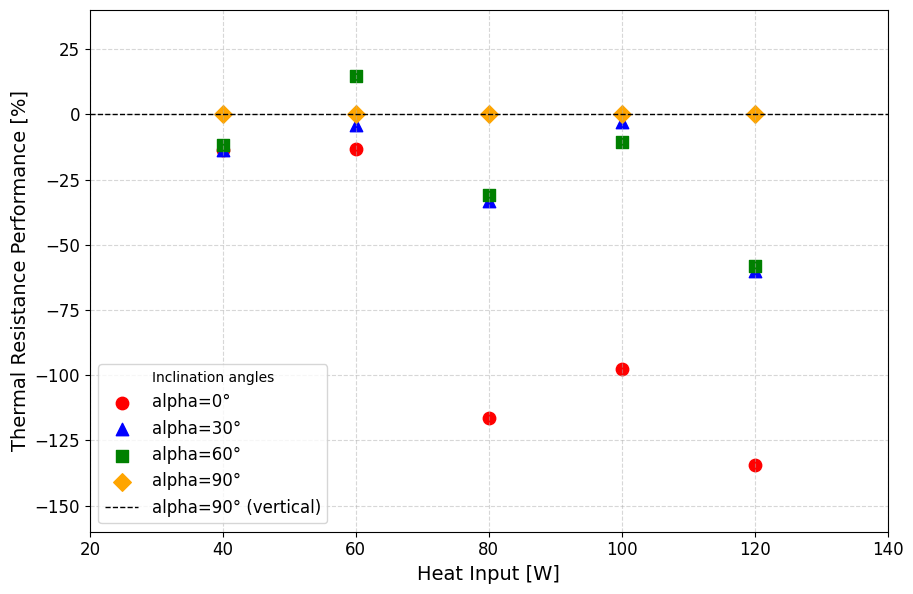

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load processed results (from previous code or CSV)
result_df = pd.read_csv("d4_TR_Statistical_Results.csv")

# Define alpha values to compare (excluding 90)
compare_alphas = [0, 30, 60]
ideal_alpha = 90

# Assign marker and color for each alpha
markers = ['o', '^', 's']
colors = ['red', 'blue', 'green']

plt.figure(figsize=(9, 6))

# Get TR_mean for alpha=90 (ideal) for each Q[W]
df_ideal = result_df[result_df['alpha'] == ideal_alpha].copy()
df_ideal = df_ideal.set_index('Q[W]')

for i, alpha in enumerate(compare_alphas):
    df_alpha = result_df[result_df['alpha'] == alpha].copy()
    # Align Q[W] values with ideal
    df_alpha = df_alpha.set_index('Q[W]')
    common_q = df_alpha.index.intersection(df_ideal.index)
    # Calculate TR performance [%]
    tr_ideal = df_ideal.loc[common_q, 'TR_mean']
    tr_alpha = df_alpha.loc[common_q, 'TR_mean']
    tr_perf = (tr_ideal - tr_alpha) / tr_ideal * 100

    # Plot TR performance [%] vs Q[W] (markers only, no lines)
    plt.scatter(common_q, tr_perf, marker=markers[i], color=colors[i], label=f'alpha={alpha}°', s=80)


# After your loop and after plt.axhline
plt.scatter(df_ideal.index, [0]*len(df_ideal), marker='D', color='orange', s=80, label='alpha=90°')

# Add centerline for alpha=90 (TR performance = 0%)
plt.axhline(0, color='black', linestyle='--', linewidth=1, label='alpha=90° (vertical)')

plt.xlabel('Heat Input [W]', fontsize=14)
plt.ylabel('Thermal Resistance Performance [%]', fontsize=14)
# plt.title('TR Performance [%] vs Q[W] (compared to alpha=90°)', fontsize=14)
plt.legend(fontsize=12, title='Inclination angles', loc='lower left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.xlim([20, 140])
plt.ylim([-160, 40])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

### Paper - 16/04/2026

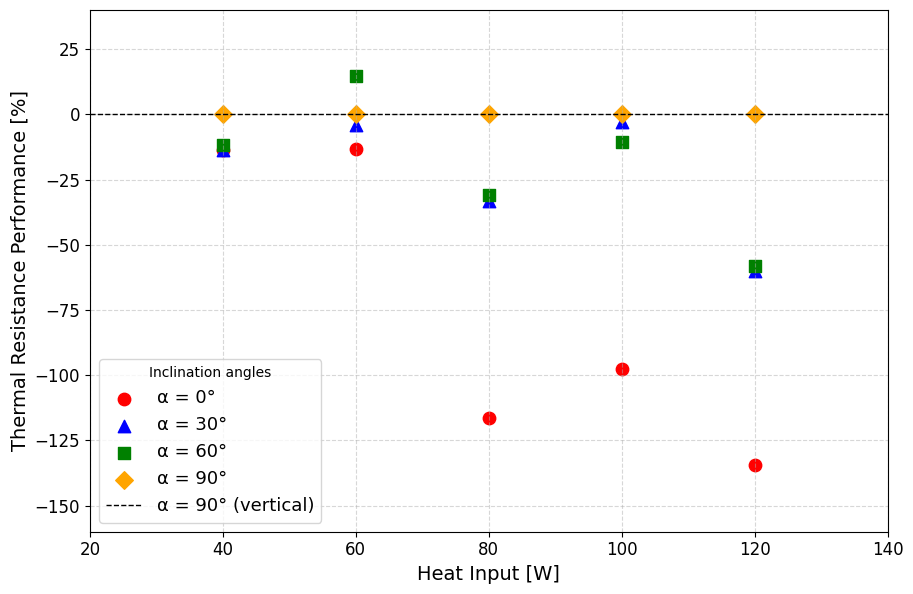

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load processed results (from previous code or CSV)
result_df = pd.read_csv("d4_TR_Statistical_Results.csv")

# Define alpha values to compare (excluding 90)
compare_alphas = [0, 30, 60]
ideal_alpha = 90

# Assign marker and color for each alpha
markers = ['o', '^', 's']
colors = ['red', 'blue', 'green']

plt.figure(figsize=(9, 6))

# Get TR_mean for alpha=90 (ideal) for each Q[W]
df_ideal = result_df[result_df['alpha'] == ideal_alpha].copy()
df_ideal = df_ideal.set_index('Q[W]')

for i, alpha in enumerate(compare_alphas):
    df_alpha = result_df[result_df['alpha'] == alpha].copy()
    # Align Q[W] values with ideal
    df_alpha = df_alpha.set_index('Q[W]')
    common_q = df_alpha.index.intersection(df_ideal.index)
    # Calculate TR performance [%]
    tr_ideal = df_ideal.loc[common_q, 'TR_mean']
    tr_alpha = df_alpha.loc[common_q, 'TR_mean']
    tr_perf = (tr_ideal - tr_alpha) / tr_ideal * 100

    # Plot TR performance [%] vs Q[W] (markers only, no lines)
    plt.scatter(common_q, tr_perf, marker=markers[i], color=colors[i], label=f'α = {alpha}°', s=80)


# After your loop and after plt.axhline
plt.scatter(df_ideal.index, [0]*len(df_ideal), marker='D', color='orange', s=80, label='α = 90°')

# Add centerline for alpha=90 (TR performance = 0%)
plt.axhline(0, color='black', linestyle='--', linewidth=1, label='α = 90° (vertical)')

plt.xlabel('Heat Input [W]', fontsize=14)
plt.ylabel('Thermal Resistance Performance [%]', fontsize=14)
# plt.title('TR Performance [%] vs Q[W] (compared to alpha=90°)', fontsize=14)
plt.legend(fontsize=13, title='Inclination angles', loc='lower left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.xlim([20, 140])
plt.ylim([-160, 40])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

### paper - 1.5.2026

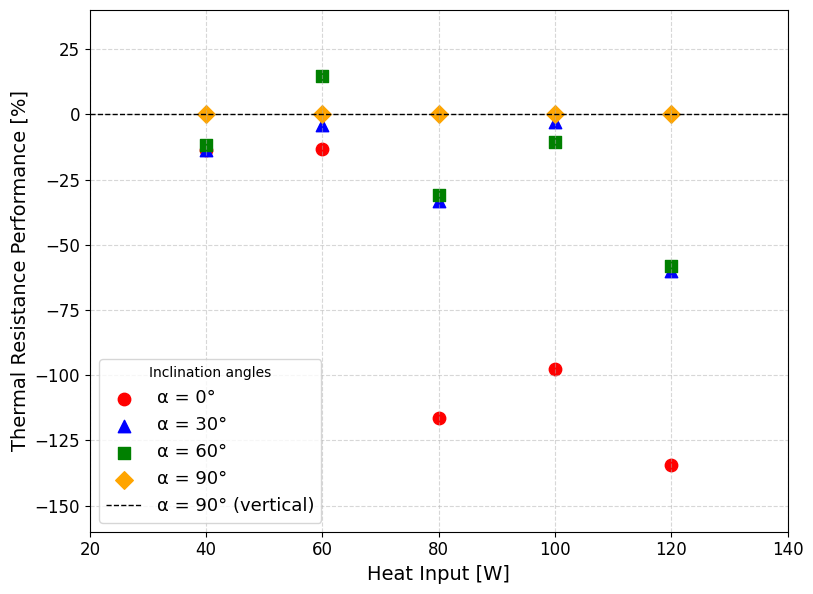

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load processed results (from previous code or CSV)
result_df = pd.read_csv("d4_TR_Statistical_Results_max_U95.csv")

# Define alpha values to compare (excluding 90)
compare_alphas = [0, 30, 60]
ideal_alpha = 90

# Assign marker and color for each alpha
markers = ['o', '^', 's']
colors = ['red', 'blue', 'green']

plt.figure(figsize=(8, 6))

# Get TR_mean for alpha=90 (ideal) for each Q[W]
df_ideal = result_df[result_df['alpha'] == ideal_alpha].copy()
df_ideal = df_ideal.set_index('Q[W]')

for i, alpha in enumerate(compare_alphas):
    df_alpha = result_df[result_df['alpha'] == alpha].copy()
    # Align Q[W] values with ideal
    df_alpha = df_alpha.set_index('Q[W]')
    common_q = df_alpha.index.intersection(df_ideal.index)
    # Calculate TR performance [%]
    tr_ideal = df_ideal.loc[common_q, 'TR_mean']
    tr_alpha = df_alpha.loc[common_q, 'TR_mean']
    tr_perf = (tr_ideal - tr_alpha) / tr_ideal * 100

    # Plot TR performance [%] vs Q[W] (markers only, no lines)
    plt.scatter(common_q, tr_perf, marker=markers[i], color=colors[i], label=f'α = {alpha}°', s=80)


# After your loop and after plt.axhline
plt.scatter(df_ideal.index, [0]*len(df_ideal), marker='D', color='orange', s=80, label='α = 90°')

# Add centerline for alpha=90 (TR performance = 0%)
plt.axhline(0, color='black', linestyle='--', linewidth=1, label='α = 90° (vertical)')

plt.xlabel('Heat Input [W]', fontsize=14)
plt.ylabel('Thermal Resistance Performance [%]', fontsize=14)
# plt.title('TR Performance [%] vs Q[W] (compared to alpha=90°)', fontsize=14)
plt.legend(fontsize=13, title='Inclination angles', loc='lower left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.xlim([20, 140])
plt.ylim([-160, 40])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

# # Trial 1 - Te: 348 K to 363 K

## code fro csv file

In [2]:
# ============================================================
# STEP 0 : Import Libraries
# ============================================================

import pandas as pd
import numpy as np

# Pandas → Data analysis
# Numpy → Mathematical calculations


# ============================================================
# STEP 1 : Load CSV File
# ============================================================

# Replace with your actual file name
file_path = "database_alpha.csv"

df = pd.read_csv(file_path)

print("\nColumns in Dataset:\n")
print(df.columns)


# ============================================================
# STEP 2 : Define Important Columns
# ============================================================

Q_col     = "Q[W]"
alpha_col = "alpha"
beta_col  = "beta"
Te_col    = "Te_mean[K]"
TR_col    = "TR[K/W]"


# ============================================================
# STEP 3 : Filter Using Te_mean[K]
# Example Range = 345–365 K
# ============================================================

Te_min = 348
Te_max = 363

filtered_df = df[
    (df[Te_col] >= Te_min) &
    (df[Te_col] <= Te_max)
]

print("\nRows After Temperature Filtering:")
print(len(filtered_df))


# ============================================================
# STEP 4 : Select Required Columns
# ============================================================

selected_df = filtered_df[
    [Q_col, alpha_col, beta_col, Te_col, TR_col]
]

print("\nPreview of Selected Data:\n")
print(selected_df.head())


# ============================================================
# STEP 5 : Group Data by
# Q[W], alpha, beta
# ============================================================

grouped = selected_df.groupby(
    [Q_col, alpha_col, beta_col]
)[TR_col]


# ============================================================
# STEP 6 : Calculate Statistics
# ============================================================

result_df = grouped.agg(

    TR_mean = 'mean',      # Mean TR
    TR_std  = 'std',       # Standard deviation
    n       = 'count'      # Number of samples

).reset_index()


# ============================================================
# STEP 7 : Calculate Uncertainty Parameters
# ============================================================

# Standard uncertainty

result_df["uc"] = result_df["TR_std"] / np.sqrt(result_df["n"])


# Expanded uncertainty (95%)
# k-value for n>30 = 2

k_value = 2

result_df["U95"] = k_value * result_df["uc"]


# Coefficient of Variation

result_df["CV_%"] = (
    result_df["TR_std"]
    / result_df["TR_mean"]
) * 100


# ============================================================
# STEP 8 : Sort Results
# ============================================================

result_df = result_df.sort_values(
    by=[Q_col, alpha_col, beta_col]
)


# ============================================================
# STEP 9 : Display Full Table
# ============================================================

print("\nFinal TR Statistical Table:\n")

print(
result_df.round(4).to_string(index=False)
)


# ============================================================
# STEP 10 : Save Full Results
# ============================================================

result_df.round(5).to_csv(

"d4_TR_Statistical_Results_1.csv",

index=False

)

print("\nSaved File:")
print("d4_TR_Statistical_Results_1.csv")


# ============================================================
# STEP 11 : Prepare Error-Bar File for Gnuplot
# (Mean ± U95)
# ============================================================

errorbar_df = result_df[

[Q_col,"TR_mean","U95"]

]

errorbar_df.to_csv(

"d4_TR_ErrorBars.csv_1",

index=False

)

print("\nSaved Error-bar File:")
print("d4_TR_ErrorBars.csv_1")


# ============================================================
# STEP 12 : Print Journal Format
# ============================================================

print("\nJournal Style Results:\n")

for _, row in result_df.iterrows():

    print(

        "Q =",int(row[Q_col]),"W",

        " alpha =",int(row[alpha_col]),

        " beta =",int(row[beta_col]),

        " TR =",round(row["TR_mean"],3),

        "±",

        round(row["U95"],3),"K/W"

    )


Columns in Dataset:

Index(['TIME', 'DATE', 'TC_1', 'TC_2', 'TC_3', 'TC_4', 'TC_5', 'TC_6', 'TC_7',
       'TC_8', 'TC_9', 'PRESSURE', 'HEATER', 'HEATER SET POINT', 'date',
       'voltage', 'current', 'power', 'WF', 'FR[%]', 'Q[W]', 'alpha', 'beta',
       'pulse', 'Te_mean[C]', 'Tc_mean[C]', 'Te_std[C]', 'Tc_std[C]', 'P[bar]',
       'Te_mean[K]', 'Tc_mean[K]', 'Te_std[K]', 'Tc_std[K]', 'T_pulse[K]',
       'TR[K/W]', 'GFE_Te[KJ/mol]', 'GFE_Tc[KJ/mol]', 'dG[KJ/mol]'],
      dtype='object')

Rows After Temperature Filtering:
11676

Preview of Selected Data:

      Q[W]  alpha  beta  Te_mean[K]  TR[K/W]
1164    40      0     0      348.07     1.11
1165    40      0     0      348.09     1.11
1166    40      0     0      348.19     1.11
1167    40      0     0      348.19     1.11
1168    40      0     0      348.19     1.11

Final TR Statistical Table:

 Q[W]  alpha  beta  TR_mean  TR_std    n     uc    U95    CV_%
   40      0     0   1.2094  0.0542  418 0.0027 0.0053  4.4856
   40  

## 3rd degree

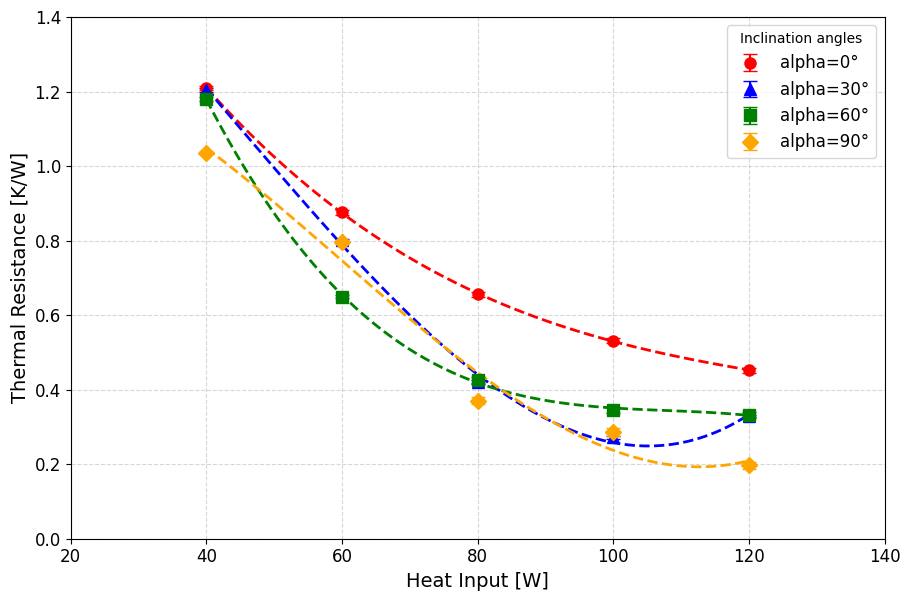

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load processed results (from previous code or CSV)
result_df = pd.read_csv("d4_TR_Statistical_Results_1.csv")

# Unique alpha values for grouping
alphas = sorted(result_df['alpha'].unique())
# Assign marker for each alpha (circle, triangle, square, diamond)
markers = ['o', '^', 's', 'D']  # 0:circle, 30:triangle, 60:square, 90:diamond
colors = ['red', 'blue', 'green', 'orange']

# Store coefficients for each alpha
coeffs_list = []

plt.figure(figsize=(9, 6))
for i, alpha in enumerate(alphas):
    df_alpha = result_df[result_df['alpha'] == alpha]
    x = df_alpha['Q[W]']
    y = df_alpha['TR_mean']
    yerr = df_alpha['U95']

    # Fit 3rd-degree polynomial
    coeffs = np.polyfit(x, y, 3)
    coeffs_list.append({'alpha': alpha, 'c3': coeffs[0], 'c2': coeffs[1], 'c1': coeffs[2], 'c0': coeffs[3]})

    # Generate smooth curve for plotting
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = np.polyval(coeffs, x_fit)

    # Plot only markers (no straight line) with error bars
    plt.errorbar(
        x, y,
        yerr=yerr,
        fmt=markers[i % len(markers)],  # Only marker, no line
        color=colors[i % len(colors)],
        label=f'alpha={alpha}°', capsize=5, markersize=8
    )
    # Plot 3rd-degree polynomial fit line
    plt.plot(x_fit, y_fit, color=colors[i % len(colors)], linestyle='--', linewidth=2)

plt.xlabel('Heat Input [W]', fontsize=14)
plt.ylabel('Thermal Resistance [K/W]', fontsize=14)
# plt.title('TR_mean vs Q[W] for different alpha (3rd-degree fit)', fontsize=14)
plt.legend(fontsize=12, title='Inclination angles', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.xlim([20, 140])
plt.ylim([0, 1.4])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

# Save coefficients to CSV
coeffs_df = pd.DataFrame(coeffs_list)
coeffs_df.to_csv("d4_TR_poly3_coefficients_1.csv", index=False)

# Trial 2 - Te: 350 K to 360 K

## csv code

In [6]:
# ============================================================
# STEP 0 : Import Libraries
# ============================================================

import pandas as pd
import numpy as np

# Pandas → Data analysis
# Numpy → Mathematical calculations


# ============================================================
# STEP 1 : Load CSV File
# ============================================================

# Replace with your actual file name
file_path = "database_alpha.csv"

df = pd.read_csv(file_path)

print("\nColumns in Dataset:\n")
print(df.columns)


# ============================================================
# STEP 2 : Define Important Columns
# ============================================================

Q_col     = "Q[W]"
alpha_col = "alpha"
beta_col  = "beta"
Te_col    = "Te_mean[K]"
TR_col    = "TR[K/W]"


# ============================================================
# STEP 3 : Filter Using Te_mean[K]
# Example Range = 345–365 K
# ============================================================

Te_min = 350
Te_max = 360

filtered_df = df[
    (df[Te_col] >= Te_min) &
    (df[Te_col] <= Te_max)
]

print("\nRows After Temperature Filtering:")
print(len(filtered_df))


# ============================================================
# STEP 4 : Select Required Columns
# ============================================================

selected_df = filtered_df[
    [Q_col, alpha_col, beta_col, Te_col, TR_col]
]

print("\nPreview of Selected Data:\n")
print(selected_df.head())


# ============================================================
# STEP 5 : Group Data by
# Q[W], alpha, beta
# ============================================================

grouped = selected_df.groupby(
    [Q_col, alpha_col, beta_col]
)[TR_col]


# ============================================================
# STEP 6 : Calculate Statistics
# ============================================================

result_df = grouped.agg(

    TR_mean = 'mean',      # Mean TR
    TR_std  = 'std',       # Standard deviation
    n       = 'count'      # Number of samples

).reset_index()


# ============================================================
# STEP 7 : Calculate Uncertainty Parameters
# ============================================================

# Standard uncertainty

result_df["uc"] = result_df["TR_std"] / np.sqrt(result_df["n"])


# Expanded uncertainty (95%)
# k-value for n>30 = 2

k_value = 2

result_df["U95"] = k_value * result_df["uc"]


# Coefficient of Variation

result_df["CV_%"] = (
    result_df["TR_std"]
    / result_df["TR_mean"]
) * 100


# ============================================================
# STEP 8 : Sort Results
# ============================================================

result_df = result_df.sort_values(
    by=[Q_col, alpha_col, beta_col]
)


# ============================================================
# STEP 9 : Display Full Table
# ============================================================

print("\nFinal TR Statistical Table:\n")

print(
result_df.round(4).to_string(index=False)
)


# ============================================================
# STEP 10 : Save Full Results
# ============================================================

result_df.round(5).to_csv(

"d4_TR_Statistical_Results_2.csv",

index=False

)

print("\nSaved File:")
print("d4_TR_Statistical_Results_2.csv")


# ============================================================
# STEP 11 : Prepare Error-Bar File for Gnuplot
# (Mean ± U95)
# ============================================================

errorbar_df = result_df[

[Q_col,"TR_mean","U95"]

]

errorbar_df.to_csv(

"d4_TR_ErrorBars.csv_2",

index=False

)

print("\nSaved Error-bar File:")
print("d4_TR_ErrorBars.csv_2")


# ============================================================
# STEP 12 : Print Journal Format
# ============================================================

print("\nJournal Style Results:\n")

for _, row in result_df.iterrows():

    print(

        "Q =",int(row[Q_col]),"W",

        " alpha =",int(row[alpha_col]),

        " beta =",int(row[beta_col]),

        " TR =",round(row["TR_mean"],3),

        "±",

        round(row["U95"],3),"K/W"

    )


Columns in Dataset:

Index(['TIME', 'DATE', 'TC_1', 'TC_2', 'TC_3', 'TC_4', 'TC_5', 'TC_6', 'TC_7',
       'TC_8', 'TC_9', 'PRESSURE', 'HEATER', 'HEATER SET POINT', 'date',
       'voltage', 'current', 'power', 'WF', 'FR[%]', 'Q[W]', 'alpha', 'beta',
       'pulse', 'Te_mean[C]', 'Tc_mean[C]', 'Te_std[C]', 'Tc_std[C]', 'P[bar]',
       'Te_mean[K]', 'Tc_mean[K]', 'Te_std[K]', 'Tc_std[K]', 'T_pulse[K]',
       'TR[K/W]', 'GFE_Te[KJ/mol]', 'GFE_Tc[KJ/mol]', 'dG[KJ/mol]'],
      dtype='object')

Rows After Temperature Filtering:
7536

Preview of Selected Data:

      Q[W]  alpha  beta  Te_mean[K]  TR[K/W]
1254    40      0     0      350.01     1.16
1255    40      0     0      350.01     1.16
1256    40      0     0      350.09     1.16
1257    40      0     0      350.09     1.16
1258    40      0     0      350.09     1.16

Final TR Statistical Table:

 Q[W]  alpha  beta  TR_mean  TR_std    n     uc    U95    CV_%
   40      0     0   1.2304  0.0405  328 0.0022 0.0045  3.2884
   40   

## 3rd degree

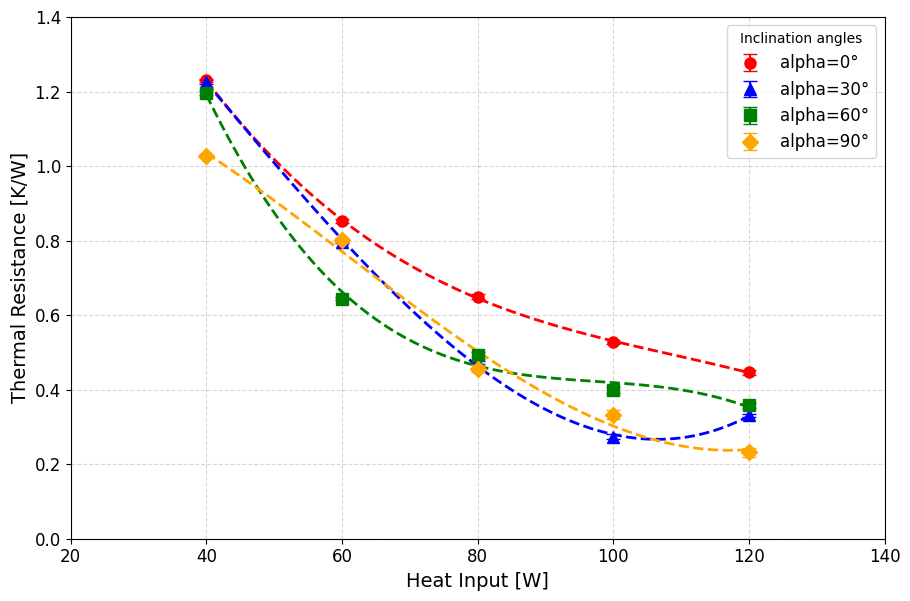

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load processed results (from previous code or CSV)
result_df = pd.read_csv("d4_TR_Statistical_Results_2.csv")

# Unique alpha values for grouping
alphas = sorted(result_df['alpha'].unique())
# Assign marker for each alpha (circle, triangle, square, diamond)
markers = ['o', '^', 's', 'D']  # 0:circle, 30:triangle, 60:square, 90:diamond
colors = ['red', 'blue', 'green', 'orange']

# Store coefficients for each alpha
coeffs_list = []

plt.figure(figsize=(9, 6))
for i, alpha in enumerate(alphas):
    df_alpha = result_df[result_df['alpha'] == alpha]
    x = df_alpha['Q[W]']
    y = df_alpha['TR_mean']
    yerr = df_alpha['U95']

    # Fit 3rd-degree polynomial
    coeffs = np.polyfit(x, y, 3)
    coeffs_list.append({'alpha': alpha, 'c3': coeffs[0], 'c2': coeffs[1], 'c1': coeffs[2], 'c0': coeffs[3]})

    # Generate smooth curve for plotting
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = np.polyval(coeffs, x_fit)

    # Plot only markers (no straight line) with error bars
    plt.errorbar(
        x, y,
        yerr=yerr,
        fmt=markers[i % len(markers)],  # Only marker, no line
        color=colors[i % len(colors)],
        label=f'alpha={alpha}°', capsize=5, markersize=8
    )
    # Plot 3rd-degree polynomial fit line
    plt.plot(x_fit, y_fit, color=colors[i % len(colors)], linestyle='--', linewidth=2)

plt.xlabel('Heat Input [W]', fontsize=14)
plt.ylabel('Thermal Resistance [K/W]', fontsize=14)
# plt.title('TR_mean vs Q[W] for different alpha (3rd-degree fit)', fontsize=14)
plt.legend(fontsize=12, title='Inclination angles', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.xlim([20, 140])
plt.ylim([0, 1.4])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

# Save coefficients to CSV
coeffs_df = pd.DataFrame(coeffs_list)
coeffs_df.to_csv("d4_TR_poly3_coefficients_2.csv", index=False)